# Libraries + General Helpers

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression,mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, ParameterGrid
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.model_selection import cross_validate
from matplotlib import pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from utility import FeatureCreator, GroupwisePLSTransformer, SKColumnSelector, detect_outliers, DivideByFeatureRegressor, ewm_reset
from tqdm.notebook import tqdm
from joblib import parallel_backend
import re
from copy import deepcopy
import pickle
from tqdm.notebook import tqdm  # plain text tqdm
import contextlib
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import cma
from sklearn.model_selection import TimeSeriesSplit, check_cv
from sklearn.cross_decomposition import PLSRegression
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import plotly.express as px
from pytabkit import RealMLP_TD_Regressor
import dalex as dx

import seaborn as sns

sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

In [2]:
control_vars = {
    "Steam__kWh/T_" : [
        "inv_Production_Rate__T/h_",
        
        "Water_Predryer",
        "dewatering",

        "Draw_PS-PD1", #Pre-dryer
        # "Draw_PD2-PD3", #Pre-dryer
        # "Draw_PD4-PD5", #Pre-dryer 
        # "Draw_PD3-PD4", #Pre-dryer 
        # "Draw_PD1-PD2", #Pre-dryer
        "Moisture_out_of_PreDryer", #Pre-dryer
        "Draw_WS-PS", # Press Section
        "PickUp_Tension", # Press Section
    
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section 
        "Linepressure_shoe_press__bar_", # Press Section 
        "Vacuum_Zone_1_PickUp",# Press Section
        
        # 'Cylinder_1_differential_pressure',
        # 'Cylinder_1_steam_pressure',
        # 'Cylinder_2_steam_pressure',
        # 'Cylinder_3_differential_pressure',
        # 'Cylinder_2_differential_pressure',
        # 'Cylinder_3_steam_pressure',
        # 'Cylinder_4_differential_pressure',
        # 'Cylinder_5_steam_pressure',
        # 'Cylinder_4_steam_pressure',
        # 'Cylinder_5_differential_pressure',
        # 'Cylinder_1-5_steam_pressure',
        # 'Cylinder_1-5_fresh_steam',
        # 'Cylinder_6-15_differential_pressure',
        # 'Cylinder_6-15_steam_pressure',
        # 'Cylinder_1-5_steam_temperature',
        # 'Cylinder_14_differential_pressure',
        # 'Cylinder_16-24_steam_pressure',
        # 'Cylinder_25-35_steam_pressure',
        # 'Cylinder_6-35_differential_pressure',
        
        "ambient_temp_C",
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", 
        "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        #"Thick_Stock_Consistency__%_", # Approach Flow
        
        #"Headbox_consistency",
        
        
        
        "Top_Felt_Tension",
        "Bottom_wire_tension",
        "Bottom_Felt_Tension",
        
        "PD4_fabric_tension",
        "PD1_Fabric_tension",
        "PD2_Fabric_tension",
        "PD5_fabric_tension_top",
        "PD5_fabric_tension_bottom",
       
        "pH-Messung_Verdünnungswasser__2..12_pH_",
        "Dissolved_gas_after_stock_deculator_measurement_1",
        "Dissolved_gas_before_dilution_water_deculator",        
        "Air_pressure_of_rod_clamping_hose_Top_Roll",
        "Free_gas_before_dilution_water_deculator_measurement_2",
        "Free_gas_before_dilution_water_deculator_measurement_1~^0",
        "Free_gas_after_stock_deculator~^0",
        #"Storage_tank_temperature",
        
        "Vacuum_top_wire_suction_box_zone_2",
        "Vacuum_formning_roll",
        "Vacuum_top_wire_suction_box_zone_1",
        "Airturn_pillow_pressure",
        "Dewatering_Suction_Press_Roll",
        "Dewatering_First_Press_Roll",
             
        "Steam_temperature_for_PM",
        "Steam_pressure_for_PM",
                
        'Dewatering_Shoe_press',        
        'Total_Dewatering_Press',        
        'Uhle_box_1_flow___l/min_',
        
        "Stock_deculator_temperature",
        'Stock_deculator_pressure',
        
        'Inlet_Air_2_Temperature',
        'Inlet_Air_1_Temperature',
    
        'DG1_temperature_Inlet_Air',
        'DG2_temperature_Inlet_Air',
        'DG3_temperature_Inlet_Air',
        
        'DG1_Moisture_content_Outlet_Air',
        'DG2_Moisture_content_Outlet_Air',
        'DG3_Moisture_content_Outlet_Air',
       
        'DG1_Ventilator_Revolution_Output',
        'DG2_Ventilator_Revolution_Output',
        'DG3_Ventilator_Revolution_Output',
        
        "fibre_short/long",
        "retention",
        
        "diluted_starch",
        "Water_Afterdryer_output",        
        "Web_tension_AD6",
        "Moisture_out_of_PreDryer",
        # 'Cylinder_36_steam_pressure',
        # 'Cylinder_36_differential_pressure',
        # 'Cylinder_37_steam_pressure',
        # 'Cylinder_38_differential_pressure',
        # 'Cylinder_37_differential_pressure',
        # 'Cylinder_38_steam_pressure',
        # 'Cylinder_39_steam_pressure',
        # 'Cylinder_36-39_steam_pressure',
        # 'Cylinder_39_differential_pressure',
        # 'Cylinder_40-53_differential_pressure',
        # 'Cylinder_40-53_steam_pressure',
        'DG4_Temperature_Inlet_Air',
        'DG5_Temperature_Inlet_Air',
        'DG4_Moisture_content_Outlet_Air',
        'DG5_Moisture_content_Outlet_Air',
        "AD7_fabric_tension_bottom",
        "AD6_fabric_tension",


        'CO2_mass_flow__g/T_',
        "Act_Deaerator_mass_flow__g/T_",
        "Retention_Aid_mass_flow__g/T_", # Approach Flow
        "Bentonite_1_mass_flow__g/T_", # Approach Flow
        "Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Natriumhydroxide_mass_flow__g/T_",
        'Fixative_2_mass_flow__g/T_',

    ],

    "Steam__kW" : [ 
        "Water_flow_Predryer",
        "Water_flow_Afterdryer_input",
        "Water_flow_Afterdryer_output",

        "dewatering",

        "Draw_PS-PD1", #Pre-dryer
        # "Draw_PD2-PD3", #Pre-dryer
        # "Draw_PD4-PD5", #Pre-dryer 
        # "Draw_PD3-PD4", #Pre-dryer 
        # "Draw_PD1-PD2", #Pre-dryer
        "Moisture_out_of_PreDryer", #Pre-dryer
        "Draw_WS-PS", # Press Section
        "PickUp_Tension", # Press Section
    
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section 
        "Linepressure_shoe_press__bar_", # Press Section 
        "Vacuum_Zone_1_PickUp",# Press Section
        
        'Cylinder_1_differential_pressure',
        'Cylinder_1_steam_pressure',
        'Cylinder_2_steam_pressure',
        'Cylinder_3_differential_pressure',
        'Cylinder_2_differential_pressure',
        'Cylinder_3_steam_pressure',
        'Cylinder_4_differential_pressure',
        'Cylinder_5_steam_pressure',
        'Cylinder_4_steam_pressure',
        'Cylinder_5_differential_pressure',
        'Cylinder_1-5_steam_pressure',
        'Cylinder_1-5_fresh_steam',
        'Cylinder_6-15_differential_pressure',
        'Cylinder_6-15_steam_pressure',
        'Cylinder_1-5_steam_temperature',
        'Cylinder_14_differential_pressure',
        'Cylinder_16-24_steam_pressure',
        'Cylinder_25-35_steam_pressure',
        'Cylinder_6-35_differential_pressure',
        
        "ambient_temp_C",
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", 
        "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        #"Thick_Stock_Consistency__%_", # Approach Flow
        
        #"Headbox_consistency",
        
        
        
        "Top_Felt_Tension",
        "Bottom_wire_tension",
        "Bottom_Felt_Tension",
        
        "PD4_fabric_tension",
        "PD1_Fabric_tension",
        "PD2_Fabric_tension",
        "PD5_fabric_tension_top",
        "PD5_fabric_tension_bottom",
       
        "pH-Messung_Verdünnungswasser__2..12_pH_",
        "Dissolved_gas_after_stock_deculator_measurement_1",
        "Dissolved_gas_before_dilution_water_deculator",        
        "Air_pressure_of_rod_clamping_hose_Top_Roll",
        "Free_gas_before_dilution_water_deculator_measurement_2",
        "Free_gas_before_dilution_water_deculator_measurement_1~^0",
        "Free_gas_after_stock_deculator~^0",
        "Storage_tank_temperature",
        
        "Vacuum_top_wire_suction_box_zone_2",
        "Vacuum_formning_roll",
        "Vacuum_top_wire_suction_box_zone_1",
        "Airturn_pillow_pressure",
        "Dewatering_Suction_Press_Roll",
        "Dewatering_First_Press_Roll",
             
        "Steam_temperature_for_PM",
        "Steam_pressure_for_PM",
                
        'Dewatering_Shoe_press',        
        'Total_Dewatering_Press',        
        'Uhle_box_1_flow___l/min_',
        
        "Stock_deculator_temperature",
        'Stock_deculator_pressure',
        
        'Inlet_Air_2_Temperature',
        'Inlet_Air_1_Temperature',
    
        'DG1_temperature_Inlet_Air',
        'DG2_temperature_Inlet_Air',
        'DG3_temperature_Inlet_Air',
        
        'DG1_Moisture_content_Outlet_Air',
        'DG2_Moisture_content_Outlet_Air',
        'DG3_Moisture_content_Outlet_Air',
       
        'DG1_Ventilator_Revolution_Output',
        'DG2_Ventilator_Revolution_Output',
        'DG3_Ventilator_Revolution_Output',
        
        "fibre_short/long",
        "retention",
             
        "Web_tension_AD6",
        "Moisture_out_of_PreDryer",
        'Cylinder_36_steam_pressure',
        'Cylinder_36_differential_pressure',
        'Cylinder_37_steam_pressure',
        'Cylinder_38_differential_pressure',
        'Cylinder_37_differential_pressure',
        'Cylinder_38_steam_pressure',
        'Cylinder_39_steam_pressure',
        'Cylinder_36-39_steam_pressure',
        'Cylinder_39_differential_pressure',
        'Cylinder_40-53_differential_pressure',
        'Cylinder_40-53_steam_pressure',
        'DG4_Temperature_Inlet_Air',
        'DG5_Temperature_Inlet_Air',
        'DG4_Moisture_content_Outlet_Air',
        'DG5_Moisture_content_Outlet_Air',
        "AD7_fabric_tension_bottom",
        "AD6_fabric_tension",


        'CO2_mass_flow__g/T_',
        "Act_Deaerator_mass_flow__g/T_",
        "Retention_Aid_mass_flow__g/T_", # Approach Flow
        "Bentonite_1_mass_flow__g/T_", # Approach Flow
        "Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Natriumhydroxide_mass_flow__g/T_",
        'Fixative_2_mass_flow__g/T_',
    ],
    
    "Steam_flow_to_AfterDryers" : [
        'CO2_mass_flow__g/T_',
        "fibre_short/long",
        "retention",
        #"Water_flow_Afterdryer",
        "Current_basis_weight",
        "Water_flow_Afterdryer_input",
        "Water_flow_Afterdryer_output",
        "Web_tension_AD6",
        "Moisture_out_of_PreDryer",
        'Cylinder_36_steam_pressure',
        'Cylinder_36_differential_pressure',
        'Cylinder_37_steam_pressure',
        'Cylinder_38_differential_pressure',
        'Cylinder_37_differential_pressure',
        'Cylinder_38_steam_pressure',
        'Cylinder_39_steam_pressure',
        'Cylinder_36-39_steam_pressure',
        'Cylinder_39_differential_pressure',
        'Cylinder_40-53_differential_pressure',
        'Cylinder_40-53_steam_pressure',
        'DG4_Temperature_Inlet_Air',
        'DG5_Temperature_Inlet_Air',
        'DG4_Moisture_content_Outlet_Air',
        'DG5_Moisture_content_Outlet_Air',
        "AD7_fabric_tension_bottom",
        "AD6_fabric_tension",
        

    ],

    "Steam_flow_to_PreDryers" : [
        'CO2_mass_flow__g/T_',
        "fibre_short/long",
        "retention",
        "dewatering",
        "Water_flow_Predryer",
        "Current_basis_weight", # Scanner
        # 'Speed', 
        # 'Speed_PD1', 
        # 'Speed_press_section', 
        # 'Speed_PD2', 
        # 'Speed_PD3', 
        # 'Speed_PD4_top', 
        # 'Speed_PD4_bottom', 
        # 'Speed_PD5_bottom',
        "Draw_PS-PD1", #Pre-dryer
        "Draw_PD2-PD3", #Pre-dryer
        "Draw_PD4-PD5", #Pre-dryer 
        "Draw_PD3-PD4", #Pre-dryer 
        "Draw_PD1-PD2", #Pre-dryer
        "Moisture_out_of_PreDryer", #Pre-dryer
        "Draw_WS-PS", # Press Section
        "PickUp_Tension", # Press Section
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section 
        "Linepressure_shoe_press__bar_", # Press Section 
        "Vacuum_Zone_1_PickUp",# Press Section
        
        'Cylinder_1_differential_pressure',
        'Cylinder_1_steam_pressure',
        'Cylinder_2_steam_pressure',
        'Cylinder_3_differential_pressure',
        'Cylinder_2_differential_pressure',
        'Cylinder_3_steam_pressure',
        'Cylinder_4_differential_pressure',
        'Cylinder_5_steam_pressure',
        'Cylinder_4_steam_pressure',
        'Cylinder_5_differential_pressure',
        'Cylinder_1-5_steam_pressure',
        'Cylinder_1-5_fresh_steam',
        'Cylinder_6-15_differential_pressure',
        'Cylinder_6-15_steam_pressure',
        'Cylinder_1-5_steam_temperature',
        'Cylinder_14_differential_pressure',
        'Cylinder_16-24_steam_pressure',
        'Cylinder_25-35_steam_pressure',
        'Cylinder_6-35_differential_pressure',
        
        "ambient_temp_C",
        
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", 
        "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        "Retention_Aid_mass_flow__g/T_", # Approach Flow
        "Bentonite_1_mass_flow__g/T_", # Approach Flow
        "Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Thick_Stock_Consistency__%_", # Approach Flow
        
        #"Headbox_consistency",
        
        "pH-Messung_Verdünnungswasser__2..12_pH_",
        "Dissolved_gas_after_stock_deculator_measurement_1",
        "Dissolved_gas_before_dilution_water_deculator",        
        
        "Top_Felt_Tension",
        "Bottom_wire_tension",
        "Bottom_Felt_Tension",
        
        "PD4_fabric_tension",
        "PD1_Fabric_tension",
        "PD2_Fabric_tension",
        "PD5_fabric_tension_top",
        "PD5_fabric_tension_bottom",
       
        "Act_Deaerator_mass_flow__g/T_",
        
        "Natriumhydroxide_mass_flow__g/T_",
        
        "Air_pressure_of_rod_clamping_hose_Top_Roll",
        "Free_gas_before_dilution_water_deculator_measurement_2",
        "Free_gas_before_dilution_water_deculator_measurement_1~^0",
        "Free_gas_after_stock_deculator~^0",
        "Storage_tank_temperature",
        
        "Vacuum_top_wire_suction_box_zone_2",
        "Vacuum_formning_roll",
        "Vacuum_top_wire_suction_box_zone_1",
        "Airturn_pillow_pressure",
        "Dewatering_Suction_Press_Roll",
        "Dewatering_First_Press_Roll",
        
        "Current_reel_width",
        "Steam_temperature_for_PM",
        "Steam_pressure_for_PM",
                
        'Dewatering_Shoe_press',        
        'Total_Dewatering_Press',        
        'Uhle_box_1_flow___l/min_',
        
        "Stock_deculator_temperature",
        'Stock_deculator_pressure',
        
        'Fixative_2_mass_flow__g/T_',

        'Inlet_Air_2_Temperature',
        'Inlet_Air_1_Temperature',
    
        'DG1_temperature_Inlet_Air',
        'DG2_temperature_Inlet_Air',
        'DG3_temperature_Inlet_Air',
        
        'DG1_Moisture_content_Outlet_Air',
        'DG2_Moisture_content_Outlet_Air',
        'DG3_Moisture_content_Outlet_Air',
       
        'DG1_Ventilator_Revolution_Output',
        'DG2_Ventilator_Revolution_Output',
        'DG3_Ventilator_Revolution_Output',
        
        #"ambient_temp_C",
        
       
    ],
    "Electricity__kWh/T_": [
        
        "retention",
        "dewatering",
        "Current_basis_weight", # Scanner
        "Speed",
        #'AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section',
        #'Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3',
        "Current_reel_moisture_average(reel)", # Scanner
        
        #"Actual_moisture", # (Moisture before SpeedSizer) Scanner
        #"BSW_2_sigma", # Scanner
        #"Mois_2_sigma", # Scanner
        
        #"Sizing_Agent__g/T_", # Size Press
        #"Starch_uptake__g/m2_", # Size Press
        #"ratio_starch", # Size Press
        #"flow_diluted_starch",
        #'Flow_starch_main_line_to_working_tank', # Size Press
        #"Draw_PD5-SS",  # Size Press
        #"Defoamer_mass_flow__g/T_", # Size Press
        #"Dry_Strength_Agent_mass_flow__kg/T_", # Size Press
        "SpeedSizer_Linepressure_DS", # Size Press
        "SpeedSizer_Linepressure_FS", # Size Press
        "Consistency_starch_main_line", # Size Press
        
        "Moisture_out_of_PreDryer", #Pre-dryer
    
        "PickUp_Tension", # Press Section
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section
        "Linepressure_shoe_press__bar_", # Press Section
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        'CO2_mass_flow__g/T_',
        "Retention_Aid_mass_flow__g/T_", # Approach Flow
        "Bentonite_1_mass_flow__g/T_", # Approach Flow
        "Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Thick_Stock_Consistency__%_", # Approach Flow
        "Act_Deaerator_mass_flow__g/T_",
        "Natriumhydroxide_mass_flow__g/T_",
 
],
    "Starch_uptake__g/m2_":[
    "Rod_pressure_Top_Roll",
    "Rod_Pressure_Bottom_Roll",
    "Speed_Size_Press",
    "Current_basis_weight",
    "concentration_starch_working_tank_1",   
    "Temperature_starch_working_tank_1",   
    "concentration_starch_working_tank_2",   
    "Temperature_starch_working_tank_2",   
    'Current_reel_moisture_average(SpeedSizer)',
    'Moisture_after_SpeedSizer',
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    "Bentonite_1_mass_flow__g/T_", 
    "Bentonite_2_mass_flow__g/T_", 
    "Current_reel_moisture_average(reel)",
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
 
],
'Starch_uptake_by_paper_Bottom_Roll__g/m2_' :[
    'Viscosity_for_working_tank_bottom_roll',
    'CO2_mass_flow__g/T_',
    "grammage",
    "delta_basis_weight",
    "inv_Rod_Pressure_Bottom_Roll",
    #"Rod_Pressure_Bottom_Roll",
    "Speed_Size_Press",
    #"Current_basis_weight",
    "concentration_starch_working_tank_1",   
    "Temperature_starch_working_tank_1",       
    'Moisture_after_SpeedSizer',
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    # "Bentonite_1_mass_flow__g/T_", 
    # "Bentonite_2_mass_flow__g/T_", 
    # "Current_reel_moisture_average(reel)",
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
    'Linepressure_1st_press_FS__bar_', 
    'Linepressure_2nd_press_FS__bar_', 
    'Linepressure_1st_press_DS__bar_', 
    'Linepressure_2nd_press_DS__bar_', 
    'Linepressure_shoe_press__bar_',
    'CO2_mass_flow__g/T_',
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
    "Thick_Stock_Consistency__%_", # Approach Flow
    "Act_Deaerator_mass_flow__g/T_",
    "Natriumhydroxide_mass_flow__g/T_",
],
'Starch_uptake_by_paper_Top_Roll__g/m2_':[
    'Viscosity_for_working_tank_bottom_roll',
    'CO2_mass_flow__g/T_',
    "grammage",
    "delta_basis_weight",
    "inv_Rod_pressure_Top_Roll",
    #"Rod_pressure_Top_Roll",
    #"square_Rod_pressure_Top_Roll",
    "Speed_Size_Press",
    #"Current_basis_weight",
    "concentration_starch_working_tank_2",   
    "Temperature_starch_working_tank_2",   
    'Moisture_after_SpeedSizer',    
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    "Bentonite_1_mass_flow__g/T_", 
    "Bentonite_2_mass_flow__g/T_",     
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
    'Linepressure_1st_press_FS__bar_', 'Linepressure_2nd_press_FS__bar_', 'Linepressure_1st_press_DS__bar_', 'Linepressure_2nd_press_DS__bar_', 'Linepressure_shoe_press__bar_',
    'CO2_mass_flow__g/T_',
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
    "Thick_Stock_Consistency__%_", # Approach Flow
    "Act_Deaerator_mass_flow__g/T_",
    "Natriumhydroxide_mass_flow__g/T_",
],
'MBS_SCT_CD':[
    "retention",
    "grammage",
    "delta_basis_weight",
    "Speed",
    #'Current_reel_moisture_average(SpeedSizer)',
    "Moisture_after_SpeedSizer",
    "Current_reel_moisture_average(reel)",
    'SpeedSizer_Linepressure_DS',
    'SpeedSizer_Linepressure_FS',
    'Viscosity_for_working_tank_bottom_roll',
    "Starch_uptake__g/m2_",
    'Consistency_starch_main_line',
    'Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3',
    "Linepressure_1st_press_FS__bar_", # Press Section
    "Linepressure_2nd_press_FS__bar_", # Press Section
    "Linepressure_1st_press_DS__bar_", # Press Section
    "Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 
    "pH_measurement_white_water_B41", # Forming Wire
    'Headbox_consistency',    
    "Lip_settings",
    "Jet/wire_ratio",
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow   
    'CO2_mass_flow__g/T_',
    "fibre_short/long",

    "White_water_temperature", 
    "Conductivity_white_water_B46",
    "pH_measurement_white_water_B41",    
    "Current_reel_width",
],
"recommended": [
    "Speed",
    'Current_reel_moisture_average(SpeedSizer)',
    "Current_reel_moisture_average(reel)",
    'Starch_mass_flow__kg/T_',
    'Dry_Strength_Agent_mass_flow__kg/T_',
    'SpeedSizer_Linepressure_DS',
     'SpeedSizer_Linepressure_FS',
    "Starch_uptake_by_paper_Top_Roll__g/m2_",
     "Starch_uptake_by_paper_Bottom_Roll__g/m2_",
    'Starch_consumption_Bottom___m³/h_',
     'Starch_consumption_Top__m³/h_',
    'Consistency_starch_main_line',
    "Draw_WS-PS",
    "Linepressure_1st_press_FS__bar_", # Press Section
    "Linepressure_2nd_press_FS__bar_", # Press Section
    "Linepressure_1st_press_DS__bar_", # Press Section
    "Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 
     "pH_measurement_white_water_B41", # Forming Wire
    'Headbox_consistency',
     'Headbox_total_flow',
     "Lip_settings",
    "Jet/wire_ratio",
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
     "Thick_Stock_Consistency__%_", # Approach Flow
     'Thick_Stock_Flow__l/min_',
    'Short_fibre_flow',
     'Long_fibre_flow',
     'Dry_broke_flow',
     'Wet_broke_flow',    
]
}

In [3]:
from typing import Iterable, TypeVar
from utility import update_turnup_grammage, ewm_reset, _feature_engineering, setpoint_df

T = TypeVar("T")

def unique_in_order(values: Iterable[T]) -> list[T]:
    """Remove duplicates while preserving their first-occurrence order."""
    return list(dict.fromkeys(values))


def ordered_difference(values: Iterable[T], excluded: Iterable[T]) -> list[T]:
    """Remove excluded items while preserving order."""
    excluded_set = set(excluded)
    return [value for value in values if value not in excluded_set]


def ordered_intersection(values: Iterable[T], allowed: Iterable[T]) -> list[T]:
    """Keep allowed items while preserving order."""
    allowed_set = set(allowed)
    return [value for value in values if value in allowed_set]

In [96]:
def outlier(y, option="IQR"):
    import numpy as np
    
    def hampel(series, window=24, n=3.0):
        x = series.copy()
        med = x.rolling(window, center=True).median()
        mad = (np.abs(x - med)).rolling(window, center=True).median()
        k = 1.4826  # ~1/MAD-to-sigma
        diff = np.abs(x - med) / (k*mad)
        return diff > n

    if option=="IQR":
        q1, q3 = y.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        mask = (y < low) | (y > high)
        return mask
    elif option=="MAD":
        med = y.median()
        mad = (np.abs(y - med)).median()
        modz = 0.6745 * (y - med) / mad
        mask = modz.abs() > 3.5
        return mask
    elif option=="Hampel":
        return hampel(y, window=24, n=3)
    elif option=="PctClip":
        low, high = y.quantile([0.01, 0.99])
        y_clipped = y.clip(lower=low, upper=high)   # cap
        # or drop
        mask = (y < low) | (y > high)
        return mask
    elif option=="StrPctClip":
        low, high = y.quantile([0.001, 0.999])
        y_clipped = y.clip(lower=low, upper=high)   # cap
        # or drop
        mask = (y < low) | (y > high)
        return mask
    
def transform(turnup, ycol):
    import pandas as pd
    import numpy as np
    
    turnup['MBS_Current_reel_ID']=turnup['MBS_Current_reel_ID'].astype(int)
    turnup['AB_Grade_ID']=turnup['AB_Grade_ID'].astype(int)
    turnup['Wedge_Time']=pd.to_datetime(turnup['Wedge_Time'])
    
    turnup["grammage"]=turnup["AB_Grade_ID"].apply(lambda s: s-int(s/1000)*1000 )
    turnup["paper_type"]=turnup["AB_Grade_ID"].apply(lambda s: int(s/1000)).astype("string")
    
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e in v.lower() for e in ["€","g/m2","g/t","mbs_","t/t","level","consistency","temperature","l/min","fibre_fraction","moisture","dry_average",'pressure_reel_holders','_differential_pressure']):
            turnup.loc[turnup[v] <= 0, v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e in v.lower() for e in ["power","flow"]):
            turnup.loc[turnup[v] < 0, v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e in v.lower() for e in ["vacuum"]):
            turnup.loc[turnup[v] > 0, v] = np.nan

    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e.lower() in v.lower() for e in ['€/t',"flow__g/t_","flow__kg/t_","kWh/T","moisture","felt_tension","wire_tension","compressor",'fibre_flow',"Short_fibre_B06_consistency","Long_fibre_consistency_B07"]):
            #print(v)
            turnup.loc[outlier(turnup[v],option="StrPctClip"), v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e.lower() in v.lower() for e in 
               ['pressure_reel_holders','discharge_pressure',
                "_differential_pressure",'Thick_Stock_Consistency','Machine_chest_consistency',
                'Free_gas_after_stock_deculator~^0','Dissolved_gas_after_stock_deculator_measurement',
                'Pulper_consistency','ATS1_power','light_reject_flow']):
            #print(v)
            turnup.loc[outlier(turnup[v],option="PctClip"), v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e.lower() in v.lower() for e in ["long_fibre_fraction","LF_screen"]):
            #print(v)
            turnup.loc[outlier(turnup[v],option="IQR"), v] = np.nan
    
    turnup.loc[turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"] > 4, "Starch_uptake_by_paper_Bottom_Roll__g/m2_"] = np.nan
    turnup.loc[turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"] > 4, "Starch_uptake_by_paper_Top_Roll__g/m2_"] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] < 600, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] > 1000, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["Steam__€/T_"] > 100, "Steam__€/T_"] = np.nan
    turnup.loc[turnup["Steam__kWh/T_"] > 2000, "Steam__kWh/T_"] = np.nan
    turnup.loc[turnup["Electricity__kWh/T_"] > 500, "Steam__kWh/T_"] = np.nan
    turnup.loc[turnup["Starch_consumption_Top__m³/h_"] > 2, "Starch_consumption_Top__m³/h_"] = np.nan
    turnup.loc[turnup["Starch_application_BW_in_ml"] > 30, "Starch_application_BW_in_ml"] = np.nan
    turnup.loc[turnup["Starch_flow_to_inactivation"] > 1e8, "Starch_flow_to_inactivation"] = np.nan
    turnup.loc[turnup["Flow_starch_main_line_to_working_tank_2~^0"] > 8, "Flow_starch_main_line_to_working_tank_2~^0"] = np.nan
    turnup.loc[turnup["Dilution_water_working_tank_2"] > 6, "Dilution_water_working_tank_2"] = np.nan
    turnup.loc[turnup["Pulper_consistency"] > 20, "Pulper_consistency"] = np.nan
    turnup.loc[turnup["Combisorter_1_power"] > 150, "Combisorter_1_power"] = np.nan
    turnup.loc[turnup["Combisorter_2_power"] > 100, "Combisorter_2_power"] = np.nan
    turnup.loc[turnup["Contaminex_1_power"] > 100, "Contaminex_1_power"] = np.nan
    turnup.loc[turnup["Contaminex_2_power"] > 100, "Contaminex_2_power"] = np.nan
    turnup.loc[turnup["Contaminex_3_power"] > 100, "Contaminex_3_power"] = np.nan
    turnup.loc[turnup["LF_screen_1_power"] > 150, "LF_screen_1_power"] = np.nan
    turnup.loc[turnup["LF_screen_1_power"] < 100, "LF_screen_1_power"] = np.nan
    turnup.loc[turnup["LF_screen_2_power"] > 100, "LF_screen_2_power"] = np.nan
    turnup.loc[turnup["LF_screen_2_power"] < 85, "LF_screen_2_power"] = np.nan
    turnup.loc[turnup["LF_screen_3_power"] > 50, "LF_screen_3_power"] = np.nan
    turnup.loc[turnup["LF_screen_3_power"] < 40, "LF_screen_3_power"] = np.nan
    turnup.loc[turnup["Multifractor_1_Long_fibre_fraction"] > 50, "Multifractor_1_Long_fibre_fraction"] = np.nan
    turnup.loc[turnup["Multifractor_2_long_fibre_fraction"] > 50, "Multifractor_2_long_fibre_fraction"] = np.nan
    turnup.loc[turnup["LF_screen_2_inlet_consistency"] > 2, "LF_screen_2_inlet_consistency"] = np.nan
    turnup.loc[turnup["Cylinder_14_differential_pressure"] > 0.22, "Cylinder_14_differential_pressure"] = np.nan
    turnup.loc[turnup["Multifractor_1_long_fibre_flow"] > 400, "Multifractor_1_long_fibre_flow"] = np.nan
    turnup.loc[turnup["Short_fibre_B06_consistency"] < 4, "Short_fibre_B06_consistency"] = np.nan
    turnup.loc[turnup["Fibre_usage__T/T_"] < .06, "Fibre_usage__T/T_"] = np.nan
    turnup.loc[turnup['Combined_cost__€/T_'] > 300, 'Combined_cost__€/T_'] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] < 600, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] > 1000, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["Jet/wire_ratio"] > -10, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["MBS_SCT_CD"] > 2.5, "MBS_SCT_CD"] = np.nan
    turnup.loc[turnup["Draw_AD7-PR"] < 0, "Draw_AD7-PR"] = np.nan
    turnup.loc[turnup["Draw_SS-AD6"] > 0.25, "Draw_SS-AD6"] = np.nan
    turnup.loc[turnup["Draw_PD5-SS"] < -0.25, "Draw_PD5-SS"] = np.nan
    turnup.loc[turnup["Draw_PD3-PD4"] > 0.35, "Draw_PD3-PD4"] = np.nan
    turnup.loc[turnup["White_water_temperature"] > 60, "White_water_temperature"] = np.nan
    turnup.loc[turnup["Bentonite_filter_differential_pressure"] > 0, "Bentonite_filter_differential_pressure"] = np.nan
    turnup.loc[turnup["Jet/wire_ratio"] > -10, "Jet/wire_ratio"] = np.nan
    turnup.loc[turnup["Free_gas_before_dilution_water_deculator_measurement_1~^0"] > 2, "Free_gas_before_dilution_water_deculator_measurement_1~^0"] = np.nan
    turnup.loc[turnup["Free_gas_before_dilution_water_deculator_measurement_2"] > 2, "Free_gas_before_dilution_water_deculator_measurement_2"] = np.nan
    turnup.loc[turnup[ "Dissolved_gas_before_dilution_water_deculator"] > 2,  "Dissolved_gas_before_dilution_water_deculator"] = np.nan
    turnup.loc[turnup["Free_gas_after_stock_deculator~^0"] > 0.8,  "Free_gas_after_stock_deculator~^0"] = np.nan
    turnup.loc[turnup["Dissolved_gas_after_stock_deculator_measurement_1"] > 1,  "Dissolved_gas_after_stock_deculator_measurement_1"] = np.nan
    turnup.loc[turnup["Dissolved_gas_after_stock_deculator_measurement_2"] > 1,  "Dissolved_gas_after_stock_deculator_measurement_2"] = np.nan
    turnup.loc[(turnup["Act_Deaerator_mass_flow__g/T_"] > 250) & (turnup["Act_Deaerator_mass_flow__g/T_"] < 70),  "Act_Deaerator_mass_flow__g/T_"] = np.nan
    turnup.loc[(turnup["Defoamer_mass_flow__g/T_"] > 250) & (turnup["Defoamer_mass_flow__g/T_"] < 30),  "Defoamer_mass_flow__g/T_"] = np.nan
    turnup.loc[(turnup["Sizing_Agent__g/T_"] > 6000) & (turnup["Sizing_Agent__g/T_"] < 3500),  "Sizing_Agent__g/T_"] = np.nan
    turnup.loc[(turnup["Dry_Strength_Agent_mass_flow__kg/T_"] > 16) & (turnup["Dry_Strength_Agent_mass_flow__kg/T_"] < 10),  "Dry_Strength_Agent_mass_flow__kg/T_"] = np.nan
    turnup.loc[(turnup["Natriumhydroxide_mass_flow__g/T_"] > 3000) & (turnup["Natriumhydroxide_mass_flow__g/T_"] < 340),  "Natriumhydroxide_mass_flow__g/T_"] = np.nan
    turnup.loc[turnup["DG4_Temperature_Inlet_Air"] < 95,  "DG4_Temperature_Inlet_Air"] = np.nan
     
    
    turnup.loc[turnup["Conductivity_white_water_B46"]<0.3, "Conductivity_white_water_B46"]=turnup["Conductivity_white_water_B46"].mean()
    turnup.loc[(turnup["White_water_temperature"]<40) | (turnup["White_water_temperature"]>60), "White_water_temperature"]=turnup["White_water_temperature"].mean()
     
    turnup = turnup.ffill().bfill().copy()
     
    
    
    turnup["delta_moisture"]=turnup["Current_reel_moisture_average(reel)"]-turnup["Moisture_out_of_PreDryer"]
     
    
    turnup["grammage"]=turnup["AB_Grade_ID"].apply(lambda s: s-int(s/1000)*1000 )
    turnup["paper_type"]=turnup["AB_Grade_ID"].apply(lambda s: int(s/1000)).astype("string")
    turnup["Starch_uptake__g/m2_"]=turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]+turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"]
    turnup["ratio_starch"]=turnup["Starch_uptake__g/m2_"]/turnup["Current_basis_weight"]
    turnup['MC_SF_LF_Demand'] = ((turnup['Short_fibre_flow'] * (turnup['Short_fibre_B06_consistency']/100))+(turnup['Long_fibre_flow']*(turnup['Long_fibre_consistency_B07']/100)))*(60/1000)
    
    turnup["Steam_current__€/h_"] = turnup["Steam__€/T_"] * turnup["Production_Rate__T/h_"]
    turnup["Electricity_current__€/h_"] = turnup["Electricity__€/T_"] * turnup["Production_Rate__T/h_"]
    
    turnup["Aggregated_cost__€/T_"] = turnup[['Steam__€/T_','Electricity__€/T_','Starch__€/T_','Sizing_Agent__€/T_']].sum(axis=1)
    turnup["Aggregated_cost_current__€/h_"] = turnup["Aggregated_cost__€/T_"] * turnup["Production_Rate__T/h_"]
    turnup['Flow_starch_main_line_to_working_tank']=turnup['Flow_starch_main_line_to_working_tank_2~^0']+turnup["Flow_starch_main_line_to_working_tank_1~^0"]
    
    turnup["concentration_starch_working_tank_1"]=21.5 * turnup["Flow_starch_main_line_to_working_tank_1~^0"]/(turnup["Dilution_water_working_tank_1"]+turnup["Flow_starch_main_line_to_working_tank_1~^0"])
    turnup["concentration_starch_working_tank_2"]=21.5 * turnup["Flow_starch_main_line_to_working_tank_2~^0"]/(turnup["Dilution_water_working_tank_2"]+turnup["Flow_starch_main_line_to_working_tank_2~^0"])
    turnup["concentration_starch"]=21.5 * ((turnup["Flow_starch_main_line_to_working_tank_1~^0"] + turnup["Flow_starch_main_line_to_working_tank_2~^0"])/
                                                       (turnup["Dilution_water_working_tank_2"]+turnup["Dilution_water_working_tank_1"]+
                                                        turnup["Flow_starch_main_line_to_working_tank_1~^0"] + turnup["Flow_starch_main_line_to_working_tank_2~^0"]))
    turnup['flow_diluted_starch']=turnup['Flow_starch_main_line_to_working_tank_2~^0']/turnup["concentration_starch_working_tank_2"]+turnup["Flow_starch_main_line_to_working_tank_1~^0"]/turnup["concentration_starch_working_tank_1"]
    turnup['flow_diluted_starch_sqm']=turnup["flow_diluted_starch"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup['flow_diluted_starch_index']=turnup['flow_diluted_starch_sqm']/turnup["Current_basis_weight"]
    turnup["fibre_short/long"] = turnup['Short_fibre_flow']*turnup['Short_fibre_B06_consistency']/(turnup['Long_fibre_flow']*turnup['Long_fibre_consistency_B07'])

    
    turnup=turnup.drop(["Sheet_Off","Current_reel_weight","Current_reel_length",#'BSW_2_sigma','Mois_2_sigma',
                        'Draw_meaurement_pope_reel_FS','Draw_measurement_pope_reel_DS','Contact_pressure_secondary_arm_OS','Contact_pressure_secondary_arm_DS',
                        'DG_4-5_zero_level','AirTurn_Temperature','Pressure_to_inactivation','Pressure_after_inactivation','Dilution_water_storage_tank',
                        'Uhle_box_2_flow___l/min_','Total_Dewatering_Pick-Up','Dewatering_top_wire_suction_box_zone_1',
                        "Dewatering_Jet_channel","Flow_of_pressure_amplyfing_pump",'Backflow_cross-flow_distributor_dilution_water~^0',
                        "Dry_broke_flow","Wet_broke_flow",'Wet_broke_consistency','Sludge_addition_to_stock','Ash_measurement_HC-line',
                        'Dry_Broke_Consistancy__%_','Combisorter_1_power','Combisorter_2_power','Combisorter_3_power',
                        'Contaminex_1_power','Contaminex_2_power','Contaminex_3_power','Steam_flow_to_hall_heating','Steam_flow_to_steam_box',
                        ],axis=1)
    
    turnup["Steam_flow_to_PreDryers_sqm"]=turnup["Steam_flow_to_PreDryers"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup["Steam_flow_to_PreDryers_index"]=turnup["Steam_flow_to_PreDryers_sqm"]*1e6/turnup["Current_basis_weight"]
    turnup["Steam_flow_to_AfterDryers_sqm"]=turnup["Steam_flow_to_AfterDryers"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup["Steam_flow_to_AfterDryers_index"]=turnup["Steam_flow_to_AfterDryers_sqm"]*1e6/turnup["Current_basis_weight"]
    
    turnup["steam__kW"]=turnup["Steam__kWh/T_"]*turnup["Production_Rate__T/h_"] #kW
    turnup["steam_sqm"]=turnup["steam__kW"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup["steam_index"]=turnup["steam_sqm"]*1e3/turnup["Current_basis_weight"]
    
    turnup["Fibre_sqm"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])
    turnup["Fibre_index"]=turnup["Fibre_sqm"]/turnup["Current_basis_weight"]
    turnup["Fibre"]=turnup["Fibre_sqm"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e8  #Tn/h
    
    turnup["Fibre_sqm"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])
    turnup["Fibre_index"]=turnup["Fibre_sqm"]/turnup["Current_basis_weight"]
    turnup["Fibre"]=turnup["Fibre_sqm"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e8  #Tn/h
    
    turnup["cost"]=(0
                    + 146.46*turnup["Fibre"]                 
                    + 0.43422*(turnup['Flow_starch_main_line_to_working_tank']*0.215*1.085 + 271/(24*30))*1000 #+ 0.43422*turnup["Starch_uptake__g/m2_"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e5
                    + 0.08903 * turnup["steam__kW"]
                    + 0.11366 * turnup["Electricity__kWh/T_"]*turnup["Production_Rate__T/h_"]
                    )
    
    turnup["cost_index"] = (0
                    + 146.46*turnup["Fibre_index"]                 
                    + 0.43422*(turnup['Flow_starch_main_line_to_working_tank']*0.215*1.085 + 271/(24*30))*1000/turnup["Production_Rate__T/h_"] #+ 0.43422*turnup["Starch_uptake__g/m2_"]*turnup["Speed"]*turnup["Current_reel_width"]*60/(1e5 *turnup["Production_Rate__T/h_"])
                    + 0.08903 * turnup["steam_index"]
                    + 0.11366 * turnup["Electricity__kWh/T_"]
                    )
    
    turnup["cost_sqm"]=turnup["cost_index"]*turnup["Current_basis_weight"]/1e6
    
    #turnup["cost_index"] = turnup["cost"]/turnup["Production_Rate__T/h_"]
    
    turnup["Fibre_usage__T/T_"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])/turnup["Current_basis_weight"]
    turnup['Combined_cost__€/T_'] = turnup['Combined_cost__€/T_'] - turnup['Fibre_cost__€/T_'] + 146.46*turnup["Fibre_usage__T/T_"] - turnup['Electricity__€/T_'] + turnup["Electricity__kWh/T_"] * 113.66 / 1000
    
    turnup['Fibre_cost__€/T_'] = 146.46*turnup["Fibre_usage__T/T_"]
    
    turnup["Electricity_index"]=turnup["Electricity__kWh/T_"]
    turnup["Electricity_sqm"]=turnup["Electricity__kWh/T_"]*turnup["Production_Rate__T/h_"]*100000/(turnup["Speed"]*turnup["Current_reel_width"]*60)  #W/m2
    turnup['Electricity__€/T_'] = turnup["Electricity__kWh/T_"] * 113.66 / 1000
    
    turnup["SCT_CD_index"]=turnup["MBS_SCT_CD"]/turnup["Current_basis_weight"]

    turnup["retention"]=1-turnup['Consistency_white_water']/(10*turnup['Headbox_consistency'])
    
    target_col = "steam_index"
    turnup[target_col] = turnup[target_col].where((turnup[target_col] >= 900) & (turnup[target_col] <= 1200), turnup.groupby("AB_Grade_ID")[target_col].transform("mean"))
    
    
    turnup=turnup.drop([v for v in turnup.columns.to_list() if any([True if f.lower() in v.lower() else False for f in ["slurry","level",'LF_screen_3',"freshwater"]])],axis=1)
    
    turnup=turnup.drop(["Headbox_total_flow"],axis=1)
    
    turnup.set_index("Wedge_Time",inplace=True)
    turnup.sort_index(inplace=True)
    
    idx_correction=(turnup.grammage!=turnup.grammage.shift(1)) &  (abs(turnup.MBS_SCT_CD-turnup.MBS_SCT_CD.shift(2)) < abs(turnup.MBS_SCT_CD-turnup.MBS_SCT_CD.shift(-1)))
    turnup.loc[idx_correction,"MBS_SCT_CD"]=np.nan
    turnup.bfill(inplace=True)
    
    if "steam" in ycol.lower():
        #turnup = turnup[(turnup.index < "2025-10-23 11:56")]
        turnup = turnup[~((turnup.index > "2025-10-23 11:56") & (turnup.index < "2025-11-16 10:00"))]
        turnup = turnup[~((turnup.index > "2025-7-14 11:00") & (turnup.index < "2025-8-8 15:00"))]
    turnup = turnup[~((turnup.index > "2026-01-24 07:00") & (turnup.index < "2026-01-26 10:00"))]  

    # turnup = turnup[turnup["Steam_flow_to_PreDryers"]>50]
    # turnup = turnup[turnup['Steam_flow_to_PreDryers']<=70]
    turnup = turnup[turnup.index>"2025-04-01 00:00:00"]
    #turnup = turnup[~outlier(turnup[ycol], option="PctClip")]

    
    return turnup

def make_design(df, ycol, ux, u_lags, y_lags=range(1, 6)):
    import pandas as pd
 
    cols = {}
 
    # Exogenous variables
    for u in ux:
        if u_lags is None:
            cols[u] = df[u]
        else:
            L0 = u_lags.get(u, 0)
            for L in range(L0, L0 + len(y_lags)):
                cols[f"{u}_L{L}"] = df[u].shift(L)
 
    # Lagged dependent variable
    for L in y_lags:
        cols[f"y_L{L}"] = df[ycol].shift(L)
 
    X = pd.DataFrame(cols, index=df.index)
    Y = df[ycol]
 
    Z = X.join(Y).dropna()
    return Z.drop(columns=[ycol]), Z[ycol]

# =============================
# COMPLETE CODE: "Second option" (your Code B) FIXED so it matches Code A behavior
# Main fixes:
#   1) DO NOT stop mid-generation (no partial population updates)
#   2) Use a sensible popsize (default-like scaling with p), not a hard 8
#   3) Keep a hard max_evals budget, but only check it BETWEEN generations
#   4) (Optional but recommended) avoid nested parallelism crashes: set gscv n_jobs=1
# =============================
 
import os
# Optional stability: limit BLAS/OpenMP threads (helps avoid TerminatedWorkerError)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
 
import numpy as np
import random
import cma
 
from tqdm.notebook import tqdm
 
from sklearn.base import clone
from sklearn.model_selection import check_cv, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
 
 
# -----------------------------
# 1) Inner model selection (same as you have)
# -----------------------------
# def make_estimator_for_selected(selected_names):
    
#     if "grammage" in selected_names:
#         categorical_features = [c for c in selected_names if c == "grammage"]
#         numeric_features = [c for c in selected_names if c not in categorical_features]    
#         prep = ColumnTransformer(
#             transformers=[
#                 ("num", StandardScaler(), numeric_features),
#                 ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
#             ],
#             remainder="drop",
#             verbose_feature_names_out=False,
#         )    

#         return Pipeline(steps = [            
#             ("prep", prep),            
#             ("ridge", Ridge())
#         ])
#     else:
#         return Pipeline(steps = [            
#             ("scaler", StandardScaler()),
#             ("ridge", Ridge())
#         ])


def make_estimator_for_selected(selected_names):
    return Pipeline(steps = [            
        ("ridge", Ridge())
    ])

def make_grid(selected_names):
 
    param_grid = {"ridge__alpha": np.logspace(0, 3, 20)}

    pipe  = make_estimator_for_selected(selected_names)
    
    return GridSearchCV(
        estimator=make_estimator_for_selected(selected_names),
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=5),          # your inner time-series CV
        n_jobs=1,         # <-- IMPORTANT: avoid nested parallelism (set -1 only if you know it's safe)
        refit=True,
        error_score=np.nan,
    )
 

def normalize_idx(idx):
    if idx is None:
        return np.array([], dtype=int)
    return np.array(sorted(set(np.asarray(idx).tolist())), dtype=int)
 
# -----------------------------
# Outer split iterator (unchanged)
# -----------------------------
def iter_splits(outer_cv, X, y=None):
    """
    Returns an iterator of (train_idx, test_idx) for:
      - list of (train_idx, test_idx)
      - a CV splitter with .split()
      - an int (k-fold count)
    """
    if isinstance(outer_cv, (list, tuple)):
        for tr, te in outer_cv:
            yield np.asarray(tr, dtype=int), np.asarray(te, dtype=int)
        return
 
    if hasattr(outer_cv, "split"):
        yield from outer_cv.split(X, y)
        return
 
    cv = check_cv(outer_cv, y=y, classifier=False)
    yield from cv.split(X, y)
 
 
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))
 
 
def make_mask_topk(scores, k):
    """Deterministic exact-k selection by top-k of `scores`."""
    k = int(k)
    if k <= 0:
        raise ValueError("k_target must be >= 1")
    if k >= scores.size:
        return np.ones(scores.size, dtype=bool)
 
    idx = np.argpartition(scores, -k)[-k:]
    mask = np.zeros(scores.size, dtype=bool)
    mask[idx] = True
    return mask
 
 
def make_mask_weightedk(z, k, rng):
    """
    Stochastic exact-k selection:
    sample k indices without replacement proportional to sigmoid(z).
    """
    k = int(k)
    p = sigmoid(z)
    psum = p.sum()
    if not np.isfinite(psum) or psum <= 0:
        p = np.ones_like(p) / len(p)
    else:
        p = p / psum
 
    idx = rng.choice(len(z), size=min(k, len(z)), replace=False, p=p)
    mask = np.zeros(len(z), dtype=bool)
    mask[idx] = True
    return mask
 
def _cmaes_internal_exact_k_with_fixed(
    X, y,
    var_names,
    outer_cv,
    base_estimator,
    free_idx,
    fixed_idx=None,
    k_target_free=40,
    selection="topk",
    max_evals=3000,
    sigma0=1.0,
    seed=42,
    verbose=True,
    report_every_gen=1,
    popsize=None,
    expected_sign = {},
    enable_penalty = True,
    weight_penalty=0.1,
):
    """
    CMA-ES optimizes only over free features, but each candidate is evaluated
    using [fixed features + selected free features].
    """    
    fixed_idx = normalize_idx(fixed_idx)
    free_idx = np.array(free_idx, dtype=int)

    n_free = len(free_idx)
    if not (0 <= k_target_free <= n_free):
        raise ValueError(f"k_target_free must be in [0, {n_free}], got {k_target_free}")

    rng = np.random.default_rng(seed)
    z0 = np.zeros(n_free)

    if popsize is None:
        popsize = int(4 + 3 * np.log(max(n_free, 2)))
        popsize = max(popsize, 8)

    es = cma.CMAEvolutionStrategy(
        z0,
        sigma0,
        {
            "seed": int(seed),
            "maxfevals": int(max_evals),
            "verb_disp": 0,
            "popsize": int(popsize),
        }
    )

    best = {
        "loss": np.inf,
        "mask_free": None,
        "selected_idx_full": None,
        "z": None,
        "rmse": np.inf,
    }

    evals_done = 0
    gen = 0

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    def make_mask_topk(scores, k):
        if k <= 0:
            return np.zeros(scores.size, dtype=bool)
        if k >= scores.size:
            return np.ones(scores.size, dtype=bool)
        idx = np.argpartition(scores, -k)[-k:]
        mask = np.zeros(scores.size, dtype=bool)
        mask[idx] = True
        return mask

    def make_mask_weightedk(z, k, rng):
        if k <= 0:
            return np.zeros(len(z), dtype=bool)
        p = sigmoid(z)
        psum = p.sum()
        if not np.isfinite(psum) or psum <= 0:
            p = np.ones_like(p) / len(p)
        else:
            p = p / psum
        idx = rng.choice(len(z), size=min(k, len(z)), replace=False, p=p)
        mask = np.zeros(len(z), dtype=bool)
        mask[idx] = True
        return mask

    def evaluate_one(z, expected_sign = {}, enable_penalty = True, weight_penalty=0.1):
        z = np.asarray(z, dtype=float)

        if selection == "topk":
            scores = sigmoid(z)
            mask_free = make_mask_topk(scores, k_target_free)
        elif selection == "weightedk":
            mask_free = make_mask_weightedk(z, k_target_free, rng)
        else:
            raise ValueError("selection must be 'topk' or 'weightedk'")

        selected_free_global = free_idx[mask_free]
        selected_idx_full = np.sort(np.concatenate([fixed_idx, selected_free_global]))        
        rmses = []
        for tr_idx, te_idx in iter_splits(outer_cv, X, y):           
            selected_names = [var_names[i] for i in selected_idx_full]
            est = make_grid(selected_names)            
            est = clone(est)            
            Xtr_df = X.iloc[tr_idx][selected_names]
            Xte_df = X.iloc[te_idx][selected_names]                         
            ytr, yte = y[tr_idx], y[te_idx]            
            est.fit(Xtr_df, ytr)
            #penalty = ((np.sign(numerical_original_coefficients(est,  Xtr_df  ,features_to_check=expected_sign.keys())) - np.array(list(expected_sign.values()))).abs()*5).sum()            
            pred = est.predict(Xte_df)            
            rmses.append(np.sqrt(mean_squared_error(yte, pred)))
        
        if enable_penalty:
            penalty = weight_penalty * eigen_penalty(X[[v for v in selected_names if v!="grammage" ]])
        else:
            penalty = 0
        mean_rmse = float(np.mean(rmses)) 
        return mean_rmse + penalty, mean_rmse, mask_free, selected_idx_full

    pbar = tqdm(total=max_evals, desc=f"CMA-ES evals (k_free={k_target_free})", disable=not verbose)

    while not es.stop() and evals_done + es.popsize <= max_evals:
        gen += 1
        Z = es.ask()
        fitness = []
        last_loss = None
        last_rmse = None

        for z in Z:
            loss, mean_rmse, mask_free, selected_idx_full = evaluate_one(z, expected_sign, enable_penalty, weight_penalty)
            fitness.append(loss)
            last_loss = loss
            last_rmse = mean_rmse

            if loss < best["loss"]:
                best.update({
                    "loss": loss,
                    "mask_free": mask_free.copy(),
                    "selected_idx_full": selected_idx_full.copy(),
                    "z": np.asarray(z).copy(),
                    "rmse": mean_rmse,
                })
                if verbose:
                    print(
                        f"NEW BEST: loss={loss:.5f} rmse={mean_rmse:.5f}"
                        f"k_full={len(selected_idx_full)} "
                        f"k_free={mask_free.sum()} "
                        f"evals={evals_done + len(fitness)}"
                    )

        es.tell(Z, fitness)
        evals_done += len(Z)
        pbar.update(len(Z))

        if verbose and (gen % report_every_gen == 0):
            pbar.set_postfix(
                gen=gen,
                best_rmse=f"{best['rmse']:.3f}",
                best_loss=f"{best['loss']:.3f}",
                last_rmse=(f"{last_rmse:.3f}" if last_rmse is not None else None),
                k_full=(len(best["selected_idx_full"]) if best["selected_idx_full"] is not None else None),
                pop=int(es.popsize),
            )

    pbar.close()
    es.result_pretty()

    selected_names = [var_names[i] for i in best["selected_idx_full"]]
    final_est = clone(make_grid(selected_names))    
    final_est.fit(X[selected_names],y)
    
    return {
        "selected_idx": best["selected_idx_full"],
        "selected_mask_free": best["mask_free"],
        "best_rmse": float(best["rmse"]),
        "best_loss": float(best["loss"]),
        "final_estimator": final_est,
        "best_z": best["z"],
        "n_evals": int(evals_done),
        "popsize": int(es.popsize),
        "cma_result": es.result,
    }

import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV

def eigen_penalty(X):
    X_std = (X - X.mean()) / X.std()
    eigvals = np.linalg.eigvalsh(np.cov(X_std, rowvar=False))
    cond = eigvals.max() / (eigvals.min() + 1e-8)
    return np.log(cond)

def numerical_original_coefficients(
    pipe,
    X_ref,
    features_to_check=None,
    continuous_features=None,
    relative_step=1e-4,
):
    """
    Numerical effective coefficients for a fitted model.

    X_ref must contain exactly the columns expected by the fitted pipeline.
    """
    if not isinstance(X_ref, pd.DataFrame):
        raise ValueError("X_ref must be a pandas DataFrame")

    fitted_model = pipe.best_estimator_ if hasattr(pipe, "best_estimator_") else pipe
    X_ref = X_ref.copy()

    # only columns actually present in X_ref
    if features_to_check is None:
        features = X_ref.columns.tolist()
    else:
        features = [c for c in features_to_check if c in X_ref.columns]

    # only numeric columns
    numeric_cols = set(X_ref.select_dtypes(include=[np.number]).columns)
    features = [c for c in features if c in numeric_cols]

    # optional whitelist of continuous features
    if continuous_features is not None:
        continuous_features = set(continuous_features)
        features = [c for c in features if c in continuous_features]

    coefs = {}

    for col in features:
        x = X_ref[col].astype(float).values
        scale = np.nanstd(x)
        if not np.isfinite(scale) or scale == 0:
            scale = 1.0

        h = relative_step * scale

        X_plus = X_ref.copy()
        X_minus = X_ref.copy()

        X_plus[col] = X_plus[col].astype(float) + h
        X_minus[col] = X_minus[col].astype(float) - h

        pred_plus = np.asarray(fitted_model.predict(X_plus)).ravel()
        pred_minus = np.asarray(fitted_model.predict(X_minus)).ravel()

        coefs[col] = float(np.mean((pred_plus - pred_minus) / (2 * h)))

    return pd.Series(coefs)
 
def cmaes_feature_selection_exact_k(
    X, y,
    var_names,
    outer_cv,
    base_estimator,
    k_target,
    selection="topk",
    max_evals=3000,
    sigma0=1.0,
    seed=42,
    verbose=True,
    report_every_gen=1,
    popsize=32,
    fixed_idx=None,
    expected_sign = {},
    enable_penalty= True,
    weight_penalty = 0.1
):
    
    fixed_idx = normalize_idx(fixed_idx)
    n_features = X.shape[1]
    all_idx = np.arange(n_features)

    if len(fixed_idx) > k_target:
        raise ValueError("len(fixed_idx) cannot be larger than k_target")

    free_idx = np.setdiff1d(all_idx, fixed_idx)
    k_free = k_target - len(fixed_idx)

    if k_free < 0:
        raise ValueError("k_target must be >= number of fixed features")

    if k_free == 0:
        selected_idx = fixed_idx.copy()

        selected_names = [var_names[i] for i in selected_idx]
        final_estimator = clone(make_grid(selected_names))
        final_estimator.fit(X[selected_names], y)
                
        rmses = []
        for tr_idx, te_idx in iter_splits(outer_cv, X, y):
            selected_names = [var_names[i] for i in selected_idx]
            est = make_grid(selected_names)
            est = clone(est)
            Xtr_df = X.iloc[tr_idx][selected_names]
            Xte_df = X.iloc[te_idx][selected_names]
            ytr, yte = y[tr_idx], y[te_idx]
            est.fit(Xtr_df, ytr)

            #penalty = ((np.sign(numerical_original_coefficients(est,  Xtr_df  ,features_to_check=expected_sign.keys())) - np.array(list(expected_sign.values()))).abs()*5).sum()            
            pred = est.predict(Xte_df)
            
            rmses.append(np.sqrt(mean_squared_error(yte, pred)))
        if enable_penalty:
            penalty = weight_penalty * eigen_penalty(X[[v for v in selected_names if v!="grammage" ]])
        else:
            penalty = 0
        return {
            "selected_idx": selected_idx,
            "final_estimator": final_estimator,
            "n_evals": 0,
            "popsize": 0,
            "best_loss": float(np.mean(rmses)) + penalty,
            "best_rmse": float(np.mean(rmses)),
            "fixed_idx": fixed_idx,
            "free_idx": free_idx,
        }
    
    

    return _cmaes_internal_exact_k_with_fixed(
        X=X,
        y=y,
        var_names = var_names,
        outer_cv=outer_cv,
        base_estimator=base_estimator,
        free_idx=free_idx,
        fixed_idx=fixed_idx,
        k_target_free=k_free,
        selection=selection,
        max_evals=max_evals,
        sigma0=sigma0,
        seed=seed,
        verbose=verbose,
        report_every_gen=report_every_gen,
        popsize=popsize,
        expected_sign = expected_sign,
        enable_penalty = enable_penalty,
        weight_penalty = weight_penalty,
    )

In [5]:
def make_prep_pip(prefixes=[]):
    from utility import GroupwisePLSTransformer

    speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']    
    draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']
    speedsizer_linepressure_vars = ["SpeedSizer_Linepressure_DS","SpeedSizer_Linepressure_FS"]
    linepressure_vars=["Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_","Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_"]
    conc_starch_vars = ["Starch_uptake__g/m2_", "concentration_starch_working_tank_2", "concentration_starch_working_tank_1", 'Viscosity_for_working_tank_bottom_roll']
    inlet_temp = ['DG1_temperature_Inlet_Air','DG2_temperature_Inlet_Air','DG3_temperature_Inlet_Air','DG4_Temperature_Inlet_Air','DG5_Temperature_Inlet_Air']
    vacuum_vars = ["Vacuum_wire_suction_box_1", "Vacuum_wire_suction_box_2","Vacuum_Zone_1_PickUp", "Vacuum_presszone_of_suction-press_roll", "Vacuum_holding/pre_positions_of_suction-press_roll", "Vacuum_uhle-box_Pick-Up","Vacuum_uhle-box_bottom_felt"]
    exhaus_mois_vars=['DG1_Moisture_content_Outlet_Air', 'DG2_Moisture_content_Outlet_Air', 'DG4_Moisture_content_Outlet_Air','DG5_Moisture_content_Outlet_Air']
    gas_deculator_vars= ['Free_gas_before_dilution_water_deculator_measurement_2', 'Free_gas_before_dilution_water_deculator_measurement_1~^0', 'Dissolved_gas_after_stock_deculator_measurement_2','Dissolved_gas_after_stock_deculator_measurement_1', 'Dissolved_gas_before_dilution_water_deculator','Free_gas_after_stock_deculator~^0']
    fabric_tension_vars = ['AD6_fabric_tension','PD1_Fabric_tension','PD2_Fabric_tension','PD4_fabric_tension','PD5_fabric_tension_top','PD5_fabric_tension_bottom']
    starch2_vars = ['inv_Rod_pressure_Top_Roll', "concentration_starch_working_tank_2", 'Viscosity_for_working_tank_bottom_roll',"MBS_SCT_CD"]
    starch1_vars = ['inv_Rod_Pressure_Bottom_Roll', "concentration_starch_working_tank_1", 'Viscosity_for_working_tank_bottom_roll',"MBS_SCT_CD"]
    steam_pressure_vars = ['Cylinder_36_steam_pressure','Cylinder_37_steam_pressure','Cylinder_38_steam_pressure','Cylinder_39_steam_pressure','Cylinder_36-39_steam_pressure','Cylinder_40-53_steam_pressure','Cylinder_1_steam_pressure','Cylinder_2_steam_pressure','Cylinder_3_steam_pressure','Cylinder_5_steam_pressure','Cylinder_4_steam_pressure','Cylinder_1-5_steam_pressure','Cylinder_6-15_steam_pressure','Cylinder_16-24_steam_pressure','Cylinder_25-35_steam_pressure']
    steam_diff_pressure_vars = ['Cylinder_36_differential_pressure','Cylinder_38_differential_pressure','Cylinder_37_differential_pressure','Cylinder_39_differential_pressure','Cylinder_40-53_differential_pressure','Cylinder_1_differential_pressure','Cylinder_3_differential_pressure','Cylinder_2_differential_pressure','Cylinder_4_differential_pressure','Cylinder_5_differential_pressure','Cylinder_6-15_differential_pressure','Cylinder_14_differential_pressure','Cylinder_6-35_differential_pressure']
    
    prep_pip = Pipeline(steps=[])
    s_vars = []
    for p in prefixes:
       
        if p == "steam_pressure":
            prep_steam_pressure = GroupwisePLSTransformer(
                pls_columns= steam_pressure_vars + steam_diff_pressure_vars,
                #group_col="grammage",
                n_components=4,
                score_prefix="steam_pressure",
                remainder="passthrough",
            )
            prep_pip.steps.append(("steam_pressure", prep_steam_pressure))
            s_vars += list(prep_steam_pressure.pls_columns)
        if p == "draw":
            prep_draw = GroupwisePLSTransformer(
                pls_columns= draw_vars,
                #group_col="grammage",
                n_components=2,
                score_prefix="draw",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_draw", prep_draw))
            s_vars += list(prep_draw.pls_columns)

        if p == "inlet_temp":
            prep_inlet = GroupwisePLSTransformer(
                pls_columns=inlet_temp,
                #group_col="grammage",
                n_components=2,
                score_prefix="inlet_temp",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_inlet", prep_inlet))
            s_vars += list(prep_inlet.pls_columns)
        
        if p == "speedsizer_linepressure":
            prep_speedsizer_linepressure = GroupwisePLSTransformer(
                pls_columns=speedsizer_linepressure_vars,
                #group_col="grammage",
                n_components=1,
                score_prefix="speedsizer_linepressure",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_speedsizer_linepressure", prep_speedsizer_linepressure))
            s_vars += list(prep_speedsizer_linepressure.pls_columns)

        if p == "linepressure":
            prep_linepressure = GroupwisePLSTransformer(
                pls_columns=linepressure_vars,
                #group_col="grammage",
                n_components=1,
                score_prefix="linepressure",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_linepressure", prep_linepressure))
            s_vars += list(prep_linepressure.pls_columns)
           
        if p == "conc_starch":
            prep_conc_starch = GroupwisePLSTransformer(
                pls_columns=conc_starch_vars,
                #group_col="grammage",
                n_components=3,
                score_prefix="conc_starch",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_conc_starch", prep_conc_starch))
            s_vars += list(prep_conc_starch.pls_columns)

        if p == "draw_speed":
            prep_draw_speed = GroupwisePLSTransformer(
                pls_columns=speed_vars + draw_vars,
                #group_col="grammage",
                n_components=4,
                score_prefix="draw_speed",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_draw_speed", prep_draw_speed))
            s_vars += list(prep_draw_speed.pls_columns)
        if p == "vacuum":
            prep_vacuum = GroupwisePLSTransformer(
                pls_columns=vacuum_vars,
                #group_col="grammage",
                n_components=4,
                score_prefix="vacuum",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_vacuum", prep_vacuum))
            s_vars += list(prep_vacuum.pls_columns)
        if p == "vacuum_speed":
            prep_vacuum_speed = GroupwisePLSTransformer(
                pls_columns=vacuum_vars + ["Speed"],
                #group_col="grammage",
                n_components=4,
                score_prefix="vacuum_speed",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_vacuum_spped", prep_vacuum_speed))
            s_vars += list(prep_vacuum_speed.pls_columns)
        if p == "fabric_tension":
            prep_fabric_tension = GroupwisePLSTransformer(
                pls_columns=fabric_tension_vars,
                #group_col="ge",
                n_components=1,
                score_prefix="fabric_tension",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_fabric_tension", prep_fabric_tension))
            s_vars += list(prep_fabric_tension.pls_columns)
        if p == "gas_decu":
            prep_gas_deculator = GroupwisePLSTransformer(
                pls_columns=gas_deculator_vars,
                #group_col="grammage",
                n_components=3,
                score_prefix="gas_decu",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_gas_deculator", prep_gas_deculator))
            s_vars += list(prep_gas_deculator.pls_columns)
        if p == "exha_mois":
            prep_exhaus_moisture = GroupwisePLSTransformer(
                pls_columns=exhaus_mois_vars,
                #group_col="grammage",
                n_components=2,
                score_prefix="exha_mois",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_exhaus_moisture", prep_exhaus_moisture))
            s_vars += list(prep_exhaus_moisture.pls_columns)
        if p == "starch2":
            prep_starch2 = GroupwisePLSTransformer(
                pls_columns=starch2_vars,
                #group_col="grammage",
                n_components=3,
                score_prefix="starch2",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_starch2", prep_starch2))
            s_vars += list(prep_starch2.pls_columns)
        if p == "starch1":
            prep_starch1 = GroupwisePLSTransformer(
                pls_columns=starch1_vars,
                #group_col="grammage",
                n_components=3,
                score_prefix="starch1",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_starch1", prep_starch1))
            s_vars += list(prep_starch1.pls_columns)
    return prep_pip, s_vars



In [42]:
from __future__ import annotations

from collections.abc import Mapping
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

tfd = tfp.distributions
sts = tfp.sts


def fit_sts_variational_posterior(
    *,
    model,
    y_train_tf,
    num_variational_steps=2_000,
    learning_rate=0.05,
    num_posterior_samples=500,
    seed=42,
    optimizer=None,
    verbose=True,
):
    """
    Fit a variational posterior for a TensorFlow Probability
    Structural Time Series model.

    This function is common to models containing either:

        sts.LinearRegression

    or:

        sts.SparseLinearRegression

    Parameters
    ----------
    model
        A fully constructed TFP STS model.

    y_train_tf
        Training target as a TensorFlow tensor with shape:

            [n_train]

        or:

            [n_train, 1]

    num_variational_steps
        Number of variational optimisation steps.

    learning_rate
        Adam learning rate. Ignored when a custom optimizer
        is passed.

    num_posterior_samples
        Number of parameter samples drawn from the fitted
        surrogate posterior.

    seed
        Random seed used for surrogate construction,
        variational fitting and posterior sampling.

    optimizer
        Optional TensorFlow optimizer. When None, Adam is used.

    verbose
        Whether to print fitting information.

    Returns
    -------
    result : dict
        Dictionary containing:

        - surrogate_posterior
        - parameter_samples
        - loss_curve
        - loss_curve_np
        - optimizer
        - target_log_prob_fn
        - model
        - fitting_parameters
    """

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if num_variational_steps <= 0:
        raise ValueError(
            "num_variational_steps must be greater than zero."
        )

    if num_posterior_samples <= 0:
        raise ValueError(
            "num_posterior_samples must be greater than zero."
        )

    if learning_rate <= 0:
        raise ValueError(
            "learning_rate must be greater than zero."
        )

    y_train_tf = tf.convert_to_tensor(
        y_train_tf,
        dtype=tf.float32,
    )

    if y_train_tf.shape.rank not in (1, 2):
        raise ValueError(
            "y_train_tf must have shape [n_timesteps] or "
            "[n_timesteps, 1]."
        )

    if (
        y_train_tf.shape.rank == 2
        and y_train_tf.shape[-1] != 1
    ):
        raise ValueError(
            "A two-dimensional y_train_tf must have shape "
            "[n_timesteps, 1]."
        )

    tf.random.set_seed(seed)
    np.random.seed(seed)

    # --------------------------------------------------------
    # Surrogate posterior
    # --------------------------------------------------------

    surrogate_posterior = (
        sts.build_factored_surrogate_posterior(
            model=model,
            seed=seed,
        )
    )

    # --------------------------------------------------------
    # Posterior target conditioned on y_train
    # --------------------------------------------------------

    target_log_prob_fn = model.joint_distribution(
        observed_time_series=y_train_tf
    ).log_prob

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    if optimizer is None:
        optimizer = tf.optimizers.Adam(
            learning_rate=learning_rate
        )

    # --------------------------------------------------------
    # Variational inference
    # --------------------------------------------------------

    loss_curve = tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn=target_log_prob_fn,
        surrogate_posterior=surrogate_posterior,
        optimizer=optimizer,
        num_steps=num_variational_steps,
        seed=seed,
    )

    loss_curve_np = np.asarray(
        loss_curve,
        dtype=float,
    )

    if not np.isfinite(loss_curve_np).all():
        raise RuntimeError(
            "The VI loss contains NaN or infinite values."
        )

    # --------------------------------------------------------
    # Draw posterior parameter samples
    # --------------------------------------------------------

    parameter_samples = surrogate_posterior.sample(
        num_posterior_samples,
        seed=seed + 1,
    )

    # Fail immediately if a model and a stale surrogate/sample
    # structure have accidentally been mixed in a notebook.
    validate_parameter_sample_alignment(
        model=model,
        parameter_samples=parameter_samples,
    )

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    fitting_parameters = {
        "num_variational_steps": (
            num_variational_steps
        ),
        "learning_rate": learning_rate,
        "num_posterior_samples": (
            num_posterior_samples
        ),
        "seed": seed,
    }

    if verbose:
        print(
            "Number of variational steps:",
            num_variational_steps,
        )

        print(
            "Number of posterior samples:",
            num_posterior_samples,
        )

        print(
            "Initial VI loss:",
            loss_curve_np[0],
        )

        print(
            "Final VI loss:",
            loss_curve_np[-1],
        )

        print(
            "Minimum VI loss:",
            np.min(loss_curve_np),
        )

        print(
            "Final-to-initial loss ratio:",
            loss_curve_np[-1]
            / loss_curve_np[0],
        )

    return {
        "model": model,
        "surrogate_posterior": surrogate_posterior,
        "parameter_samples": parameter_samples,
        "loss_curve": loss_curve,
        "loss_curve_np": loss_curve_np,
        "optimizer": optimizer,
        "target_log_prob_fn": target_log_prob_fn,
        "fitting_parameters": fitting_parameters,
    }


def model_builder(
    design_matrix,
    *,
    level_scale_prior,
    initial_level_prior,
    regression_type="linear",
    weights_prior=None,
    sparse_weights_prior_scale=0.1,
    dynamic_drift_scale_prior=None,
    dynamic_initial_weights_prior=None,
    model_name="model",
):
    design_matrix = tf.convert_to_tensor(
        design_matrix,
        dtype=tf.float32,
    )

    n_features = int(
        design_matrix.shape[-1]
    )

    level_component = sts.LocalLevel(
        level_scale_prior=level_scale_prior,
        initial_level_prior=initial_level_prior,
        name="local_level",
    )

    # --------------------------------------------------------
    # Static ordinary regression
    # --------------------------------------------------------

    if regression_type == "linear":

        if weights_prior is None:
            raise ValueError(
                "weights_prior is required for regression_type='linear'."
            )

        regression_component = sts.LinearRegression(
            design_matrix=design_matrix,
            weights_prior=weights_prior,
            name="regression",
        )

    # --------------------------------------------------------
    # Static sparse regression
    # --------------------------------------------------------

    elif regression_type == "sparse":

        regression_component = sts.SparseLinearRegression(
            design_matrix=design_matrix,
            weights_prior_scale=tf.convert_to_tensor(
                sparse_weights_prior_scale,
                dtype=tf.float32,
            ),
            name="regression",
        )

    # --------------------------------------------------------
    # Dynamic ordinary regression
    # --------------------------------------------------------

    elif regression_type == "dynamic":

        if dynamic_initial_weights_prior is None:
            dynamic_initial_weights_prior = (
                tfd.MultivariateNormalDiag(
                    loc=tf.zeros(
                        n_features,
                        dtype=tf.float32,
                    ),
                    scale_diag=tf.ones(
                        n_features,
                        dtype=tf.float32,
                    ),
                    name="initial_dynamic_weights_prior",
                )
            )

        if dynamic_drift_scale_prior is None:
            dynamic_drift_scale_prior = tfd.LogNormal(
                loc=tf.constant(
                    np.log(0.01),
                    dtype=tf.float32,
                ),
                scale=tf.constant(
                    1.0,
                    dtype=tf.float32,
                ),
                name="dynamic_drift_scale_prior",
            )

        regression_component = (
            sts.DynamicLinearRegression(
                design_matrix=design_matrix,
                drift_scale_prior=(
                    dynamic_drift_scale_prior
                ),
                initial_weights_prior=(
                    dynamic_initial_weights_prior
                ),
                name="dynamic_regression",
            )
        )

    else:
        raise ValueError(
            "regression_type must be one of: "
            "'linear', 'sparse', 'dynamic'."
        )

    return sts.Sum(
        components=[
            level_component,
            regression_component,
        ],
        name=model_name,
    )

# ============================================================
# Common analysis for:
#
# LocalLevel + LinearRegression
# LocalLevel + SparseLinearRegression
#
# Requires fit_result returned by:
#
# fit_sts_variational_posterior(...)
#
# Expected fit_result keys:
#
# fit_result["model"]
# fit_result["parameter_samples"]
# fit_result["loss_curve_np"]
# ============================================================


def validate_parameter_sample_alignment(
    *,
    model,
    parameter_samples,
):
    """
    Validate that posterior samples have exactly the parameter
    structure required by ``model``.

    This catches accidental mixing of a LinearRegression model
    with posterior samples produced by SparseLinearRegression,
    and vice versa.
    """
    if not isinstance(parameter_samples, Mapping):
        if len(parameter_samples) != len(model.parameters):
            raise RuntimeError(
                "Posterior samples are not aligned with "
                "model.parameters."
            )
        return True

    model_names = {
        str(parameter.name)
        for parameter in model.parameters
    }
    sample_names = {
        str(name)
        for name in parameter_samples.keys()
    }

    missing = model_names - sample_names
    unexpected = sample_names - model_names

    if missing or unexpected:
        component_types = [
            type(component).__name__
            for component in getattr(model, "components", [])
        ]
        raise RuntimeError(
            "The STS model and posterior samples are not aligned. "
            f"Components={component_types}; "
            f"missing samples={sorted(missing)}; "
            f"unexpected samples={sorted(unexpected)}. "
            "Rebuild the surrogate posterior from this exact model "
            "and refit it."
        )

    return True


# ============================================================
# 1. Regression metrics
# ============================================================

def regression_metrics(
    y_true,
    y_pred,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    ).reshape(-1)

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    ).reshape(-1)

    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
    )

    if not np.any(valid):
        raise ValueError(
            "No finite observations are available for "
            "metric calculation."
        )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    return {
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            )
        ),
        "R2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "Bias": float(
            np.mean(
                y_pred - y_true
            )
        ),
    }


# ============================================================
# 2. Convert posterior samples to a parameter dictionary
# ============================================================

def parameter_samples_to_dict(
    *,
    model,
    parameter_samples,
):
    """
    Return:

        parameter name -> posterior samples

    Works whether parameter_samples is returned as:

        dictionary

    or:

        tuple/list aligned with model.parameters
    """

    if isinstance(parameter_samples, Mapping):

        return {
            str(name): values
            for name, values
            in parameter_samples.items()
        }

    if len(parameter_samples) != len(
        model.parameters
    ):
        raise ValueError(
            "parameter_samples is not aligned with "
            "model.parameters."
        )

    return {
        str(parameter.name): samples
        for parameter, samples in zip(
            model.parameters,
            parameter_samples,
        )
    }


# ============================================================
# 3. Find the regression component
# ============================================================

def find_regression_component(model):
    """
    Find the LinearRegression or SparseLinearRegression
    component inside the STS model.
    """

    components = list(
        getattr(
            model,
            "components",
            [],
        )
    )

    candidates = [
        component
        for component in components
        if isinstance(
            component,
            (
                sts.LinearRegression,
                sts.SparseLinearRegression,
            ),
        )
    ]

    if len(candidates) != 1:
        raise RuntimeError(
            "Expected exactly one LinearRegression or "
            "SparseLinearRegression component. Found: "
            f"{len(candidates)}"
        )

    return candidates[0]


# ============================================================
# 4. Find one posterior parameter by name fragment
# ============================================================

def find_parameter_samples(
    *,
    samples_by_name,
    required_fragments,
    excluded_fragments=None,
):
    """
    Find one parameter whose name contains every required
    fragment and none of the excluded fragments.
    """

    required_fragments = [
        str(fragment).lower()
        for fragment in required_fragments
    ]

    excluded_fragments = [
        str(fragment).lower()
        for fragment in (
            excluded_fragments or []
        )
    ]

    candidates = []

    for name, values in samples_by_name.items():

        name_lower = str(name).lower()

        contains_required = all(
            fragment in name_lower
            for fragment in required_fragments
        )

        contains_excluded = any(
            fragment in name_lower
            for fragment in excluded_fragments
        )

        if contains_required and not contains_excluded:
            candidates.append(
                (
                    name,
                    values,
                )
            )

    if len(candidates) != 1:
        raise RuntimeError(
            "Could not uniquely identify parameter with "
            f"required fragments {required_fragments}. "
            "Candidates: "
            f"{[name for name, _ in candidates]}"
        )

    return candidates[0]


# ============================================================
# 5. Extract effective regression coefficient samples
# ============================================================
#
# Common interface, separate internal handling:
#
# LinearRegression:
# directly extracts weights
#
# SparseLinearRegression:
# reconstructs effective horseshoe weights
# ============================================================

def extract_effective_regression_weights(
    *,
    model,
    parameter_samples,
    n_features,
):
    """
    Return effective posterior coefficient samples for either
    ordinary or sparse static regression.

    The sparse branch is intentionally checked first because in
    some TFP versions SparseLinearRegression is compatible with
    isinstance(component, LinearRegression).
    """
    samples_by_name = parameter_samples_to_dict(
        model=model,
        parameter_samples=parameter_samples,
    )

    validate_parameter_sample_alignment(
        model=model,
        parameter_samples=parameter_samples,
    )

    regression_component = find_regression_component(model)
    component_type = type(regression_component).__name__

    # --------------------------------------------------------
    # SparseLinearRegression
    # --------------------------------------------------------
    if component_type == "SparseLinearRegression":
        sparse_args = {}

        lookup = {
            "global_scale_variance": ["global_scale_variance"],
            "global_scale_noncentered": ["global_scale_noncentered"],
            "local_scale_variances": ["local_scale_variances"],
            "local_scales_noncentered": ["local_scales_noncentered"],
            "weights_noncentered": ["weights_noncentered"],
        }

        sparse_parameter_names = {}

        for argument_name, fragments in lookup.items():
            parameter_name, values = find_parameter_samples(
                samples_by_name=samples_by_name,
                required_fragments=fragments,
            )
            sparse_parameter_names[argument_name] = parameter_name
            sparse_args[argument_name] = tf.convert_to_tensor(
                values,
                dtype=tf.float32,
            )

        effective_weights_tf = (
            regression_component.params_to_weights(**sparse_args)
        )

        beta_samples = np.asarray(
            effective_weights_tf,
            dtype=float,
        ).reshape(-1, n_features)

        return {
            "regression_type": "sparse",
            "weight_parameter_name": "effective_sparse_weights",
            "beta_samples": beta_samples,
            "regression_component": regression_component,
            "sparse_parameter_names": sparse_parameter_names,
        }

    # --------------------------------------------------------
    # Ordinary LinearRegression
    # --------------------------------------------------------
    if component_type == "LinearRegression":
        candidates = []

        for name, values in samples_by_name.items():
            values_np = np.asarray(values, dtype=float)
            name_lower = str(name).lower()

            if (
                name_lower.endswith("/_weights")
                and "noncentered" not in name_lower
                and values_np.ndim >= 1
                and values_np.shape[-1] == n_features
            ):
                candidates.append((str(name), values_np))

        if len(candidates) != 1:
            raise RuntimeError(
                "Could not uniquely identify ordinary regression "
                "weights. "
                f"Candidates={[(n, v.shape) for n, v in candidates]}; "
                f"available={[(n, np.asarray(v).shape) for n, v in samples_by_name.items()]}."
            )

        weight_name, beta_samples = candidates[0]
        beta_samples = np.asarray(
            beta_samples,
            dtype=float,
        ).reshape(-1, n_features)

        return {
            "regression_type": "linear",
            "weight_parameter_name": weight_name,
            "beta_samples": beta_samples,
            "regression_component": regression_component,
        }

    raise TypeError(
        "Unsupported regression component: "
        f"{component_type}"
    )


def extract_local_level_parameters(
    *,
    model,
    parameter_samples,
    n_transformed_features,
):
    """
    Common parameter extractor used by the incremental wrapper.

    It returns final effective beta samples for both:
      - LinearRegression
      - SparseLinearRegression
    """
    samples_by_name = parameter_samples_to_dict(
        model=model,
        parameter_samples=parameter_samples,
    )

    weight_result = extract_effective_regression_weights(
        model=model,
        parameter_samples=parameter_samples,
        n_features=n_transformed_features,
    )

    observation_name, observation_samples = find_parameter_samples(
        samples_by_name=samples_by_name,
        required_fragments=[
            "observation",
            "noise",
            "scale",
        ],
    )

    level_name, level_samples = find_parameter_samples(
        samples_by_name=samples_by_name,
        required_fragments=[
            "level",
            "scale",
        ],
        excluded_fragments=[
            "observation",
        ],
    )

    beta_samples = np.asarray(
        weight_result["beta_samples"],
        dtype=float,
    ).reshape(-1, n_transformed_features)

    n_samples = beta_samples.shape[0]

    def _align_scalar_samples(values, name):
        values = np.asarray(values, dtype=float).reshape(-1)
        if len(values) == n_samples:
            return values
        if len(values) == 1:
            return np.full(n_samples, values[0], dtype=float)
        raise RuntimeError(
            f"Parameter {name!r} has {len(values)} samples; "
            f"expected 1 or {n_samples}."
        )

    return {
        "beta_samples": beta_samples,
        "level_scale_samples": _align_scalar_samples(
            level_samples,
            level_name,
        ),
        "observation_scale_samples": _align_scalar_samples(
            observation_samples,
            observation_name,
        ),
        "parameter_names": {
            "weights": weight_result["weight_parameter_name"],
            "level_scale": level_name,
            "observation_scale": observation_name,
        },
        "regression_type": weight_result["regression_type"],
    }


# ============================================================
# 6. Main common analysis function
# ============================================================

def analyse_sts_predictions(
    *,
    fit_result,
    X_full_tf,
    X_test_index,
    y_train_tf,
    y_test_tf,
    feature_names=None,
    interval_z=1.96,
    verbose=True,
):
    """
    Calculate open-loop forecasts, one-step predictions,
    hidden-state estimates and contribution decompositions.

    This function works with:

        LocalLevel + LinearRegression

    and:

        LocalLevel + SparseLinearRegression


    Parameters
    ----------
    fit_result
        Dictionary returned by
        fit_sts_variational_posterior(...).

        It must contain:

            fit_result["model"]
            fit_result["parameter_samples"]

    X_full_tf
        Complete train + test transformed design matrix.

    X_test_index
        Index to use for the resulting test DataFrame.

        Typically:

            X_test_transformed.index

    y_train_tf
        Training target tensor.

    y_test_tf
        Test target tensor.

    feature_names
        Optional names of transformed features.

    interval_z
        Normal approximation multiplier.

        1.96 gives an approximate 95% interval.

    verbose
        Print diagnostics.

    Returns
    -------
    result : dict
    """

    # --------------------------------------------------------
    # Extract fitted objects
    # --------------------------------------------------------

    required_fit_keys = {
        "model",
        "parameter_samples",
    }

    missing_fit_keys = (
        required_fit_keys
        - set(fit_result)
    )

    if missing_fit_keys:
        raise KeyError(
            "fit_result is missing keys: "
            f"{sorted(missing_fit_keys)}"
        )


    model = fit_result["model"]

    parameter_samples = fit_result[
        "parameter_samples"
    ]


    # --------------------------------------------------------
    # Convert and validate arrays
    # --------------------------------------------------------

    X_full_np = np.asarray(
        X_full_tf,
        dtype=float,
    )

    y_train_np = np.asarray(
        y_train_tf,
        dtype=float,
    ).reshape(-1)

    y_test_np = np.asarray(
        y_test_tf,
        dtype=float,
    ).reshape(-1)


    if X_full_np.ndim != 2:
        raise ValueError(
            "X_full_tf must be a two-dimensional matrix."
        )


    n_train = len(y_train_np)
    n_test = len(y_test_np)
    n_full = len(X_full_np)
    n_features = X_full_np.shape[1]


    if n_full != n_train + n_test:
        raise ValueError(
            "The number of X rows must equal "
            "len(y_train) + len(y_test)."
        )


    if len(X_test_index) != n_test:
        raise ValueError(
            "X_test_index length does not match y_test."
        )


    if feature_names is None:
        feature_names = [
            f"feature_{i}"
            for i in range(n_features)
        ]

    else:
        feature_names = list(
            feature_names
        )


    if len(feature_names) != n_features:
        raise ValueError(
            "feature_names length does not match the "
            "number of transformed features."
        )


    # --------------------------------------------------------
    # Open-loop forecast
    # --------------------------------------------------------

    open_loop_start = time.perf_counter()

    open_loop_distribution = sts.forecast(
        model=model,
        observed_time_series=y_train_tf,
        parameter_samples=parameter_samples,
        num_steps_forecast=n_test,
    )

    open_loop_prediction = np.asarray(
        open_loop_distribution.mean(),
        dtype=float,
    ).reshape(-1)

    open_loop_sd = np.asarray(
        open_loop_distribution.stddev(),
        dtype=float,
    ).reshape(-1)

    open_loop_elapsed = (
        time.perf_counter()
        - open_loop_start
    )


    if len(open_loop_prediction) != n_test:
        raise RuntimeError(
            "Open-loop forecast length does not match "
            "the number of test rows."
        )


    open_loop_lower = (
        open_loop_prediction
        - interval_z * open_loop_sd
    )

    open_loop_upper = (
        open_loop_prediction
        + interval_z * open_loop_sd
    )


    # --------------------------------------------------------
    # One-step updated predictions
    # --------------------------------------------------------

    y_full_tf = tf.concat(
        [
            tf.reshape(
                y_train_tf,
                [-1],
            ),
            tf.reshape(
                y_test_tf,
                [-1],
            ),
        ],
        axis=0,
    )


    one_step_start = time.perf_counter()

    one_step_distribution = (
        sts.one_step_predictive(
            model=model,
            observed_time_series=y_full_tf,
            parameter_samples=parameter_samples,
            timesteps_are_event_shape=False,
        )
    )

    one_step_full_mean = np.asarray(
        one_step_distribution.mean(),
        dtype=float,
    ).reshape(-1)

    one_step_full_sd = np.asarray(
        one_step_distribution.stddev(),
        dtype=float,
    ).reshape(-1)

    one_step_elapsed = (
        time.perf_counter()
        - one_step_start
    )


    if len(one_step_full_mean) != n_full:
        raise RuntimeError(
            "One-step prediction length does not match "
            "the complete design matrix."
        )


    updated_prediction = (
        one_step_full_mean[n_train:]
    )

    updated_prediction_sd = (
        one_step_full_sd[n_train:]
    )


    updated_lower = (
        updated_prediction
        - interval_z * updated_prediction_sd
    )

    updated_upper = (
        updated_prediction
        + interval_z * updated_prediction_sd
    )


    # --------------------------------------------------------
    # Effective regression coefficients
    # --------------------------------------------------------

    weight_result = (
        extract_effective_regression_weights(
            model=model,
            parameter_samples=parameter_samples,
            n_features=n_features,
        )
    )


    beta_samples = weight_result[
        "beta_samples"
    ]

    beta_mean = np.mean(
        beta_samples,
        axis=0,
    )


    if beta_mean.shape != (
        n_features,
    ):
        raise RuntimeError(
            "Unexpected posterior coefficient shape: "
            f"{beta_mean.shape}"
        )


    # --------------------------------------------------------
    # Coefficient summary
    # --------------------------------------------------------

    beta_summary = pd.DataFrame(
        {
            "mean": np.mean(
                beta_samples,
                axis=0,
            ),
            "median": np.median(
                beta_samples,
                axis=0,
            ),
            "standard_deviation": np.std(
                beta_samples,
                axis=0,
            ),
            "q025": np.quantile(
                beta_samples,
                0.025,
                axis=0,
            ),
            "q975": np.quantile(
                beta_samples,
                0.975,
                axis=0,
            ),
        },
        index=feature_names,
    )

    beta_summary["absolute_mean"] = (
        beta_summary["mean"].abs()
    )

    beta_summary[
        "credible_interval_excludes_zero"
    ] = (
        (beta_summary["q025"] > 0)
        | (beta_summary["q975"] < 0)
    )

    beta_summary = beta_summary.sort_values(
        "absolute_mean",
        ascending=False,
    )


    # --------------------------------------------------------
    # Regression contribution
    # --------------------------------------------------------

    regression_effect_full = (
        X_full_np @ beta_mean
    )

    regression_effect_train = (
        regression_effect_full[:n_train]
    )

    regression_effect_test = (
        regression_effect_full[n_train:]
    )


    # --------------------------------------------------------
    # Hidden state before each observation
    # --------------------------------------------------------

    hidden_state_before_full = (
        one_step_full_mean
        - regression_effect_full
    )

    hidden_state_before_train = (
        hidden_state_before_full[:n_train]
    )

    hidden_state_before_test = (
        hidden_state_before_full[n_train:]
    )


    #--------------------------------------------------------
    # Hidden state after each observation
    # --------------------------------------------------------

    hidden_state_after_full = np.full(
        n_full,
        np.nan,
        dtype=float,
    )

    hidden_state_after_full[:-1] = (
        hidden_state_before_full[1:]
    )

    hidden_state_after_test = (
        hidden_state_after_full[n_train:]
    )

    state_update_test = (
        hidden_state_after_test
        - hidden_state_before_test
    )


    # --------------------------------------------------------
    # Absolute reconstruction
    # --------------------------------------------------------

    absolute_reconstruction = (
        hidden_state_before_test
        + regression_effect_test
    )

    maximum_absolute_reconstruction_error = float(
        np.max(
            np.abs(
                absolute_reconstruction
                - updated_prediction
            )
        )
    )


    # --------------------------------------------------------
    # Training-baseline decomposition
    # --------------------------------------------------------

    state_training_baseline = float(
        np.mean(
            hidden_state_before_train
        )
    )

    regression_training_baseline = float(
        np.mean(
            regression_effect_train
        )
    )

    fixed_training_baseline = (
        state_training_baseline
        + regression_training_baseline
    )


    state_deviation_full = (
        hidden_state_before_full
        - state_training_baseline
    )

    regression_deviation_full = (
        regression_effect_full
        - regression_training_baseline
    )


    state_deviation_test = (
        state_deviation_full[n_train:]
    )

    regression_deviation_test = (
        regression_deviation_full[n_train:]
    )


    centred_prediction_test = (
        fixed_training_baseline
        + state_deviation_test
        + regression_deviation_test
    )


    maximum_centred_reconstruction_error = float(
        np.max(
            np.abs(
                centred_prediction_test
                - updated_prediction
            )
        )
    )


    # --------------------------------------------------------
    # Results table
    # --------------------------------------------------------

    prediction_results = pd.DataFrame(
        {
            "actual": y_test_np,

            "open_loop_prediction": (
                open_loop_prediction
            ),
            "open_loop_prediction_sd": (
                open_loop_sd
            ),
            "open_loop_lower_95": (
                open_loop_lower
            ),
            "open_loop_upper_95": (
                open_loop_upper
            ),

            "updated_prediction": (
                updated_prediction
            ),
            "updated_prediction_sd": (
                updated_prediction_sd
            ),
            "updated_lower_95": (
                updated_lower
            ),
            "updated_upper_95": (
                updated_upper
            ),

            "regression_effect": (
                regression_effect_test
            ),

            "hidden_state_before_observation": (
                hidden_state_before_test
            ),

            "hidden_state_after_observation": (
                hidden_state_after_test
            ),

            "state_update": (
                state_update_test
            ),

            "fixed_training_baseline": (
                fixed_training_baseline
            ),

            "state_deviation_from_training": (
                state_deviation_test
            ),

            "regression_deviation_from_training": (
                regression_deviation_test
            ),

            "centred_prediction": (
                centred_prediction_test
            ),
        },
        index=X_test_index,
    )


    prediction_results[
        "open_loop_error"
    ] = (
        prediction_results["actual"]
        - prediction_results[
            "open_loop_prediction"
        ]
    )


    prediction_results[
        "updated_error"
    ] = (
        prediction_results["actual"]
        - prediction_results[
            "updated_prediction"
        ]
    )


    prediction_results[
        "open_loop_absolute_error"
    ] = (
        prediction_results[
            "open_loop_error"
        ].abs()
    )


    prediction_results[
        "updated_absolute_error"
    ] = (
        prediction_results[
            "updated_error"
        ].abs()
    )


    prediction_results[
        "absolute_error_reduction"
    ] = (
        prediction_results[
            "open_loop_absolute_error"
        ]
        - prediction_results[
            "updated_absolute_error"
        ]
    )


    prediction_results[
        "regression_adjusted_actual"
    ] = (
        prediction_results["actual"]
        - prediction_results[
            "regression_effect"
        ]
    )


    # --------------------------------------------------------
    # Consistency checks
    # --------------------------------------------------------

    if not np.allclose(
        prediction_results[
            "hidden_state_before_observation"
        ]
        + prediction_results[
            "regression_effect"
        ],
        prediction_results[
            "updated_prediction"
        ],
        rtol=1e-5,
        atol=1e-5,
    ):
        raise RuntimeError(
            "The absolute state/regression decomposition "
            "does not reconstruct the updated prediction."
        )


    if not np.allclose(
        prediction_results[
            "fixed_training_baseline"
        ]
        + prediction_results[
            "state_deviation_from_training"
        ]
        + prediction_results[
            "regression_deviation_from_training"
        ],
        prediction_results[
            "updated_prediction"
        ],
        rtol=1e-5,
        atol=1e-5,
    ):
        raise RuntimeError(
            "The centred decomposition does not reconstruct "
            "the updated prediction."
        )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics_table = pd.DataFrame(
        {
            "Open-loop": regression_metrics(
                y_test_np,
                open_loop_prediction,
            ),
            "One-step updated": (
                regression_metrics(
                    y_test_np,
                    updated_prediction,
                )
            ),
        }
    ).T


    # --------------------------------------------------------
    # Timing
    # --------------------------------------------------------

    timing_table = pd.DataFrame(
        {
            "seconds": [
                open_loop_elapsed,
                one_step_elapsed,
            ],
            "milliseconds_per_row": [
                (
                    1_000
                    * open_loop_elapsed
                    / n_test
                ),
                (
                    1_000
                    * one_step_elapsed
                    / n_full
                ),
            ],
            "rows_processed": [
                n_test,
                n_full,
            ],
        },
        index=[
            "Open-loop forecast",
            "One-step filtering",
        ],
    )


    # --------------------------------------------------------
    # Dynamic variation
    # --------------------------------------------------------

    variation_table = pd.DataFrame(
        {
            "mean": [
                prediction_results[
                    "state_deviation_from_training"
                ].mean(),

                prediction_results[
                    "regression_deviation_from_training"
                ].mean(),
            ],

            "standard_deviation": [
                prediction_results[
                    "state_deviation_from_training"
                ].std(),

                prediction_results[
                    "regression_deviation_from_training"
                ].std(),
            ],

            "mean_absolute_contribution": [
                prediction_results[
                    "state_deviation_from_training"
                ].abs().mean(),

                prediction_results[
                    "regression_deviation_from_training"
                ].abs().mean(),
            ],

            "minimum": [
                prediction_results[
                    "state_deviation_from_training"
                ].min(),

                prediction_results[
                    "regression_deviation_from_training"
                ].min(),
            ],

            "maximum": [
                prediction_results[
                    "state_deviation_from_training"
                ].max(),

                prediction_results[
                    "regression_deviation_from_training"
                ].max(),
            ],
        },
        index=[
            "Hidden-state deviation",
            "Regression deviation",
        ],
    )


    variation_table["range"] = (
        variation_table["maximum"]
        - variation_table["minimum"]
    )


    # --------------------------------------------------------
    # Row-wise improvement summary
    # --------------------------------------------------------

    error_improvement_table = pd.DataFrame(
        {
            "mean_open_loop_absolute_error": [
                prediction_results[
                    "open_loop_absolute_error"
                ].mean()
            ],

            "mean_updated_absolute_error": [
                prediction_results[
                    "updated_absolute_error"
                ].mean()
            ],

            "mean_absolute_error_reduction": [
                prediction_results[
                    "absolute_error_reduction"
                ].mean()
            ],

            "median_absolute_error_reduction": [
                prediction_results[
                    "absolute_error_reduction"
                ].median()
            ],

            "fraction_rows_improved": [
                float(
                    np.mean(
                        prediction_results[
                            "absolute_error_reduction"
                        ] > 0
                    )
                )
            ],

            "fraction_rows_worsened": [
                float(
                    np.mean(
                        prediction_results[
                            "absolute_error_reduction"
                        ] < 0
                    )
                )
            ],
        },
        index=[
            weight_result[
                "regression_type"
            ]
        ],
    )


    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    diagnostics = {
        "regression_type": (
            weight_result[
                "regression_type"
            ]
        ),
        "weight_parameter_name": (
            weight_result[
                "weight_parameter_name"
            ]
        ),
        "n_train": n_train,
        "n_test": n_test,
        "n_features": n_features,
        "state_training_baseline": (
            state_training_baseline
        ),
        "regression_training_baseline": (
            regression_training_baseline
        ),
        "fixed_training_baseline": (
            fixed_training_baseline
        ),
        "maximum_absolute_reconstruction_error": (
            maximum_absolute_reconstruction_error
        ),
        "maximum_centred_reconstruction_error": (
            maximum_centred_reconstruction_error
        ),
    }


    if verbose:

        print(
            "\nRegression type:",
            diagnostics["regression_type"],
        )

        print(
            "Regression weight parameter:",
            diagnostics[
                "weight_parameter_name"
            ],
        )

        print(
            "Posterior coefficient shape:",
            beta_mean.shape,
        )

        print(
            f"\nOpen-loop forecast time: "
            f"{open_loop_elapsed:.3f} s"
        )

        print(
            f"Complete one-step filtering time: "
            f"{one_step_elapsed:.3f} s"
        )

        print(
            "\nTraining-baseline decomposition"
        )

        print(
            "State training baseline:",
            state_training_baseline,
        )

        print(
            "Regression training baseline:",
            regression_training_baseline,
        )

        print(
            "Fixed training baseline:",
            fixed_training_baseline,
        )

        print(
            "Maximum absolute reconstruction error:",
            maximum_absolute_reconstruction_error,
        )

        print(
            "Maximum centred reconstruction error:",
            maximum_centred_reconstruction_error,
        )


    return {
        "model": model,
        "parameter_samples": parameter_samples,

        "regression_type": (
            weight_result[
                "regression_type"
            ]
        ),

        "regression_component": (
            weight_result[
                "regression_component"
            ]
        ),

        "weight_parameter_name": (
            weight_result[
                "weight_parameter_name"
            ]
        ),

        "beta_samples": beta_samples,
        "beta_mean": beta_mean,
        "beta_summary": beta_summary,

        "open_loop_distribution": (
            open_loop_distribution
        ),

        "one_step_distribution": (
            one_step_distribution
        ),

        "one_step_full_mean": (
            one_step_full_mean
        ),

        "one_step_full_sd": (
            one_step_full_sd
        ),

        "prediction_results": (
            prediction_results
        ),

        "metrics_table": metrics_table,
        "timing_table": timing_table,
        "variation_table": (
            variation_table
        ),

        "error_improvement_table": (
            error_improvement_table
        ),

        "diagnostics": diagnostics,
    }


def plot_sts_analysis(
    analysis_result,
    *,
    title_prefix=None,
):
    prediction_results = (
        analysis_result[
            "prediction_results"
        ]
    )

    regression_type = (
        analysis_result[
            "regression_type"
        ]
    )

    if title_prefix is None:
        title_prefix = (
            "TFP LocalLevel + "
            f"{regression_type} regression"
        )


    # --------------------------------------------------------
    # One-step prediction
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 6)
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "updated_prediction"
        ],
        label="TFP one-step updated",
        linewidth=1.4,
    )

    ax.fill_between(
        prediction_results.index,
        prediction_results[
            "updated_lower_95"
        ],
        prediction_results[
            "updated_upper_95"
        ],
        alpha=0.2,
        label="Approximate 95% interval",
    )

    ax.plot(
        prediction_results.index,
        prediction_results["actual"],
        label="Actual",
        linewidth=1.6,
        linestyle="--",
        zorder=10,
    )

    ax.set_title(
        f"{title_prefix}: one-step prediction"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Target")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # Open loop versus updated
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 6)
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "open_loop_prediction"
        ],
        label="Open-loop prediction",
        linewidth=1.2,
        alpha=0.85,
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "updated_prediction"
        ],
        label="One-step updated prediction",
        linewidth=1.4,
        alpha=0.85,
    )

    ax.plot(
        prediction_results.index,
        prediction_results["actual"],
        label="Actual",
        linewidth=1.6,
        linestyle="--",
        zorder=10,
    )

    ax.set_title(
        f"{title_prefix}: open loop versus updated"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Target")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # Hidden state
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 6)
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "hidden_state_before_observation"
        ],
        label="State before observation",
        linewidth=1.4,
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "hidden_state_after_observation"
        ],
        label="State after observation",
        linewidth=1.2,
        alpha=0.8,
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "regression_adjusted_actual"
        ],
        label="Actual − regression effect",
        linewidth=1.1,
        linestyle="--",
        alpha=0.8,
    )

    ax.set_title(
        f"{title_prefix}: hidden state"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Hidden-state value")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # State correction
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 5)
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "state_update"
        ],
        linewidth=1.3,
    )

    ax.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
    )

    ax.set_title(
        f"{title_prefix}: hidden-state correction"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("State update")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # Dynamic contribution decomposition
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 6)
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "state_deviation_from_training"
        ],
        label="Hidden-state deviation",
        linewidth=1.3,
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "regression_deviation_from_training"
        ],
        label="Regression deviation",
        linewidth=1.3,
    )

    ax.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
    )

    ax.set_title(
        f"{title_prefix}: dynamic contributions"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel(
        "Contribution relative to training baseline"
    )

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # Absolute errors
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 5)
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "open_loop_absolute_error"
        ],
        label="Open-loop absolute error",
        linewidth=1.2,
    )

    ax.plot(
        prediction_results.index,
        prediction_results[
            "updated_absolute_error"
        ],
        label="Updated absolute error",
        linewidth=1.2,
    )

    ax.set_title(
        f"{title_prefix}: absolute errors"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Absolute error")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def regression_metrics(y_true, y_pred):

    y_true = np.asarray(
        y_true,
        dtype=float,
    ).reshape(-1)

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    ).reshape(-1)

    return {
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            )
        ),
        "R2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "Bias": float(
            np.mean(
                y_pred - y_true
            )
        ),
    }

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Sequence

import numpy as np
import pandas as pd


@dataclass
class IncrementalTFPState:
    """
    State of the LocalLevel filter for every posterior sample.

    ``predicted_state_mean`` and ``predicted_state_variance`` are
    the prior state distribution for the next observation.
    """

    predicted_state_mean: np.ndarray
    predicted_state_variance: np.ndarray
    timestamp: Any = None
    n_updates: int = 0

    def copy(self) -> "IncrementalTFPState":
        return IncrementalTFPState(
            predicted_state_mean=np.array(
                self.predicted_state_mean,
                dtype=float,
                copy=True,
            ),
            predicted_state_variance=np.array(
                self.predicted_state_variance,
                dtype=float,
                copy=True,
            ),
            timestamp=self.timestamp,
            n_updates=int(self.n_updates),
        )


class IncrementalLocalLevelTFPRegressor:
    """
    Fast stateful wrapper for a fitted TFP model containing either:

        LocalLevel + LinearRegression

    or:

        LocalLevel + SparseLinearRegression

    Observation equation
    --------------------
        y[t] = level[t] + X[t] @ beta + observation_noise

    State equation
    --------------
        level[t+1] = level[t] + level_noise

    For SparseLinearRegression, ``beta`` contains the reconstructed
    effective horseshoe weights returned by ``params_to_weights``.

    State rules
    -----------
    predict(X):
        Never changes the state.

    update(X, y):
        Assimilates observations and changes the state.

    update_to(...):
        Selects unprocessed observations and delegates to update.

    snapshot():
        Saves the current state.

    set_state(snapshot):
        Restores a saved state.

    reset():
        Restores the end-of-training state.

    Constructor compatibility
    -------------------------
    Both calling conventions are supported:

    1. Previous notebook interface:

       IncrementalLocalLevelTFPRegressor(
           fit_result=fit_result,
           X_train=X_train,
           ...
       )

    2. Explicit interface:

       IncrementalLocalLevelTFPRegressor(
           trained_model=fit_result["model"],
           parameter_samples=fit_result["parameter_samples"],
           X_train_raw=X_train,
           ...
       )
    """

    def __init__(
        self,
        *,
        fit_result: dict | None = None,
        trained_model: Any | None = None,
        parameter_samples: Any | None = None,
        preprocessor: Any | None = None,
        X_train=None,
        X_train_raw=None,
        y_train=None,
        raw_feature_names: Sequence[str] | None = None,
        transformed_feature_names: Sequence[str] | None = None,
        initial_level_prior=None,
        model_name: str = "TFP LocalLevel + static regression",
    ):
        # ----------------------------------------------------
        # Resolve old and new constructor interfaces
        # ----------------------------------------------------
        if fit_result is not None:
            if trained_model is not None or parameter_samples is not None:
                raise ValueError(
                    "Provide either fit_result or the separate "
                    "trained_model/parameter_samples arguments, not both."
                )

            required = {"model", "parameter_samples"}
            missing = required - set(fit_result)

            if missing:
                raise KeyError(
                    f"fit_result is missing keys: {sorted(missing)}"
                )

            trained_model = fit_result["model"]
            parameter_samples = fit_result["parameter_samples"]

        if trained_model is None:
            raise ValueError(
                "trained_model or fit_result must be provided."
            )

        if parameter_samples is None:
            raise ValueError(
                "parameter_samples or fit_result must be provided."
            )

        if X_train_raw is not None and X_train is not None:
            raise ValueError(
                "Provide either X_train_raw or X_train, not both."
            )

        if X_train_raw is None:
            X_train_raw = X_train

        if X_train_raw is None:
            raise ValueError(
                "X_train_raw or X_train must be provided."
            )

        if y_train is None:
            raise ValueError("y_train must be provided.")

        if initial_level_prior is None:
            raise ValueError(
                "initial_level_prior must be provided."
            )

        if raw_feature_names is None:
            if isinstance(X_train_raw, pd.DataFrame):
                raw_feature_names = list(X_train_raw.columns)
            else:
                raise ValueError(
                    "raw_feature_names is required when X_train "
                    "is not a DataFrame."
                )

        if transformed_feature_names is None:
            if preprocessor is None:
                transformed_feature_names = list(raw_feature_names)
            elif hasattr(preprocessor, "get_feature_names_out"):
                transformed_feature_names = list(
                    preprocessor.get_feature_names_out()
                )
            else:
                raise ValueError(
                    "transformed_feature_names is required when "
                    "the preprocessor cannot provide feature names."
                )

        self.trained_model_ = trained_model
        self.parameter_samples_ = parameter_samples
        self.preprocessor_ = preprocessor
        self.initial_level_prior_ = initial_level_prior
        self.model_name = str(model_name)

        self.feature_names_in_ = np.asarray(
            list(raw_feature_names),
            dtype=object,
        )

        self.transformed_feature_names_ = np.asarray(
            list(transformed_feature_names),
            dtype=object,
        )

        self.n_features_in_ = len(self.feature_names_in_)
        self.n_transformed_features_ = len(
            self.transformed_feature_names_
        )

        # ----------------------------------------------------
        # Extract posterior parameter samples for both ordinary
        # and sparse static regression.
        # ----------------------------------------------------
        extracted = extract_local_level_parameters(
            model=self.trained_model_,
            parameter_samples=self.parameter_samples_,
            n_transformed_features=self.n_transformed_features_,
        )

        self.beta_samples_ = np.asarray(
            extracted["beta_samples"],
            dtype=float,
        )
        self.level_scale_samples_ = np.asarray(
            extracted["level_scale_samples"],
            dtype=float,
        ).reshape(-1)
        self.observation_scale_samples_ = np.asarray(
            extracted["observation_scale_samples"],
            dtype=float,
        ).reshape(-1)
        self.parameter_names_ = dict(extracted["parameter_names"])
        self.regression_type_ = extracted.get(
            "regression_type",
            "unknown",
        )

        if self.beta_samples_.ndim != 2:
            raise RuntimeError(
                "beta_samples must have shape "
                "(posterior_samples, transformed_features)."
            )

        if (
            self.beta_samples_.shape[1]
            != self.n_transformed_features_
        ):
            raise RuntimeError(
                "The extracted regression coefficients do not match "
                "the transformed feature count. "
                f"Coefficient shape={self.beta_samples_.shape}; "
                f"features={self.n_transformed_features_}."
            )

        self.n_posterior_samples_ = self.beta_samples_.shape[0]

        if len(self.level_scale_samples_) != self.n_posterior_samples_:
            raise RuntimeError(
                "level_scale_samples is not aligned with beta_samples."
            )

        if (
            len(self.observation_scale_samples_)
            != self.n_posterior_samples_
        ):
            raise RuntimeError(
                "observation_scale_samples is not aligned "
                "with beta_samples."
            )

        self.beta_mean_ = self.beta_samples_.mean(axis=0)

        # Variances used by the scalar Kalman filter.
        self.state_noise_variance_ = np.maximum(
            np.square(self.level_scale_samples_),
            1e-12,
        )
        self.observation_noise_variance_ = np.maximum(
            np.square(self.observation_scale_samples_),
            1e-12,
        )

        # ----------------------------------------------------
        # Initial LocalLevel distribution
        # ----------------------------------------------------
        initial_mean = np.asarray(
            initial_level_prior.mean(),
            dtype=float,
        ).reshape(-1)

        initial_variance = np.asarray(
            initial_level_prior.variance(),
            dtype=float,
        ).reshape(-1)

        if len(initial_mean) == 1:
            initial_mean = np.full(
                self.n_posterior_samples_,
                initial_mean[0],
                dtype=float,
            )

        if len(initial_variance) == 1:
            initial_variance = np.full(
                self.n_posterior_samples_,
                initial_variance[0],
                dtype=float,
            )

        if len(initial_mean) != self.n_posterior_samples_:
            raise RuntimeError(
                "Initial-level prior mean is incompatible with "
                "the posterior sample count."
            )

        if len(initial_variance) != self.n_posterior_samples_:
            raise RuntimeError(
                "Initial-level prior variance is incompatible with "
                "the posterior sample count."
            )

        self.current_state_ = IncrementalTFPState(
            predicted_state_mean=initial_mean,
            predicted_state_variance=np.maximum(
                initial_variance,
                0.0,
            ),
            timestamp=None,
            n_updates=0,
        )

        # ----------------------------------------------------
        # Assimilate training observations once.
        # ----------------------------------------------------
        X_train_raw = self._validate_X(
            X_train_raw,
            sort=True,
        )

        y_train_series = self._coerce_y(
            y_train,
            expected_index=X_train_raw.index,
        )

        self._update_internal(
            X=X_train_raw,
            y=y_train_series,
            enforce_future=False,
            return_predictions=False,
        )

        # reset() restores the state ready for the first
        # observation after the training interval.
        self.initial_snapshot_ = self.snapshot()

    # ========================================================
    # Input handling
    # ========================================================

    def _validate_X(
        self,
        X,
        *,
        sort: bool = False,
    ) -> pd.DataFrame:
        if isinstance(X, pd.Series):
            X = X.to_frame().T
        elif not isinstance(X, pd.DataFrame):
            X_array = np.asarray(X)

            if X_array.ndim == 1:
                X_array = X_array.reshape(1, -1)

            if X_array.ndim != 2:
                raise ValueError("X must be one- or two-dimensional.")

            if X_array.shape[1] != self.n_features_in_:
                raise ValueError(
                    "X has an unexpected number of input features. "
                    f"Expected {self.n_features_in_}; "
                    f"received {X_array.shape[1]}."
                )

            X = pd.DataFrame(
                X_array,
                columns=self.feature_names_in_,
            )

        missing = [
            name
            for name in self.feature_names_in_
            if name not in X.columns
        ]

        if missing:
            raise ValueError(f"Missing input features: {missing}")

        result = X.loc[:, self.feature_names_in_].copy()

        if sort and not result.index.is_monotonic_increasing:
            result = result.sort_index()

        return result

    @staticmethod
    def _coerce_y(
        y,
        *,
        expected_index,
    ) -> pd.Series:
        if isinstance(y, pd.DataFrame):
            if y.shape[1] != 1:
                raise ValueError(
                    "y must contain exactly one column."
                )
            y = y.iloc[:, 0]

        if isinstance(y, pd.Series):
            result = y.reindex(expected_index).astype(float)
        else:
            values = np.asarray(
                y,
                dtype=float,
            ).reshape(-1)

            if len(values) != len(expected_index):
                raise ValueError(
                    "X and y have different lengths."
                )

            result = pd.Series(
                values,
                index=expected_index,
                name="target",
            )

        if result.isna().any():
            raise ValueError(
                "y contains missing or unaligned values."
            )

        return result

    # ========================================================
    # Preprocessing
    # ========================================================

    def transform(self, X) -> pd.DataFrame:
        X_input = self._validate_X(X)

        if self.preprocessor_ is None:
            missing = [
                name
                for name in self.transformed_feature_names_
                if name not in X_input.columns
            ]

            if missing:
                raise RuntimeError(
                    "With preprocessor=None, X must already contain "
                    "all transformed columns. Missing: "
                    f"{missing}"
                )

            return X_input.loc[
                :,
                self.transformed_feature_names_,
            ].astype(float)

        transformed = self.preprocessor_.transform(X_input)

        if isinstance(transformed, pd.DataFrame):
            transformed_df = transformed.copy()
            transformed_df.index = X_input.index
        else:
            transformed_array = np.asarray(
                transformed,
                dtype=float,
            )

            if transformed_array.ndim != 2:
                raise RuntimeError(
                    "Preprocessor output must be two-dimensional."
                )

            if (
                transformed_array.shape[1]
                != self.n_transformed_features_
            ):
                raise RuntimeError(
                    "Preprocessor output feature count does not match "
                    "transformed_feature_names. "
                    f"Output={transformed_array.shape[1]}; "
                    f"names={self.n_transformed_features_}."
                )

            transformed_df = pd.DataFrame(
                transformed_array,
                index=X_input.index,
                columns=self.transformed_feature_names_,
            )

        missing = [
            name
            for name in self.transformed_feature_names_
            if name not in transformed_df.columns
        ]

        if missing:
            raise RuntimeError(
                "Preprocessor output is missing columns: "
                f"{missing}"
            )

        return transformed_df.loc[
            :,
            self.transformed_feature_names_,
        ].astype(float)

    # ========================================================
    # Read-only prediction
    # ========================================================

    def _sample_predictions(self, X) -> np.ndarray:
        """
        Return one prediction per posterior sample.

        Shape
        -----
        rows x posterior_samples

        This method never changes the state.
        """
        X_transformed = self.transform(X)
        X_np = X_transformed.to_numpy(dtype=float)

        regression_samples = X_np @ self.beta_samples_.T

        return (
            regression_samples
            + self.current_state_.predicted_state_mean[None, :]
        )

    def predict(self, X) -> np.ndarray:
        """
        Posterior predictive mean with the current frozen state.

        This method never changes the state.
        """
        return self._sample_predictions(X).mean(axis=1)

    def predict_std(
        self,
        X,
        *,
        include_observation_noise: bool = True,
    ) -> np.ndarray:
        """
        Total posterior predictive standard deviation.

        Includes:
          - posterior parameter variation;
          - latent-state uncertainty;
          - optionally observation noise.

        This method never changes the state.
        """
        sample_predictions = self._sample_predictions(X)

        conditional_variance = np.array(
            self.current_state_.predicted_state_variance,
            dtype=float,
            copy=True,
        )

        if include_observation_noise:
            conditional_variance += (
                self.observation_noise_variance_
            )

        first_moment = sample_predictions.mean(axis=1)

        second_moment = np.mean(
            np.square(sample_predictions)
            + conditional_variance[None, :],
            axis=1,
        )

        total_variance = (
            second_moment
            - np.square(first_moment)
        )

        return np.sqrt(np.maximum(total_variance, 0.0))

    def predict_components(self, X) -> pd.DataFrame:
        """
        Posterior-mean decomposition using the frozen state.

        This method never changes the state.
        """
        X_raw = self._validate_X(X)
        X_transformed = self.transform(X_raw)

        regression_samples = (
            X_transformed.to_numpy(dtype=float)
            @ self.beta_samples_.T
        )
        regression_mean = regression_samples.mean(axis=1)

        state_mean = float(
            self.current_state_.predicted_state_mean.mean()
        )
        state_component = np.full(
            len(X_raw),
            state_mean,
            dtype=float,
        )

        return pd.DataFrame(
            {
                "hidden_state": state_component,
                "exogenous_component": regression_mean,
                "prediction": state_component + regression_mean,
            },
            index=X_raw.index,
        )

    def coefficient_summary(
        self,
        *,
        sort_by_absolute_mean: bool = True,
    ) -> pd.DataFrame:
        """
        Posterior summary of the effective regression weights.
        """
        result = pd.DataFrame(
            {
                "mean": np.mean(self.beta_samples_, axis=0),
                "median": np.median(self.beta_samples_, axis=0),
                "standard_deviation": np.std(
                    self.beta_samples_,
                    axis=0,
                ),
                "q025": np.quantile(
                    self.beta_samples_,
                    0.025,
                    axis=0,
                ),
                "q975": np.quantile(
                    self.beta_samples_,
                    0.975,
                    axis=0,
                ),
            },
            index=self.transformed_feature_names_,
        )

        result["absolute_mean"] = result["mean"].abs()
        result["credible_interval_excludes_zero"] = (
            (result["q025"] > 0)
            | (result["q975"] < 0)
        )

        if sort_by_absolute_mean:
            result = result.sort_values(
                "absolute_mean",
                ascending=False,
            )

        return result

    # ========================================================
    # Incremental Kalman update
    # ========================================================

    def _update_internal(
        self,
        *,
        X,
        y,
        enforce_future: bool,
        return_predictions: bool,
    ):
        """
        Vectorised filtering over posterior parameter samples.
        """
        X_raw = self._validate_X(X, sort=True)
        y_series = self._coerce_y(
            y,
            expected_index=X_raw.index,
        )

        if len(X_raw) == 0:
            if return_predictions:
                return pd.DataFrame(index=X_raw.index)
            return self

        if not X_raw.index.is_unique:
            raise ValueError(
                "Update data contains duplicate indices."
            )

        if (
            enforce_future
            and self.current_state_.timestamp is not None
            and X_raw.index[0] <= self.current_state_.timestamp
        ):
            raise ValueError(
                "Update observations must be later than the current "
                "state timestamp. Use reset() or set_state() before "
                "moving backwards."
            )

        X_transformed = self.transform(X_raw)
        X_np = X_transformed.to_numpy(dtype=float)
        y_np = y_series.to_numpy(dtype=float)

        # Prior for the first incoming observation.
        m = np.array(
            self.current_state_.predicted_state_mean,
            dtype=float,
            copy=True,
        )
        P = np.array(
            self.current_state_.predicted_state_variance,
            dtype=float,
            copy=True,
        )

        Q = self.state_noise_variance_
        R = self.observation_noise_variance_

        records = []

        for timestamp, x_t, y_t in zip(
            X_raw.index,
            X_np,
            y_np,
        ):
            regression_t = self.beta_samples_ @ x_t
            y_predicted = m + regression_t

            if return_predictions:
                prediction_mean = float(np.mean(y_predicted))
                prediction_variance = float(
                    np.mean(
                        P
                        + R
                        + np.square(y_predicted)
                    )
                    - np.square(prediction_mean)
                )

                hidden_before_mean = float(np.mean(m))
                hidden_before_variance = float(
                    np.mean(P + np.square(m))
                    - np.square(hidden_before_mean)
                )

                regression_mean = float(
                    np.mean(regression_t)
                )

            innovation = y_t - y_predicted
            innovation_variance = np.maximum(P + R, 1e-12)
            kalman_gain = P / innovation_variance

            filtered_mean = m + kalman_gain * innovation
            filtered_variance = np.maximum(
                (1.0 - kalman_gain) * P,
                0.0,
            )

            # Random-walk transition. The mean is unchanged;
            # process variance is added for the next observation.
            m_next = filtered_mean
            P_next = filtered_variance + Q

            if return_predictions:
                hidden_after_mean = float(
                    np.mean(filtered_mean)
                )
                state_update = (
                    hidden_after_mean
                    - hidden_before_mean
                )

                records.append(
                    {
                        "timestamp": timestamp,
                        "actual": float(y_t),
                        "prediction_before_update": (
                            prediction_mean
                        ),
                        "prediction_before_update_sd": float(
                            np.sqrt(
                                max(prediction_variance, 0.0)
                            )
                        ),
                        "hidden_state_before_update": (
                            hidden_before_mean
                        ),
                        "hidden_state_before_update_sd": float(
                            np.sqrt(
                                max(hidden_before_variance, 0.0)
                            )
                        ),
                        "regression_effect": regression_mean,
                        "hidden_state_after_update": (
                            hidden_after_mean
                        ),
                        "state_update": state_update,
                        "error_before_update": float(
                            y_t - prediction_mean
                        ),
                    }
                )

            m = m_next
            P = P_next

        self.current_state_ = IncrementalTFPState(
            predicted_state_mean=m,
            predicted_state_variance=P,
            timestamp=X_raw.index[-1],
            n_updates=(
                self.current_state_.n_updates
                + len(X_raw)
            ),
        )

        if return_predictions:
            return (
                pd.DataFrame(records)
                .set_index("timestamp")
            )

        return self

    def update(
        self,
        X,
        y,
        *,
        return_predictions: bool = False,
    ):
        """
        Assimilate one or more observations and modify the state.

        With ``return_predictions=True``, returns a DataFrame with
        one-step predictions and state values. Otherwise returns self.
        """
        return self._update_internal(
            X=X,
            y=y,
            enforce_future=True,
            return_predictions=return_predictions,
        )

    def update_to(
        self,
        *,
        timestamp,
        X_history,
        y_history,
        return_predictions: bool = False,
    ):
        """
        Assimilate observations satisfying:

            current timestamp < row timestamp <= timestamp
        """
        timestamp = pd.Timestamp(timestamp)

        X_available = self._validate_X(
            X_history,
            sort=True,
        )
        y_available = self._coerce_y(
            y_history,
            expected_index=X_available.index,
        )

        if not isinstance(
            X_available.index,
            pd.DatetimeIndex,
        ):
            raise TypeError(
                "update_to requires a DatetimeIndex."
            )

        mask = X_available.index <= timestamp

        if self.current_state_.timestamp is not None:
            mask &= (
                X_available.index
                > self.current_state_.timestamp
            )

        X_new = X_available.loc[mask]
        y_new = y_available.loc[mask]

        if len(X_new) == 0:
            if return_predictions:
                return pd.DataFrame(index=X_new.index)
            return self

        return self.update(
            X=X_new,
            y=y_new,
            return_predictions=return_predictions,
        )

    def predict_open_loop(
        self,
        X,
        *,
        return_std: bool = False,
    ):
        """
        Predict all rows while keeping the current state frozen.

        This is equivalent to predict(X), with optional uncertainty.
        """
        prediction = self.predict(X)

        if not return_std:
            return prediction

        return prediction, self.predict_std(X)

    # ========================================================
    # State management
    # ========================================================

    @property
    def state_timestamp(self):
        return self.current_state_.timestamp

    @property
    def state_mean(self) -> float:
        return float(
            self.current_state_.predicted_state_mean.mean()
        )

    @property
    def state_variance(self) -> float:
        """
        Total mixture variance of the latent LocalLevel state.
        """
        means = self.current_state_.predicted_state_mean
        variances = (
            self.current_state_.predicted_state_variance
        )

        total_variance = (
            np.mean(variances + np.square(means))
            - np.square(np.mean(means))
        )

        return float(max(total_variance, 0.0))

    def get_state(self) -> dict:
        return {
            "timestamp": self.state_timestamp,
            "state_mean": self.state_mean,
            "state_variance": self.state_variance,
            "state_standard_deviation": float(
                np.sqrt(self.state_variance)
            ),
            "n_updates": self.current_state_.n_updates,
            "n_posterior_samples": self.n_posterior_samples_,
            "regression_type": self.regression_type_,
            "model_name": self.model_name,
        }

    def snapshot(self) -> IncrementalTFPState:
        return self.current_state_.copy()

    def set_state(
        self,
        state: IncrementalTFPState,
    ) -> "IncrementalLocalLevelTFPRegressor":
        if not isinstance(state, IncrementalTFPState):
            raise TypeError(
                "state must be an IncrementalTFPState."
            )

        if (
            len(state.predicted_state_mean)
            != self.n_posterior_samples_
        ):
            raise ValueError(
                "Snapshot posterior sample count does not match "
                "this model."
            )

        if (
            len(state.predicted_state_variance)
            != self.n_posterior_samples_
        ):
            raise ValueError(
                "Snapshot variance sample count does not match "
                "this model."
            )

        self.current_state_ = state.copy()
        return self

    def reset(
        self,
    ) -> "IncrementalLocalLevelTFPRegressor":
        self.current_state_ = self.initial_snapshot_.copy()
        return self

    # ========================================================
    # Compact serialization
    # ========================================================

    def __getstate__(self):
        """
        Exclude non-picklable/heavy TFP objects.

        The wrapper only needs extracted NumPy posterior samples,
        the fitted preprocessor and the saved filter states for
        prediction and incremental updates.
        """
        state = self.__dict__.copy()
        state["trained_model_"] = None
        state["parameter_samples_"] = None
        state["initial_level_prior_"] = None
        return state


In [5]:
"""
Utilities for a TFP structural time-series regressor with an optional LocalLevel.

Key changes relative to the previous implementation
----------------------------------------------------
1. The preprocessing pipeline can add an explicit intercept column.
2. Grammage should be one-hot encoded with ``drop="first"``.
3. The target is centered using the training mean and restored automatically.
4. ``include_local_level`` controls whether the model contains a LocalLevel.
5. Prediction analysis and the incremental wrapper work in both modes.

The module supports static:
    - tfp.sts.LinearRegression
    - tfp.sts.SparseLinearRegression

DynamicLinearRegression can still be built, but the coefficient extraction and
incremental wrapper below intentionally target static regression.
"""

from __future__ import annotations

from collections.abc import Mapping
from dataclasses import dataclass
from typing import Any, Sequence
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tfd = tfp.distributions
sts = tfp.sts


# =============================================================================
# Preprocessing helpers
# =============================================================================

class AddIntercept(BaseEstimator, TransformerMixin):
    """Add a constant column to a pandas DataFrame."""

    def __init__(self, name: str = "intercept", position: int = 0):
        self.name = name
        self.position = position

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "AddIntercept expects a pandas DataFrame. Configure the "
                "preceding transformer with set_output(transform='pandas')."
            )
        if self.name in X.columns:
            raise ValueError(f"Column {self.name!r} already exists.")
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("AddIntercept expects a pandas DataFrame.")
        if self.name in X.columns:
            raise ValueError(f"Column {self.name!r} already exists.")

        result = X.copy()
        result.insert(self.position, self.name, np.float32(1.0))
        return result

    def get_feature_names_out(self, input_features=None):
        features = (
            list(self.feature_names_in_)
            if input_features is None
            else list(input_features)
        )
        features.insert(self.position, self.name)
        return np.asarray(features, dtype=object)


@dataclass(frozen=True)
class CenteredTarget:
    """Training-target centering state."""

    mean: float

    @classmethod
    def fit(cls, y) -> "CenteredTarget":
        values = np.asarray(y, dtype=np.float64).reshape(-1)
        if len(values) == 0 or not np.isfinite(values).all():
            raise ValueError("y must contain finite observations.")
        return cls(mean=float(values.mean()))

    def transform(self, y) -> np.ndarray:
        values = np.asarray(y, dtype=np.float64).reshape(-1)
        return values - self.mean

    def inverse_transform(self, y_centered) -> np.ndarray:
        return np.asarray(y_centered, dtype=np.float64) + self.mean


def prepare_centered_targets(y_train, y_test=None):
    """
    Fit target centering only on y_train.

    Returns
    -------
    target_centerer, y_train_centered, y_test_centered
    """
    centerer = CenteredTarget.fit(y_train)
    y_train_centered = centerer.transform(y_train)
    y_test_centered = (
        None if y_test is None else centerer.transform(y_test)
    )
    return centerer, y_train_centered, y_test_centered


# =============================================================================
# Model construction
# =============================================================================

def model_has_local_level(model) -> bool:
    return any(
        isinstance(component, sts.LocalLevel)
        for component in getattr(model, "components", [])
    )


def find_regression_component(model):
    components = list(getattr(model, "components", []))

    candidates = [
        component
        for component in components
        if type(component).__name__ in {
            "LinearRegression",
            "SparseLinearRegression",
            "DynamicLinearRegression",
        }
    ]

    if len(candidates) != 1:
        raise RuntimeError(
            "Expected exactly one regression component. "
            f"Found {len(candidates)}: "
            f"{[type(c).__name__ for c in candidates]}"
        )
    return candidates[0]


def model_builder(
    design_matrix,
    *,
    include_local_level: bool = True,
    level_scale_prior=None,
    initial_level_prior=None,
    regression_type: str = "linear",
    weights_prior=None,
    sparse_weights_prior_scale: float = 0.1,
    dynamic_drift_scale_prior=None,
    dynamic_initial_weights_prior=None,
    model_name: str = "model",
):
    """
    Build regression alone or LocalLevel + regression.

    When ``include_local_level=False``, level priors are ignored.
    """
    design_matrix = tf.convert_to_tensor(design_matrix, dtype=tf.float32)

    if design_matrix.shape.rank != 2:
        raise ValueError("design_matrix must have shape [time, features].")

    n_features = int(design_matrix.shape[-1])

    if regression_type == "linear":
        if weights_prior is None:
            raise ValueError(
                "weights_prior is required for regression_type='linear'."
            )
        regression_component = sts.LinearRegression(
            design_matrix=design_matrix,
            weights_prior=weights_prior,
            name="regression",
        )

    elif regression_type == "sparse":
        regression_component = sts.SparseLinearRegression(
            design_matrix=design_matrix,
            weights_prior_scale=tf.convert_to_tensor(
                sparse_weights_prior_scale,
                dtype=tf.float32,
            ),
            name="regression",
        )

    elif regression_type == "dynamic":
        if dynamic_initial_weights_prior is None:
            dynamic_initial_weights_prior = tfd.MultivariateNormalDiag(
                loc=tf.zeros(n_features, dtype=tf.float32),
                scale_diag=tf.ones(n_features, dtype=tf.float32),
                name="initial_dynamic_weights_prior",
            )

        if dynamic_drift_scale_prior is None:
            dynamic_drift_scale_prior = tfd.LogNormal(
                loc=tf.constant(np.log(0.01), dtype=tf.float32),
                scale=tf.constant(1.0, dtype=tf.float32),
                name="dynamic_drift_scale_prior",
            )

        regression_component = sts.DynamicLinearRegression(
            design_matrix=design_matrix,
            drift_scale_prior=dynamic_drift_scale_prior,
            initial_weights_prior=dynamic_initial_weights_prior,
            name="dynamic_regression",
        )

    else:
        raise ValueError(
            "regression_type must be 'linear', 'sparse', or 'dynamic'."
        )

    components = [regression_component]

    if include_local_level:
        if level_scale_prior is None:
            raise ValueError(
                "level_scale_prior is required when include_local_level=True."
            )
        if initial_level_prior is None:
            raise ValueError(
                "initial_level_prior is required when "
                "include_local_level=True."
            )

        level_component = sts.LocalLevel(
            level_scale_prior=level_scale_prior,
            initial_level_prior=initial_level_prior,
            name="local_level",
        )
        components.insert(0, level_component)

    return sts.Sum(components=components, name=model_name)


# =============================================================================
# Variational fitting
# =============================================================================

def validate_parameter_sample_alignment(*, model, parameter_samples):
    if not isinstance(parameter_samples, Mapping):
        if len(parameter_samples) != len(model.parameters):
            raise RuntimeError(
                "Posterior samples are not aligned with model.parameters."
            )
        return True

    model_names = {str(parameter.name) for parameter in model.parameters}
    sample_names = {str(name) for name in parameter_samples.keys()}

    missing = model_names - sample_names
    unexpected = sample_names - model_names

    if missing or unexpected:
        raise RuntimeError(
            "The STS model and posterior samples are not aligned. "
            f"missing={sorted(missing)}; unexpected={sorted(unexpected)}."
        )
    return True


def fit_sts_variational_posterior(
    *,
    model,
    y_train_tf,
    target_mean: float = 0.0,
    num_variational_steps: int = 2_000,
    learning_rate: float = 0.05,
    num_posterior_samples: int = 500,
    seed: int = 42,
    optimizer=None,
    sample_size: int = 1,
    verbose: bool = True,
):
    """
    Fit a VI posterior.

    ``y_train_tf`` must already be centered. ``target_mean`` is stored in the
    fit result so prediction helpers can restore the original target scale.
    """
    if num_variational_steps <= 0:
        raise ValueError("num_variational_steps must be positive.")
    if num_posterior_samples <= 0:
        raise ValueError("num_posterior_samples must be positive.")
    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive.")
    if sample_size <= 0:
        raise ValueError("sample_size must be positive.")

    y_train_tf = tf.convert_to_tensor(y_train_tf, dtype=tf.float32)

    if y_train_tf.shape.rank not in (1, 2):
        raise ValueError("y_train_tf must have rank 1 or 2.")
    if y_train_tf.shape.rank == 2 and y_train_tf.shape[-1] != 1:
        raise ValueError("A rank-2 y_train_tf must have shape [time, 1].")

    tf.random.set_seed(seed)
    np.random.seed(seed)

    surrogate_posterior = sts.build_factored_surrogate_posterior(
        model=model,
        seed=seed,
    )

    target_log_prob_fn = model.joint_distribution(
        observed_time_series=y_train_tf
    ).log_prob

    if optimizer is None:
        optimizer = tf.optimizers.Adam(learning_rate=learning_rate)

    loss_curve = tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn=target_log_prob_fn,
        surrogate_posterior=surrogate_posterior,
        optimizer=optimizer,
        num_steps=num_variational_steps,
        sample_size=sample_size,
        seed=seed,
    )

    loss_curve_np = np.asarray(loss_curve, dtype=float)
    if not np.isfinite(loss_curve_np).all():
        raise RuntimeError("The VI loss contains NaN or infinite values.")

    parameter_samples = surrogate_posterior.sample(
        num_posterior_samples,
        seed=seed + 1,
    )

    validate_parameter_sample_alignment(
        model=model,
        parameter_samples=parameter_samples,
    )

    if verbose:
        print("Local level included:", model_has_local_level(model))
        print("Variational steps:", num_variational_steps)
        print("ELBO sample size:", sample_size)
        print("Posterior samples:", num_posterior_samples)
        print("Initial VI loss:", loss_curve_np[0])
        print("Final VI loss:", loss_curve_np[-1])
        print("Minimum VI loss:", np.min(loss_curve_np))

    return {
        "model": model,
        "surrogate_posterior": surrogate_posterior,
        "parameter_samples": parameter_samples,
        "loss_curve": loss_curve,
        "loss_curve_np": loss_curve_np,
        "optimizer": optimizer,
        "target_log_prob_fn": target_log_prob_fn,
        "target_mean": float(target_mean),
        "include_local_level": model_has_local_level(model),
        "fitting_parameters": {
            "num_variational_steps": num_variational_steps,
            "learning_rate": learning_rate,
            "num_posterior_samples": num_posterior_samples,
            "sample_size": sample_size,
            "seed": seed,
        },
    }


# =============================================================================
# Posterior parameter extraction
# =============================================================================

def parameter_samples_to_dict(*, model, parameter_samples):
    if isinstance(parameter_samples, Mapping):
        return {str(name): values for name, values in parameter_samples.items()}

    if len(parameter_samples) != len(model.parameters):
        raise ValueError(
            "parameter_samples is not aligned with model.parameters."
        )

    return {
        str(parameter.name): samples
        for parameter, samples in zip(model.parameters, parameter_samples)
    }


def find_parameter_samples(
    *,
    samples_by_name,
    required_fragments,
    excluded_fragments=None,
):
    required = [str(x).lower() for x in required_fragments]
    excluded = [str(x).lower() for x in (excluded_fragments or [])]

    candidates = []
    for name, values in samples_by_name.items():
        lowered = str(name).lower()
        if all(x in lowered for x in required) and not any(
            x in lowered for x in excluded
        ):
            candidates.append((str(name), values))

    if len(candidates) != 1:
        raise RuntimeError(
            f"Could not uniquely identify {required}. "
            f"Candidates={[name for name, _ in candidates]}"
        )
    return candidates[0]


def extract_effective_regression_weights(
    *,
    model,
    parameter_samples,
    n_features: int,
):
    samples_by_name = parameter_samples_to_dict(
        model=model,
        parameter_samples=parameter_samples,
    )
    validate_parameter_sample_alignment(
        model=model,
        parameter_samples=parameter_samples,
    )

    component = find_regression_component(model)
    component_type = type(component).__name__

    if component_type == "SparseLinearRegression":
        lookup = {
            "global_scale_variance": ["global_scale_variance"],
            "global_scale_noncentered": ["global_scale_noncentered"],
            "local_scale_variances": ["local_scale_variances"],
            "local_scales_noncentered": ["local_scales_noncentered"],
            "weights_noncentered": ["weights_noncentered"],
        }

        sparse_args = {}
        names = {}
        for argument, fragments in lookup.items():
            name, values = find_parameter_samples(
                samples_by_name=samples_by_name,
                required_fragments=fragments,
            )
            names[argument] = name
            sparse_args[argument] = tf.convert_to_tensor(
                values, dtype=tf.float32
            )

        beta = np.asarray(
            component.params_to_weights(**sparse_args),
            dtype=float,
        ).reshape(-1, n_features)

        return {
            "regression_type": "sparse",
            "weight_parameter_name": "effective_sparse_weights",
            "beta_samples": beta,
            "regression_component": component,
            "sparse_parameter_names": names,
        }

    if component_type == "LinearRegression":
        candidates = []
        for name, values in samples_by_name.items():
            arr = np.asarray(values, dtype=float)
            lowered = str(name).lower()
            if (
                lowered.endswith("/_weights")
                and "noncentered" not in lowered
                and arr.ndim >= 1
                and arr.shape[-1] == n_features
            ):
                candidates.append((str(name), arr))

        if len(candidates) != 1:
            raise RuntimeError(
                "Could not uniquely identify ordinary regression weights. "
                f"Candidates={[(n, a.shape) for n, a in candidates]}"
            )

        name, beta = candidates[0]
        return {
            "regression_type": "linear",
            "weight_parameter_name": name,
            "beta_samples": beta.reshape(-1, n_features),
            "regression_component": component,
        }

    raise TypeError(
        "Coefficient extraction currently supports static linear and sparse "
        f"regression, not {component_type}."
    )


def extract_static_model_parameters(
    *,
    model,
    parameter_samples,
    n_transformed_features: int,
):
    """
    Extract regression samples and, when present, LocalLevel parameters.
    """
    samples_by_name = parameter_samples_to_dict(
        model=model,
        parameter_samples=parameter_samples,
    )

    weight_result = extract_effective_regression_weights(
        model=model,
        parameter_samples=parameter_samples,
        n_features=n_transformed_features,
    )

    _, observation_samples = find_parameter_samples(
        samples_by_name=samples_by_name,
        required_fragments=["observation", "noise", "scale"],
    )

    beta_samples = np.asarray(
        weight_result["beta_samples"], dtype=float
    ).reshape(-1, n_transformed_features)
    n_samples = beta_samples.shape[0]

    def align_scalar(values, name):
        arr = np.asarray(values, dtype=float).reshape(-1)
        if len(arr) == n_samples:
            return arr
        if len(arr) == 1:
            return np.full(n_samples, arr[0], dtype=float)
        raise RuntimeError(
            f"{name} has {len(arr)} samples; expected 1 or {n_samples}."
        )

    result = {
        "beta_samples": beta_samples,
        "observation_scale_samples": align_scalar(
            observation_samples, "observation_noise_scale"
        ),
        "regression_type": weight_result["regression_type"],
        "weight_parameter_name": weight_result["weight_parameter_name"],
        "regression_component": weight_result["regression_component"],
        "include_local_level": model_has_local_level(model),
    }

    if result["include_local_level"]:
        level_name, level_samples = find_parameter_samples(
            samples_by_name=samples_by_name,
            required_fragments=["level", "scale"],
            excluded_fragments=["observation"],
        )
        result["level_scale_samples"] = align_scalar(
            level_samples, level_name
        )
        result["level_parameter_name"] = level_name
    else:
        result["level_scale_samples"] = np.zeros(
            n_samples, dtype=float
        )
        result["level_parameter_name"] = None

    return result


# Backward-compatible name.
extract_local_level_parameters = extract_static_model_parameters


# =============================================================================
# Metrics and analysis
# =============================================================================

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(valid):
        raise ValueError("No finite observations are available.")

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "Bias": float(np.mean(y_pred - y_true)),
    }


def analyse_sts_predictions(
    *,
    fit_result,
    X_full_tf,
    X_test_index,
    y_train_tf,
    y_test_tf,
    feature_names=None,
    target_mean=None,
    interval_z: float = 1.96,
    verbose: bool = True,
):
    """
    Analyse either:
        regression only
    or:
        LocalLevel + regression

    ``y_train_tf`` and ``y_test_tf`` must be centered. Results and metrics are
    returned on the original target scale by adding ``target_mean``.
    """
    model = fit_result["model"]
    parameter_samples = fit_result["parameter_samples"]
    include_local_level = model_has_local_level(model)

    if target_mean is None:
        target_mean = float(fit_result.get("target_mean", 0.0))
    else:
        target_mean = float(target_mean)

    X_full_np = np.asarray(X_full_tf, dtype=float)
    y_train_centered = np.asarray(y_train_tf, dtype=float).reshape(-1)
    y_test_centered = np.asarray(y_test_tf, dtype=float).reshape(-1)

    n_train = len(y_train_centered)
    n_test = len(y_test_centered)
    n_full, n_features = X_full_np.shape

    if n_full != n_train + n_test:
        raise ValueError(
            "X_full rows must equal len(y_train) + len(y_test)."
        )
    if len(X_test_index) != n_test:
        raise ValueError("X_test_index length does not match y_test.")

    feature_names = (
        [f"feature_{i}" for i in range(n_features)]
        if feature_names is None
        else list(feature_names)
    )
    if len(feature_names) != n_features:
        raise ValueError("feature_names has the wrong length.")

    extracted = extract_static_model_parameters(
        model=model,
        parameter_samples=parameter_samples,
        n_transformed_features=n_features,
    )

    beta_samples = extracted["beta_samples"]
    beta_mean = beta_samples.mean(axis=0)
    observation_variance = np.square(
        extracted["observation_scale_samples"]
    )

    regression_samples_full = X_full_np @ beta_samples.T
    regression_mean_full = regression_samples_full.mean(axis=1)

    if include_local_level:
        open_start = time.perf_counter()
        open_dist = sts.forecast(
            model=model,
            observed_time_series=y_train_tf,
            parameter_samples=parameter_samples,
            num_steps_forecast=n_test,
        )
        open_centered = np.asarray(open_dist.mean(), dtype=float).reshape(-1)
        open_sd = np.asarray(open_dist.stddev(), dtype=float).reshape(-1)
        open_elapsed = time.perf_counter() - open_start

        y_full_tf = tf.concat(
            [tf.reshape(y_train_tf, [-1]), tf.reshape(y_test_tf, [-1])],
            axis=0,
        )

        step_start = time.perf_counter()
        one_step_dist = sts.one_step_predictive(
            model=model,
            observed_time_series=y_full_tf,
            parameter_samples=parameter_samples,
            timesteps_are_event_shape=False,
        )
        one_step_mean_full = np.asarray(
            one_step_dist.mean(), dtype=float
        ).reshape(-1)
        one_step_sd_full = np.asarray(
            one_step_dist.stddev(), dtype=float
        ).reshape(-1)
        step_elapsed = time.perf_counter() - step_start

        updated_centered = one_step_mean_full[n_train:]
        updated_sd = one_step_sd_full[n_train:]

        state_before_full = one_step_mean_full - regression_mean_full
        state_after_full = np.full(n_full, np.nan, dtype=float)
        state_after_full[:-1] = state_before_full[1:]
        state_update_full = state_after_full - state_before_full

    else:
        # No state exists and observations do not update a static posterior.
        pred_var_full = (
            np.var(regression_samples_full, axis=1)
            + float(np.mean(observation_variance))
        )
        pred_sd_full = np.sqrt(np.maximum(pred_var_full, 0.0))

        open_centered = regression_mean_full[n_train:]
        open_sd = pred_sd_full[n_train:]
        updated_centered = open_centered.copy()
        updated_sd = open_sd.copy()

        one_step_mean_full = regression_mean_full.copy()
        one_step_sd_full = pred_sd_full.copy()
        state_before_full = np.zeros(n_full, dtype=float)
        state_after_full = np.zeros(n_full, dtype=float)
        state_update_full = np.zeros(n_full, dtype=float)

        open_dist = None
        one_step_dist = None
        open_elapsed = 0.0
        step_elapsed = 0.0

    actual = y_test_centered + target_mean
    open_prediction = open_centered + target_mean
    updated_prediction = updated_centered + target_mean

    open_lower = open_prediction - interval_z * open_sd
    open_upper = open_prediction + interval_z * open_sd
    updated_lower = updated_prediction - interval_z * updated_sd
    updated_upper = updated_prediction + interval_z * updated_sd

    regression_train = regression_mean_full[:n_train]
    regression_test = regression_mean_full[n_train:]
    state_train = state_before_full[:n_train]
    state_test = state_before_full[n_train:]

    state_training_baseline = float(np.mean(state_train))
    regression_training_baseline = float(np.mean(regression_train))
    fixed_training_baseline = (
        target_mean
        + state_training_baseline
        + regression_training_baseline
    )

    state_deviation_test = state_test - state_training_baseline
    regression_deviation_test = (
        regression_test - regression_training_baseline
    )

    reconstructed = (
        fixed_training_baseline
        + state_deviation_test
        + regression_deviation_test
    )

    prediction_results = pd.DataFrame(
        {
            "actual": actual,
            "open_loop_prediction": open_prediction,
            "open_loop_prediction_sd": open_sd,
            "open_loop_lower_95": open_lower,
            "open_loop_upper_95": open_upper,
            "updated_prediction": updated_prediction,
            "updated_prediction_sd": updated_sd,
            "updated_lower_95": updated_lower,
            "updated_upper_95": updated_upper,
            "target_mean": target_mean,
            "regression_effect_centered": regression_test,
            "hidden_state_centered": state_test,
            "hidden_state_after_observation_centered": (
                state_after_full[n_train:]
            ),
            "state_update": state_update_full[n_train:],
            "fixed_training_baseline": fixed_training_baseline,
            "state_deviation_from_training": state_deviation_test,
            "regression_deviation_from_training": regression_deviation_test,
            "reconstructed_prediction": reconstructed,
        },
        index=X_test_index,
    )

    prediction_results["open_loop_error"] = (
        prediction_results["actual"]
        - prediction_results["open_loop_prediction"]
    )
    prediction_results["updated_error"] = (
        prediction_results["actual"]
        - prediction_results["updated_prediction"]
    )
    prediction_results["open_loop_absolute_error"] = (
        prediction_results["open_loop_error"].abs()
    )
    prediction_results["updated_absolute_error"] = (
        prediction_results["updated_error"].abs()
    )
    prediction_results["absolute_error_reduction"] = (
        prediction_results["open_loop_absolute_error"]
        - prediction_results["updated_absolute_error"]
    )

    if not np.allclose(
        reconstructed,
        updated_prediction,
        rtol=1e-5,
        atol=1e-5,
    ):
        raise RuntimeError(
            "The target-mean/state/regression decomposition does not "
            "reconstruct the updated prediction."
        )

    beta_summary = pd.DataFrame(
        {
            "mean": beta_samples.mean(axis=0),
            "median": np.median(beta_samples, axis=0),
            "standard_deviation": beta_samples.std(axis=0),
            "q025": np.quantile(beta_samples, 0.025, axis=0),
            "q975": np.quantile(beta_samples, 0.975, axis=0),
            "probability_positive": (beta_samples > 0).mean(axis=0),
        },
        index=feature_names,
    )
    beta_summary["absolute_mean"] = beta_summary["mean"].abs()
    beta_summary["credible_interval_excludes_zero"] = (
        (beta_summary["q025"] > 0)
        | (beta_summary["q975"] < 0)
    )
    beta_summary = beta_summary.sort_values(
        "absolute_mean", ascending=False
    )

    metrics_table = pd.DataFrame(
        {
            "Open-loop": regression_metrics(actual, open_prediction),
            "One-step updated": regression_metrics(
                actual, updated_prediction
            ),
        }
    ).T

    diagnostics = {
        "include_local_level": include_local_level,
        "target_mean": target_mean,
        "regression_type": extracted["regression_type"],
        "n_train": n_train,
        "n_test": n_test,
        "n_features": n_features,
        "state_training_baseline_centered": state_training_baseline,
        "regression_training_baseline_centered": (
            regression_training_baseline
        ),
        "fixed_training_baseline_original_scale": fixed_training_baseline,
        "maximum_reconstruction_error": float(
            np.max(np.abs(reconstructed - updated_prediction))
        ),
    }

    if verbose:
        print("Local level included:", include_local_level)
        print("Target mean restored:", target_mean)
        print(metrics_table)
        print("Maximum reconstruction error:",
              diagnostics["maximum_reconstruction_error"])

    return {
        "model": model,
        "parameter_samples": parameter_samples,
        "include_local_level": include_local_level,
        "target_mean": target_mean,
        "regression_type": extracted["regression_type"],
        "regression_component": extracted["regression_component"],
        "beta_samples": beta_samples,
        "beta_mean": beta_mean,
        "beta_summary": beta_summary,
        "open_loop_distribution": open_dist,
        "one_step_distribution": one_step_dist,
        "one_step_full_mean_centered": one_step_mean_full,
        "one_step_full_sd": one_step_sd_full,
        "prediction_results": prediction_results,
        "metrics_table": metrics_table,
        "timing_table": pd.DataFrame(
            {
                "seconds": [open_elapsed, step_elapsed],
                "rows_processed": [n_test, n_full],
            },
            index=["Open-loop forecast", "One-step filtering"],
        ),
        "diagnostics": diagnostics,
    }


# =============================================================================
# Incremental wrapper
# =============================================================================

@dataclass
class IncrementalTFPState:
    predicted_state_mean: np.ndarray
    predicted_state_variance: np.ndarray
    timestamp: Any = None
    n_updates: int = 0

    def copy(self) -> "IncrementalTFPState":
        return IncrementalTFPState(
            predicted_state_mean=np.array(
                self.predicted_state_mean, dtype=float, copy=True
            ),
            predicted_state_variance=np.array(
                self.predicted_state_variance, dtype=float, copy=True
            ),
            timestamp=self.timestamp,
            n_updates=int(self.n_updates),
        )


class IncrementalTFPRegressor:
    """
    Unified wrapper for static TFP regression, with or without LocalLevel.

    In both modes:
      - raw X is transformed with the fitted preprocessor;
      - the model works on a centered target;
      - predictions are restored by adding ``target_mean``.

    With LocalLevel:
      update() performs a scalar Kalman update.

    Without LocalLevel:
      update() does not alter predictions; it only advances the timestamp.
    """

    def __init__(
        self,
        *,
        fit_result: dict | None = None,
        trained_model=None,
        parameter_samples=None,
        preprocessor=None,
        X_train=None,
        X_train_raw=None,
        y_train=None,
        target_mean: float | None = None,
        raw_feature_names: Sequence[str] | None = None,
        transformed_feature_names: Sequence[str] | None = None,
        initial_level_prior=None,
        model_name: str = "TFP static regression",
    ):
        if fit_result is not None:
            if trained_model is not None or parameter_samples is not None:
                raise ValueError(
                    "Provide fit_result or separate model/samples, not both."
                )
            trained_model = fit_result["model"]
            parameter_samples = fit_result["parameter_samples"]
            if target_mean is None:
                target_mean = float(fit_result.get("target_mean", 0.0))

        if trained_model is None or parameter_samples is None:
            raise ValueError("A trained model and parameter samples are required.")

        if X_train_raw is not None and X_train is not None:
            raise ValueError("Provide X_train_raw or X_train, not both.")
        if X_train_raw is None:
            X_train_raw = X_train
        if X_train_raw is None or y_train is None:
            raise ValueError("X_train and y_train are required.")

        self.trained_model_ = trained_model
        self.parameter_samples_ = parameter_samples
        self.preprocessor_ = preprocessor
        self.include_local_level_ = model_has_local_level(trained_model)
        self.target_mean_ = float(0.0 if target_mean is None else target_mean)
        self.model_name = str(model_name)

        if raw_feature_names is None:
            if not isinstance(X_train_raw, pd.DataFrame):
                raise ValueError(
                    "raw_feature_names is required when X_train is not a DataFrame."
                )
            raw_feature_names = list(X_train_raw.columns)

        if transformed_feature_names is None:
            if preprocessor is None:
                transformed_feature_names = list(raw_feature_names)
            elif hasattr(preprocessor, "get_feature_names_out"):
                transformed_feature_names = list(
                    preprocessor.get_feature_names_out()
                )
            else:
                raise ValueError(
                    "transformed_feature_names is required because the "
                    "preprocessor cannot provide it."
                )

        self.feature_names_in_ = np.asarray(
            list(raw_feature_names), dtype=object
        )
        self.transformed_feature_names_ = np.asarray(
            list(transformed_feature_names), dtype=object
        )
        self.n_features_in_ = len(self.feature_names_in_)
        self.n_transformed_features_ = len(
            self.transformed_feature_names_
        )

        extracted = extract_static_model_parameters(
            model=self.trained_model_,
            parameter_samples=self.parameter_samples_,
            n_transformed_features=self.n_transformed_features_,
        )

        self.beta_samples_ = np.asarray(
            extracted["beta_samples"], dtype=float
        )
        self.observation_scale_samples_ = np.asarray(
            extracted["observation_scale_samples"], dtype=float
        ).reshape(-1)
        self.level_scale_samples_ = np.asarray(
            extracted["level_scale_samples"], dtype=float
        ).reshape(-1)
        self.regression_type_ = extracted["regression_type"]
        self.n_posterior_samples_ = self.beta_samples_.shape[0]
        self.beta_mean_ = self.beta_samples_.mean(axis=0)

        self.observation_noise_variance_ = np.maximum(
            np.square(self.observation_scale_samples_), 1e-12
        )
        self.state_noise_variance_ = np.maximum(
            np.square(self.level_scale_samples_), 0.0
        )

        if self.include_local_level_:
            if initial_level_prior is None:
                raise ValueError(
                    "initial_level_prior is required when the fitted model "
                    "contains LocalLevel."
                )
            initial_mean = np.asarray(
                initial_level_prior.mean(), dtype=float
            ).reshape(-1)
            initial_variance = np.asarray(
                initial_level_prior.variance(), dtype=float
            ).reshape(-1)
        else:
            initial_mean = np.zeros(1, dtype=float)
            initial_variance = np.zeros(1, dtype=float)

        if len(initial_mean) == 1:
            initial_mean = np.full(
                self.n_posterior_samples_, initial_mean[0], dtype=float
            )
        if len(initial_variance) == 1:
            initial_variance = np.full(
                self.n_posterior_samples_, initial_variance[0], dtype=float
            )

        self.current_state_ = IncrementalTFPState(
            predicted_state_mean=initial_mean,
            predicted_state_variance=np.maximum(initial_variance, 0.0),
        )

        X_train_raw = self._validate_X(X_train_raw, sort=True)
        y_train_series = self._coerce_y(
            y_train, expected_index=X_train_raw.index
        )

        # y_train is supplied on the original scale.
        self._update_internal(
            X=X_train_raw,
            y=y_train_series,
            enforce_future=False,
            return_predictions=False,
        )
        self.initial_snapshot_ = self.snapshot()

    def _validate_X(self, X, *, sort=False):
        if isinstance(X, pd.Series):
            X = X.to_frame().T
        elif not isinstance(X, pd.DataFrame):
            arr = np.asarray(X)
            if arr.ndim == 1:
                arr = arr.reshape(1, -1)
            if arr.ndim != 2 or arr.shape[1] != self.n_features_in_:
                raise ValueError("X has an unexpected shape.")
            X = pd.DataFrame(arr, columns=self.feature_names_in_)

        missing = [
            name for name in self.feature_names_in_
            if name not in X.columns
        ]
        if missing:
            raise ValueError(f"Missing input features: {missing}")

        result = X.loc[:, self.feature_names_in_].copy()
        if sort and not result.index.is_monotonic_increasing:
            result = result.sort_index()
        return result

    @staticmethod
    def _coerce_y(y, *, expected_index):
        if isinstance(y, pd.DataFrame):
            if y.shape[1] != 1:
                raise ValueError("y must contain one column.")
            y = y.iloc[:, 0]

        if isinstance(y, pd.Series):
            result = y.reindex(expected_index).astype(float)
        else:
            arr = np.asarray(y, dtype=float).reshape(-1)
            if len(arr) != len(expected_index):
                raise ValueError("X and y have different lengths.")
            result = pd.Series(arr, index=expected_index, name="target")

        if result.isna().any():
            raise ValueError("y contains missing or unaligned values.")
        return result

    def transform(self, X):
        X_input = self._validate_X(X)

        if self.preprocessor_ is None:
            transformed = X_input
        else:
            transformed = self.preprocessor_.transform(X_input)

        if not isinstance(transformed, pd.DataFrame):
            transformed = pd.DataFrame(
                np.asarray(transformed, dtype=float),
                index=X_input.index,
                columns=self.transformed_feature_names_,
            )
        else:
            transformed = transformed.copy()
            transformed.index = X_input.index

        missing = [
            name for name in self.transformed_feature_names_
            if name not in transformed.columns
        ]
        if missing:
            raise RuntimeError(
                f"Preprocessor output is missing columns: {missing}"
            )

        return transformed.loc[
            :, self.transformed_feature_names_
        ].astype(float)

    def _sample_predictions_centered(self, X):
        X_t = self.transform(X).to_numpy(dtype=float)
        regression = X_t @ self.beta_samples_.T
        return (
            regression
            + self.current_state_.predicted_state_mean[None, :]
        )

    def predict_centered(self, X):
        return self._sample_predictions_centered(X).mean(axis=1)

    def predict(self, X):
        return self.predict_centered(X) + self.target_mean_

    def predict_std(self, X, *, include_observation_noise=True):
        samples = self._sample_predictions_centered(X)

        conditional_variance = np.array(
            self.current_state_.predicted_state_variance,
            dtype=float,
            copy=True,
        )
        if include_observation_noise:
            conditional_variance += self.observation_noise_variance_

        first = samples.mean(axis=1)
        second = np.mean(
            np.square(samples) + conditional_variance[None, :],
            axis=1,
        )
        return np.sqrt(np.maximum(second - np.square(first), 0.0))

    def predict_components(self, X):
        X_raw = self._validate_X(X)
        X_t = self.transform(X_raw).to_numpy(dtype=float)

        regression_mean = (X_t @ self.beta_samples_.T).mean(axis=1)
        state_mean = float(
            self.current_state_.predicted_state_mean.mean()
        )
        state = np.full(len(X_raw), state_mean, dtype=float)

        return pd.DataFrame(
            {
                "target_mean": self.target_mean_,
                "hidden_state_centered": state,
                "exogenous_component_centered": regression_mean,
                "prediction": self.target_mean_ + state + regression_mean,
            },
            index=X_raw.index,
        )

    def coefficient_summary(self, *, sort_by_absolute_mean=True):
        result = pd.DataFrame(
            {
                "mean": self.beta_samples_.mean(axis=0),
                "median": np.median(self.beta_samples_, axis=0),
                "standard_deviation": self.beta_samples_.std(axis=0),
                "q025": np.quantile(self.beta_samples_, 0.025, axis=0),
                "q975": np.quantile(self.beta_samples_, 0.975, axis=0),
                "probability_positive": (
                    self.beta_samples_ > 0
                ).mean(axis=0),
            },
            index=self.transformed_feature_names_,
        )
        result["absolute_mean"] = result["mean"].abs()
        result["credible_interval_excludes_zero"] = (
            (result["q025"] > 0) | (result["q975"] < 0)
        )
        if sort_by_absolute_mean:
            result = result.sort_values(
                "absolute_mean", ascending=False
            )
        return result

    def _update_internal(
        self,
        *,
        X,
        y,
        enforce_future,
        return_predictions,
    ):
        X_raw = self._validate_X(X, sort=True)
        y_original = self._coerce_y(
            y, expected_index=X_raw.index
        )
        y_centered = y_original - self.target_mean_

        if len(X_raw) == 0:
            return pd.DataFrame(index=X_raw.index) if return_predictions else self

        if (
            enforce_future
            and self.current_state_.timestamp is not None
            and X_raw.index[0] <= self.current_state_.timestamp
        ):
            raise ValueError(
                "Updates must be later than the current state timestamp."
            )

        X_np = self.transform(X_raw).to_numpy(dtype=float)
        y_np = y_centered.to_numpy(dtype=float)

        m = self.current_state_.predicted_state_mean.copy()
        P = self.current_state_.predicted_state_variance.copy()
        Q = self.state_noise_variance_
        R = self.observation_noise_variance_

        records = []

        for timestamp, x_t, y_t_centered, y_t_original in zip(
            X_raw.index,
            X_np,
            y_np,
            y_original.to_numpy(dtype=float),
        ):
            regression_t = self.beta_samples_ @ x_t
            prediction_centered = m + regression_t
            prediction_original = prediction_centered + self.target_mean_

            if self.include_local_level_:
                innovation = y_t_centered - prediction_centered
                innovation_variance = np.maximum(P + R, 1e-12)
                gain = P / innovation_variance

                filtered_mean = m + gain * innovation
                filtered_variance = np.maximum(
                    (1.0 - gain) * P, 0.0
                )

                m_next = filtered_mean
                P_next = filtered_variance + Q
            else:
                filtered_mean = m
                m_next = m
                P_next = P

            if return_predictions:
                mean_prediction = float(prediction_original.mean())
                pred_var = float(
                    np.mean(
                        P + R + np.square(prediction_original)
                    )
                    - np.square(mean_prediction)
                )

                records.append(
                    {
                        "timestamp": timestamp,
                        "actual": float(y_t_original),
                        "prediction_before_update": mean_prediction,
                        "prediction_before_update_sd": float(
                            np.sqrt(max(pred_var, 0.0))
                        ),
                        "target_mean": self.target_mean_,
                        "hidden_state_before_update_centered": float(
                            m.mean()
                        ),
                        "regression_effect_centered": float(
                            regression_t.mean()
                        ),
                        "hidden_state_after_update_centered": float(
                            filtered_mean.mean()
                        ),
                        "state_update": float(
                            filtered_mean.mean() - m.mean()
                        ),
                        "error_before_update": float(
                            y_t_original - mean_prediction
                        ),
                    }
                )

            m, P = m_next, P_next

        self.current_state_ = IncrementalTFPState(
            predicted_state_mean=m,
            predicted_state_variance=P,
            timestamp=X_raw.index[-1],
            n_updates=self.current_state_.n_updates + len(X_raw),
        )

        if return_predictions:
            return pd.DataFrame(records).set_index("timestamp")
        return self

    def update(self, X, y, *, return_predictions=False):
        return self._update_internal(
            X=X,
            y=y,
            enforce_future=True,
            return_predictions=return_predictions,
        )

    def update_to(
        self,
        *,
        timestamp,
        X_history,
        y_history,
        return_predictions=False,
    ):
        timestamp = pd.Timestamp(timestamp)
        X_available = self._validate_X(X_history, sort=True)
        y_available = self._coerce_y(
            y_history, expected_index=X_available.index
        )

        if not isinstance(X_available.index, pd.DatetimeIndex):
            raise TypeError("update_to requires a DatetimeIndex.")

        mask = X_available.index <= timestamp
        if self.current_state_.timestamp is not None:
            mask &= X_available.index > self.current_state_.timestamp

        X_new = X_available.loc[mask]
        y_new = y_available.loc[mask]

        if len(X_new) == 0:
            return pd.DataFrame(index=X_new.index) if return_predictions else self

        return self.update(
            X_new, y_new, return_predictions=return_predictions
        )

    def predict_open_loop(self, X, *, return_std=False):
        prediction = self.predict(X)
        return (
            (prediction, self.predict_std(X))
            if return_std
            else prediction
        )

    @property
    def state_timestamp(self):
        return self.current_state_.timestamp

    @property
    def state_mean(self):
        return float(self.current_state_.predicted_state_mean.mean())

    @property
    def state_variance(self):
        means = self.current_state_.predicted_state_mean
        variances = self.current_state_.predicted_state_variance
        total = (
            np.mean(variances + np.square(means))
            - np.square(np.mean(means))
        )
        return float(max(total, 0.0))

    def get_state(self):
        return {
            "timestamp": self.state_timestamp,
            "state_mean_centered": self.state_mean,
            "state_variance": self.state_variance,
            "state_standard_deviation": float(
                np.sqrt(self.state_variance)
            ),
            "n_updates": self.current_state_.n_updates,
            "n_posterior_samples": self.n_posterior_samples_,
            "regression_type": self.regression_type_,
            "include_local_level": self.include_local_level_,
            "target_mean": self.target_mean_,
            "model_name": self.model_name,
        }

    def snapshot(self):
        return self.current_state_.copy()

    def set_state(self, state):
        if not isinstance(state, IncrementalTFPState):
            raise TypeError("state must be IncrementalTFPState.")
        if len(state.predicted_state_mean) != self.n_posterior_samples_:
            raise ValueError("Snapshot sample count does not match.")
        self.current_state_ = state.copy()
        return self

    def reset(self):
        self.current_state_ = self.initial_snapshot_.copy()
        return self

    def __getstate__(self):
        state = self.__dict__.copy()
        state["trained_model_"] = None
        state["parameter_samples_"] = None
        return state


# Backward-compatible aliases.
IncrementalLocalLevelTFPRegressor = IncrementalTFPRegressor
IncrementalLocalLevelTFPState = IncrementalTFPState


def plot_sts_analysis(
    analysis_result,
    *,
    title_prefix=None,
    show_intervals: bool = True,
    show_state_plots: bool | None = None,
):
    """
    Plot diagnostics returned by ``analyse_sts_predictions``.

    Supports both regression-only and LocalLevel + regression models.

    Returns
    -------
    dict
        Created matplotlib figures keyed by plot name.
    """
    if "prediction_results" not in analysis_result:
        raise KeyError(
            "analysis_result must contain 'prediction_results'."
        )

    prediction_results = analysis_result["prediction_results"]
    include_local_level = bool(
        analysis_result.get(
            "include_local_level",
            analysis_result.get(
                "diagnostics",
                {},
            ).get("include_local_level", False),
        )
    )
    regression_type = analysis_result.get(
        "regression_type",
        "regression",
    )

    if not isinstance(prediction_results, pd.DataFrame):
        raise TypeError(
            "analysis_result['prediction_results'] must be a DataFrame."
        )

    required_columns = {
        "actual",
        "open_loop_prediction",
        "updated_prediction",
        "open_loop_absolute_error",
        "updated_absolute_error",
        "regression_deviation_from_training",
    }
    missing = required_columns - set(prediction_results.columns)
    if missing:
        raise KeyError(
            "prediction_results is missing required columns: "
            f"{sorted(missing)}"
        )

    if title_prefix is None:
        title_prefix = (
            f"TFP LocalLevel + {regression_type} regression"
            if include_local_level
            else f"TFP {regression_type} regression"
        )

    if show_state_plots is None:
        show_state_plots = include_local_level

    figures = {}

    # 1. Prediction
    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(
        prediction_results.index,
        prediction_results["updated_prediction"],
        label=(
            "TFP one-step updated"
            if include_local_level
            else "TFP prediction"
        ),
        linewidth=1.4,
    )

    if (
        show_intervals
        and "updated_lower_95" in prediction_results.columns
        and "updated_upper_95" in prediction_results.columns
    ):
        ax.fill_between(
            prediction_results.index,
            prediction_results["updated_lower_95"],
            prediction_results["updated_upper_95"],
            alpha=0.2,
            label="Approximate 95% interval",
        )

    ax.plot(
        prediction_results.index,
        prediction_results["actual"],
        label="Actual",
        linewidth=1.6,
        linestyle="--",
        zorder=10,
    )

    ax.set_title(f"{title_prefix}: prediction")
    ax.set_xlabel("Time")
    ax.set_ylabel("Target")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    figures["prediction"] = fig
    plt.show()

    # 2. Open loop versus updated
    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(
        prediction_results.index,
        prediction_results["open_loop_prediction"],
        label="Open-loop prediction",
        linewidth=1.2,
        alpha=0.85,
    )

    ax.plot(
        prediction_results.index,
        prediction_results["updated_prediction"],
        label=(
            "One-step updated prediction"
            if include_local_level
            else "Static regression prediction"
        ),
        linewidth=1.4,
        alpha=0.85,
    )

    ax.plot(
        prediction_results.index,
        prediction_results["actual"],
        label="Actual",
        linewidth=1.6,
        linestyle="--",
        zorder=10,
    )

    ax.set_title(f"{title_prefix}: open loop versus updated")
    ax.set_xlabel("Time")
    ax.set_ylabel("Target")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    figures["open_loop_vs_updated"] = fig
    plt.show()

    # 3. Hidden state
    if show_state_plots:
        state_before_column = (
            "hidden_state_centered"
            if "hidden_state_centered" in prediction_results.columns
            else "hidden_state_before_observation"
        )
        state_after_column = (
            "hidden_state_after_observation_centered"
            if "hidden_state_after_observation_centered"
            in prediction_results.columns
            else "hidden_state_after_observation"
        )

        if state_before_column not in prediction_results.columns:
            raise KeyError(
                "The result includes LocalLevel but no hidden-state column "
                "was found."
            )

        fig, ax = plt.subplots(figsize=(16, 6))

        ax.plot(
            prediction_results.index,
            prediction_results[state_before_column],
            label="State before observation",
            linewidth=1.4,
        )

        if state_after_column in prediction_results.columns:
            ax.plot(
                prediction_results.index,
                prediction_results[state_after_column],
                label="State after observation",
                linewidth=1.2,
                alpha=0.8,
            )

        if (
            "target_mean" in prediction_results.columns
            and "regression_effect_centered"
            in prediction_results.columns
        ):
            regression_adjusted_actual = (
                prediction_results["actual"]
                - prediction_results["target_mean"]
                - prediction_results["regression_effect_centered"]
            )
            ax.plot(
                prediction_results.index,
                regression_adjusted_actual,
                label="Actual − target mean − regression effect",
                linewidth=1.1,
                linestyle="--",
                alpha=0.8,
            )

        ax.set_title(f"{title_prefix}: hidden state")
        ax.set_xlabel("Time")
        ax.set_ylabel("Centred hidden-state value")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()

        figures["hidden_state"] = fig
        plt.show()

        # 4. State correction
        if "state_update" in prediction_results.columns:
            fig, ax = plt.subplots(figsize=(16, 5))

            ax.plot(
                prediction_results.index,
                prediction_results["state_update"],
                linewidth=1.3,
            )
            ax.axhline(0.0, linestyle="--", linewidth=1.0)

            ax.set_title(
                f"{title_prefix}: hidden-state correction"
            )
            ax.set_xlabel("Time")
            ax.set_ylabel("State update")
            ax.grid(alpha=0.3)
            plt.tight_layout()

            figures["state_update"] = fig
            plt.show()

    # 5. Contribution decomposition
    fig, ax = plt.subplots(figsize=(16, 6))

    if (
        include_local_level
        and "state_deviation_from_training"
        in prediction_results.columns
    ):
        ax.plot(
            prediction_results.index,
            prediction_results["state_deviation_from_training"],
            label="Hidden-state deviation",
            linewidth=1.3,
        )

    ax.plot(
        prediction_results.index,
        prediction_results["regression_deviation_from_training"],
        label="Regression deviation",
        linewidth=1.3,
    )

    ax.axhline(0.0, linestyle="--", linewidth=1.0)

    ax.set_title(f"{title_prefix}: contribution deviations")
    ax.set_xlabel("Time")
    ax.set_ylabel(
        "Contribution relative to training baseline"
    )
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    figures["contribution_decomposition"] = fig
    plt.show()

    # 6. Absolute errors
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(
        prediction_results.index,
        prediction_results["open_loop_absolute_error"],
        label="Open-loop absolute error",
        linewidth=1.2,
    )

    ax.plot(
        prediction_results.index,
        prediction_results["updated_absolute_error"],
        label=(
            "Updated absolute error"
            if include_local_level
            else "Regression absolute error"
        ),
        linewidth=1.2,
    )

    ax.set_title(f"{title_prefix}: absolute errors")
    ax.set_xlabel("Time")
    ax.set_ylabel("Absolute error")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    figures["absolute_errors"] = fig
    plt.show()

    return figures

# Steam

## CMAE-ES + Ridge

In [97]:
Y_COLUMN = "Steam__kWh/T_"
DATA_PATH = "./data/costimier_turnup.parquet"

TIME_AWARE = True
USE_HOLDOUT = True
APPLY_EWM_FILTER = False

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5
LAGS = 0

PIPELINE_PREFIXES = [
    "exha_mois", 
    "inlet_temp", 
    #"vacuum", 
    "linepressure",
    "fabric_tension",
    "gas_decu"
]

BLACK_LIST = [
    "Current_basis_weight",
    "Bentonite_1_mass_flow__g/T_",
    "Bentonite_2_mass_flow__g/T_",
    "DG3_Moisture_content_Outlet_Air", 
    "Lip_settings", 
    "Conductivity_white_water_B46",
    "pH-Messung_Verdünnungswasser__2..12_pH_", 
    "pH_measurement_white_water_B41",
    "CO2_mass_flow__g/T_"
]

CREATED_VARIABLE_CANDIDATES = [
    "Water_Predryer",
    "diluted_starch",
    "Fibre__g/m2_", 
    "Water_Afterdryer_output",
    "dewatering",
    #"Production_Rate__T/h_",
    "inv_Production_Rate__T/h_",
    "fibre_short/long"
]


# ============================================================
# Initial project pipeline and raw data
# ============================================================

prep_pip, prep_s_vars = make_prep_pip(prefixes=PIPELINE_PREFIXES)

turnup_data = pd.read_parquet(DATA_PATH)

ctl_vars = unique_in_order(
    variable
    for variable in control_vars[Y_COLUMN]
    if "vacuum" not in variable.lower()
)

created_vars = ordered_intersection(
    CREATED_VARIABLE_CANDIDATES,
    ctl_vars,
)


# ============================================================
# Base feature engineering and filtering
# ============================================================

turnup_data = _feature_engineering(
    turnup_data,
    setpoint_df,
    steam_null=False,
    clip=False,
)

turnup_data = (
    turnup_data
    .set_index("Wedge_Time")
    .sort_index()
)

turnup_data = turnup_data[turnup_data.index>"2025-04-01 00:00:00"]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-24 07:00") & (turnup_data.index < "2026-01-26 10:00"))] 
turnup_data = turnup_data[~((turnup_data.index>"2026-01-11 12:00") & (turnup_data.index<"2026-01-12 11:00"))]
turnup_data = turnup_data[~((turnup_data.index>"2026-01-17 12:00") & (turnup_data.index<"2026-01-19 11:00"))]
turnup_data = turnup_data[((turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]<10) & (turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]>5))]
turnup_data = turnup_data[turnup_data.DG4_Temperature_Inlet_Air > 100]
turnup_data = turnup_data[turnup_data["Vacuum_Zone_1_PickUp"]<-0.5]


# ============================================================
# Derived variables
# ============================================================

if created_vars:
    feature_creator_columns = unique_in_order(
        list(turnup_data.columns) + created_vars
    )

    fc = FeatureCreator(
        features_to_create=created_vars,
        features_to_keep=feature_creator_columns,
    )

    turnup_data = fc.fit_transform(turnup_data)
    required_created_inputs = unique_in_order(fc.features_required())
else:
    required_created_inputs = []


# ============================================================
# Time-series preparation
# ============================================================

turnup_ts = turnup_data.copy().sort_index()

turnup_ts = turnup_ts.loc[turnup_ts.index > pd.Timestamp("2025-11-15")]

valid_target_mask = ~outlier(
    turnup_ts[Y_COLUMN],
    option="PctClip",
)
turnup_ts = turnup_ts.loc[valid_target_mask].copy()

#turnup_ts["grammage"] = (
# turnup_ts["grammage"]
# .astype("category")
#)

exog_vars = unique_in_order(
    ctl_vars
    #[]
    + required_created_inputs
    + ["grammage"]
    + list(prep_s_vars)
)

candidate_lags = None
extra_vars = ["AB_Grade_ID"]


# ============================================================
# Segment-aware EWM filtering
# ============================================================

if APPLY_EWM_FILTER:
    grade_change = (
        turnup_ts["AB_Grade_ID"]
        .ne(turnup_ts["AB_Grade_ID"].shift())
    )

    time_gap = (
        turnup_ts.index.to_series()
        .diff()
        .gt(pd.Timedelta("12h"))
    )
    time_gap.iloc[0] = True

    turnup_ts["seg"] = (grade_change | time_gap).cumsum()

    columns_to_filter = unique_in_order(exog_vars + [Y_COLUMN])

    missing_filter_columns = [
        column
        for column in columns_to_filter
        if column not in turnup_ts.columns
    ]
    if missing_filter_columns:
        raise KeyError(
            "Columns required for EWM filtering are missing: "
            f"{missing_filter_columns}"
        )

    for column in columns_to_filter:
        if "y_L" not in column:
            turnup_ts[column] = (
                turnup_ts
                .groupby("seg", group_keys=False)[column]
                .transform(ewm_reset)
            )


# ============================================================
# Design matrix
# ============================================================

X, y = make_design(
    turnup_ts,
    Y_COLUMN,
    unique_in_order(exog_vars + extra_vars),
    candidate_lags,
    y_lags=range(1, 1 + LAGS),
)

X = X.copy()
y = y.copy()

X["AB_Grade_ID"] = (
    X["AB_Grade_ID"]
    .astype(int)
    .astype(str)
)

X.rename(
    columns={"y_L1": f"{Y_COLUMN}_L1"},
    inplace=True,
)

if not X.index.equals(y.index):
    raise ValueError("X and y indices are not aligned after make_design.")


# ============================================================
# Train/test split
# ============================================================

n_samples = len(X)

if TIME_AWARE:
    split = int(n_samples * (1.0 - TEST_SIZE))

    if split <= 0 or split >= n_samples:
        raise ValueError(f"Invalid chronological split position: {split}")

    Xtr = X.iloc[:split].copy()
    Xte = X.iloc[split:].copy()
    ytr = y.iloc[:split].copy()
    yte = y.iloc[split:].copy()

    inner_cv = TimeSeriesSplit(n_splits=N_SPLITS)

    if USE_HOLDOUT:
        outer_cv = [
            (
                np.arange(split),
                np.arange(split, n_samples),
            )
        ]
    else:
        outer_cv = TimeSeriesSplit(n_splits=N_SPLITS)

else:
    inner_cv = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    Xtr, Xte, ytr, yte = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    if USE_HOLDOUT:
        train_positions = X.index.get_indexer(Xtr.index)
        test_positions = X.index.get_indexer(Xte.index)
        outer_cv = [(train_positions, test_positions)]
    else:
        outer_cv = KFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)


# ============================================================
# Fit broad preparation pipeline on training only
# ============================================================

Xtr_prepared = prep_pip.fit_transform(Xtr, ytr)
Xte_prepared = prep_pip.transform(Xte)

X_prepared = pd.concat([Xtr_prepared, Xte_prepared],axis=0,)

# ============================================================
# Determine transformed candidate variables
# ============================================================

steam_pressure = [v for v in turnup_data.columns if re.compile(r"cylinder.*steam_pressure", re.IGNORECASE).search(v)]
steam_diff_pressure = [v for v in turnup_data.columns if re.compile(r"cylinder.*differential_pressure", re.IGNORECASE).search(v)]

fixed_features: list[str] = ['ambient_temp_C', 'exha_mois_1', 'exha_mois_2', 'inlet_temp_1', 'inlet_temp_2', 'linepressure_1', 'fabric_tension_1', 'gas_decu_1', 'gas_decu_2', 'gas_decu_3', "grammage"]

exog_vars_reduced = [
    variable
    for variable in exog_vars
    if (
        variable not in BLACK_LIST
        and variable not in required_created_inputs
        and variable not in steam_pressure
        and variable not in steam_diff_pressure
        and "vacuum" not in variable.lower()
    )
]
exog_vars_reduced = unique_in_order(
    fixed_features + exog_vars_reduced + ["grammage"]
)

for step_index, (_, step) in enumerate(prep_pip.steps):
    if isinstance(step, GroupwisePLSTransformer):
        transformed_names = [
            f"{step.score_prefix}_{component}"
            for component in range(1, step.n_components + 1)
        ]
        source_names = list(step.pls_columns)

        exog_vars_reduced = ordered_difference(
            unique_in_order(
                exog_vars_reduced + transformed_names
            ),
            source_names,
        )

exog_vars_reduced = unique_in_order(
    fixed_features + exog_vars_reduced
)


# ============================================================
# Selected model features
# ============================================================

selected_model_features =  [v for v in exog_vars_reduced if "grammage" not in v] + ["grammage"]

features_to_keep_feat = selected_model_features.copy()
features_to_keep_filter = selected_model_features.copy()

for _, step in prep_pip.steps:
    if not isinstance(step, GroupwisePLSTransformer):
        continue

    transformed_names = [
        f"{step.score_prefix}_{component}"
        for component in range(1, step.n_components + 1)
    ]
    source_names = list(step.pls_columns)

    selected_transformed = ordered_intersection(
    selected_model_features,
    transformed_names,
    )

    if selected_transformed:
        selected_model_features = ordered_difference(
            selected_model_features,
            selected_transformed,
        )

        features_to_keep_feat = ordered_difference(
            features_to_keep_feat,
            selected_transformed,
        )
        features_to_keep_filter = ordered_difference(
            features_to_keep_filter,
            selected_transformed,
        )

        features_to_keep_feat = unique_in_order(
            features_to_keep_feat + source_names
        )
        features_to_keep_filter = unique_in_order(
            features_to_keep_filter + selected_transformed
        )

features_to_create = ordered_intersection(
created_vars,
selected_model_features,
)


# ============================================================
# Final deterministic pre-estimator
# ============================================================

pre_estimator_steps = [
    (
        "feat",
        FeatureCreator(
            features_to_create=features_to_create,
            features_to_keep=unique_in_order(
                features_to_keep_feat
            ),
            errors="raise",
        ),
    )
]

for name, step in prep_pip.steps:
    step_copy = deepcopy(step)

    if isinstance(step, GroupwisePLSTransformer):
        transformed_names = [
            f"{step.score_prefix}_{component}"
            for component in range(1, step.n_components + 1)
        ]

        required_scores = ordered_intersection(
            features_to_keep_filter,
            transformed_names,
        )

        if required_scores:
            pre_estimator_steps.append(
                (name, step_copy)
            )
    else:
        pre_estimator_steps.append(
            (name, step_copy)
        )

pre_estimator_steps.append(
    (
        "filter",
        SKColumnSelector(
            unique_in_order(features_to_keep_filter)
        ),
    )
)

categorical_features = [
    feature
    for feature in features_to_keep_filter
    if feature == "grammage"
]

numeric_features = [
    feature
    for feature in features_to_keep_filter
    if feature not in categorical_features
]

if not numeric_features and not categorical_features:
    raise ValueError(
        "No features remain for the final model."
    )

column_transformers = []

if numeric_features:
    numeric_pipeline = Pipeline(
        steps=[
            (
                "scaler_out",
                StandardScaler(),
            )
        ]
    )

    column_transformers.append(
        (
            "num",
            numeric_pipeline,
            numeric_features,
        )
    )

if categorical_features:
    column_transformers.append(
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="first",
            ),
            categorical_features,
        )
    )

scaler_encoder = ColumnTransformer(
    transformers=column_transformers,
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

pre_estimator_steps.extend(
    [
        ("scaler_encoder", scaler_encoder),
        #("intercept", AddIntercept()),
    ]
)

pre_estimator = Pipeline(
    steps=pre_estimator_steps
)


# ============================================================
# Input columns required by final pre-estimator
# ============================================================

required_feature_inputs = unique_in_order(
    pre_estimator
    .named_steps["feat"]
    .features_required()
)

feat_list = ordered_difference(
    unique_in_order(
        features_to_keep_feat
        + required_feature_inputs
    ),
    features_to_create,
)

missing_training_columns = [
    feature
    for feature in feat_list
    if feature not in Xtr.columns
]
if missing_training_columns:
    raise KeyError("Required input features are missing from Xtr: "f"{missing_training_columns}")

missing_test_columns = [
    feature
    for feature in feat_list
    if feature not in Xte.columns
]
if missing_test_columns:
    raise KeyError("Required input features are missing from Xte: "f"{missing_test_columns}")


# ============================================================
# Fit final preprocessing on training data only
# ============================================================

X_train_transformed = pre_estimator.fit_transform(
    Xtr.loc[:, feat_list],
    ytr,
)

X_test_transformed = pre_estimator.transform(
    Xte.loc[:, feat_list],
)

X_transformed = pd.concat([X_train_transformed, X_test_transformed], axis =0) 

if not isinstance(X_train_transformed, pd.DataFrame):
    raise TypeError("X_train_transformed must be a pandas DataFrame.")

if not isinstance(X_test_transformed, pd.DataFrame):
    raise TypeError("X_test_transformed must be a pandas DataFrame.")

if not X_train_transformed.columns.equals(
    X_test_transformed.columns
):
    raise ValueError("Train and test transformed columns differ.")

# if "intercept" not in X_train_transformed.columns:
#     raise RuntimeError("The transformed design matrix has no intercept.")

# if not np.allclose(
#     X_train_transformed["intercept"].to_numpy(),
#     1.0,
# ):
#     raise RuntimeError("The training intercept column is not constant one.")

# if not np.allclose(
#     X_test_transformed["intercept"].to_numpy(),
#     1.0,
# ):
#     raise RuntimeError("The test intercept column is not constant one.")

if X_train_transformed.columns.duplicated().any():
    duplicate_columns = X_train_transformed.columns[
        X_train_transformed.columns.duplicated()
    ].tolist()
    raise RuntimeError(
        f"Duplicate transformed columns found: {duplicate_columns}"
    )


# ============================================================
# Final objects used by the model
# ============================================================

transformed_feature_names = (
    X_train_transformed.columns.tolist()
)

features_to_keep_filter = transformed_feature_names.copy()

X_train = Xtr.loc[:, feat_list].copy()
X_test = Xte.loc[:, feat_list].copy()

y_train = ytr.copy()
y_test = yte.copy()


# ============================================================
# Diagnostics
# ============================================================

print("Raw training shape:", X_train.shape)
print("Raw test shape:", X_test.shape)

print(
    "Transformed training shape:",
    X_train_transformed.shape,
)
print(
    "Transformed test shape:",
    X_test_transformed.shape,
)

print(
    "Transformed features:",
    transformed_feature_names,
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

if categorical_features:
    fitted_encoder = (
        pre_estimator
        .named_steps["scaler_encoder"]
        .named_transformers_["cat"]
    )
    print(
        "One-hot categories:",
        fitted_encoder.categories_,
    )


Raw training shape: (2656, 74)
Raw test shape: (664, 74)
Transformed training shape: (2656, 48)
Transformed test shape: (664, 48)
Transformed features: ['ambient_temp_C', 'inv_Production_Rate__T/h_', 'Water_Predryer', 'dewatering', 'Draw_PS-PD1', 'Draw_WS-PS', 'PickUp_Tension', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Airturn_pillow_pressure', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'fibre_short/long', 'retention', 'diluted_starch', 'Water_Afterdryer_output', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/T_', 'Natriumhydroxide_mass_flow__g/T_', 'Fixative_2_ma

In [98]:
fixed_features = [v for v in fixed_features if "grammage" not in v.lower()] + [v for v in transformed_feature_names if "grammage" in v.lower()]

In [99]:
fixed_idx = [X_transformed.columns.to_list().index(f) for f in fixed_features]

k_target = 12
 
# -----------------------------
# RUN (your call, adjusted)
# -----------------------------
res = cmaes_feature_selection_exact_k(
    X_transformed, np.array(y).ravel(),
    var_names = X_transformed.columns,
    outer_cv=outer_cv,
    base_estimator=None,
    k_target=  len(fixed_features) + 1, #k_target
    selection="topk",        # or "weightedk"
    #selection="weightedk",        # or "topk"
    max_evals=3000,
    sigma0=1.0,
    seed=42,                 # keep fixed for apples-to-apples comparisons
    verbose=True,
    report_every_gen=1,
    popsize=24,            # None -> scaled default-like popsize; or set e.g. 16/24/32
    fixed_idx=fixed_idx,
    expected_sign={},
    enable_penalty=False,
    weight_penalty=0.1,
)
 
selected_features = [X_transformed.columns[i] for i in res["selected_idx"]]
print("Selected n =", len(selected_features))
print("Selected features:", selected_features)
 
best_model = res["final_estimator"]
print(f"Done. n_evals={res['n_evals']}  popsize={res['popsize']}  best_loss={res['best_loss']:.5f} best_rmse={res['best_rmse']:.5f}")


CMA-ES evals (k_free=1):   0%|          | 0/3000 [00:00<?, ?it/s]

NEW BEST: loss=35.71402 rmse=35.71402k_full=16 k_free=1 evals=1
NEW BEST: loss=34.88091 rmse=34.88091k_full=16 k_free=1 evals=2
NEW BEST: loss=34.28809 rmse=34.28809k_full=16 k_free=1 evals=23
termination on {'tolflatfitness': 1}
final/bestever f-value = 3.428809e+01 3.428809e+01 after 192/23 evaluations
incumbent solution: [-0.00220256 -0.40061187 -1.04967339  0.69743263 -1.80791042 -0.30696497
  0.42709144 -1.27632816 ...]
std deviations: [0.97845926 0.96835685 0.97698971 0.98658188 0.98608231 0.98429158
 0.97696452 0.97437671 ...]
Selected n = 16
Selected features: ['ambient_temp_C', 'Act_Deaerator_mass_flow__g/T_', 'exha_mois_1', 'exha_mois_2', 'inlet_temp_1', 'inlet_temp_2', 'linepressure_1', 'fabric_tension_1', 'gas_decu_1', 'gas_decu_2', 'gas_decu_3', 'grammage_90', 'grammage_100', 'grammage_110', 'grammage_115', 'grammage_120']
Done. n_evals=192  popsize=24  best_loss=34.28809 best_rmse=34.28809


<Axes: >

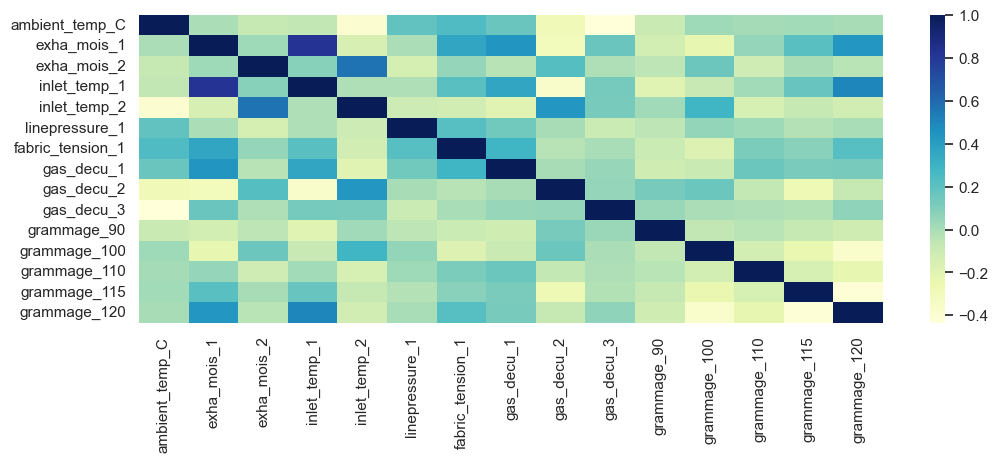

In [30]:
selected_features
sns.heatmap(X_transformed[[v for v in selected_features if v!="grammage"]].corr(), cmap="YlGnBu")

In [88]:
# ============================================================
# Selected model features
# ============================================================

selected_model_features = [v for v in selected_features if "grammage" not in v] + ["grammage"]

features_to_keep_feat = selected_model_features.copy()
features_to_keep_filter = selected_model_features.copy()

for _, step in prep_pip.steps:
    if not isinstance(step, GroupwisePLSTransformer):
        continue

    transformed_names = [
        f"{step.score_prefix}_{component}"
        for component in range(1, step.n_components + 1)
    ]
    source_names = list(step.pls_columns)

    selected_transformed = ordered_intersection(
        selected_model_features,
        transformed_names,
    )

    if selected_transformed:
        selected_model_features = ordered_difference(
            selected_model_features,
            selected_transformed,
        )

        features_to_keep_feat = ordered_difference(
            features_to_keep_feat,
            selected_transformed,
        )
        features_to_keep_filter = ordered_difference(
            features_to_keep_filter,
            selected_transformed,
        )

        features_to_keep_feat = unique_in_order(
            features_to_keep_feat + source_names
        )
        features_to_keep_filter = unique_in_order(
            features_to_keep_filter + selected_transformed
        )

features_to_create = ordered_intersection(
    created_vars,
    selected_model_features,
)


# ============================================================
# Final deterministic pre-estimator
# ============================================================

pre_estimator_steps = [
    (
        "feat",
        FeatureCreator(
            features_to_create=features_to_create,
            features_to_keep=unique_in_order(
                features_to_keep_feat
            ),
            errors="raise",
        ),
    )
]

for name, step in prep_pip.steps:
    step_copy = deepcopy(step)

    if isinstance(step, GroupwisePLSTransformer):
        transformed_names = [
            f"{step.score_prefix}_{component}"
            for component in range(1, step.n_components + 1)
        ]

        required_scores = ordered_intersection(
            features_to_keep_filter,
            transformed_names,
        )

        if required_scores:
            pre_estimator_steps.append(
                (name, step_copy)
            )
    else:
        pre_estimator_steps.append(
            (name, step_copy)
        )

pre_estimator_steps.append(
    (
        "filter",
        SKColumnSelector(
            unique_in_order(features_to_keep_filter)
        ),
    )
)

categorical_features = ["grammage"]

numeric_features = [
    feature
    for feature in features_to_keep_filter
    if feature not in categorical_features 
]

if not numeric_features and not categorical_features:
    raise ValueError(
        "No features remain for the final model."
    )

column_transformers = []

if numeric_features:
    numeric_pipeline = Pipeline(
        steps=[
            (
                "scaler_out",
                StandardScaler(),
            )
        ]
    )

    column_transformers.append(
        (
            "num",
            numeric_pipeline,
            numeric_features,
        )
    )

if categorical_features:
    column_transformers.append(
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="first",
            ),
            categorical_features,
        )
    )

scaler_encoder = ColumnTransformer(
    transformers=column_transformers,
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

pre_estimator_steps.extend(
    [
        ("scaler_encoder", scaler_encoder),
        #("intercept", AddIntercept()),
    ]
)

pre_estimator = Pipeline(
    steps=pre_estimator_steps
)


# ============================================================
# Input columns required by final pre-estimator
# ============================================================

required_feature_inputs = unique_in_order(
    pre_estimator
    .named_steps["feat"]
    .features_required()
)

feat_list = ordered_difference(
    unique_in_order(
        [v for v in features_to_keep_feat + required_feature_inputs if "grammage" not in v] + ["grammage"]
    ),
    features_to_create,
)

missing_training_columns = [
    feature
    for feature in feat_list
    if feature not in Xtr.columns and "grammage" not in feature
]
if missing_training_columns:
    raise KeyError("Required input features are missing from Xtr: "f"{missing_training_columns}")

missing_test_columns = [
    feature
    for feature in feat_list
    if feature not in Xte.columns and "grammage" not in feature
]
if missing_test_columns:
    raise KeyError("Required input features are missing from Xte: "f"{missing_test_columns}")


# ============================================================
# Fit final preprocessing on training data only
# ============================================================

X_train_transformed = pre_estimator.fit_transform(
    Xtr.loc[:, feat_list],
    ytr,
)

X_test_transformed = pre_estimator.transform(
    Xte.loc[:, feat_list],
)

X_transformed = pd.concat([X_train_transformed, X_test_transformed], axis =0) 

if not isinstance(X_train_transformed, pd.DataFrame):
    raise TypeError("X_train_transformed must be a pandas DataFrame.")

if not isinstance(X_test_transformed, pd.DataFrame):
    raise TypeError("X_test_transformed must be a pandas DataFrame.")

if not X_train_transformed.columns.equals(
    X_test_transformed.columns
):
    raise ValueError("Train and test transformed columns differ.")

# if "intercept" not in X_train_transformed.columns:
#     raise RuntimeError("The transformed design matrix has no intercept.")

# if not np.allclose(
#     X_train_transformed["intercept"].to_numpy(),
#     1.0,
# ):
#     raise RuntimeError("The training intercept column is not constant one.")

# if not np.allclose(
#     X_test_transformed["intercept"].to_numpy(),
#     1.0,
# ):
#     raise RuntimeError("The test intercept column is not constant one.")

if X_train_transformed.columns.duplicated().any():
    duplicate_columns = X_train_transformed.columns[
        X_train_transformed.columns.duplicated()
    ].tolist()
    raise RuntimeError(
        f"Duplicate transformed columns found: {duplicate_columns}"
    )


# ============================================================
# Final objects used by the model
# ============================================================

transformed_feature_names = (
    X_train_transformed.columns.tolist()
)


X_train = Xtr.loc[:, feat_list].copy()
X_test = Xte.loc[:, feat_list].copy()

y_train = ytr.copy()
y_test = yte.copy()


# ============================================================
# Diagnostics
# ============================================================

print("Raw training shape:", X_train.shape)
print("Raw test shape:", X_test.shape)

print(
    "Transformed training shape:",
    X_train_transformed.shape,
)
print(
    "Transformed test shape:",
    X_test_transformed.shape,
)

print(
    "Transformed features:",
    transformed_feature_names,
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

if categorical_features:
    fitted_encoder = (
        pre_estimator
        .named_steps["scaler_encoder"]
        .named_transformers_["cat"]
    )
    print(
        "One-hot categories:",
        fitted_encoder.categories_,
    )


Raw training shape: (2656, 28)
Raw test shape: (664, 28)
Transformed training shape: (2656, 15)
Transformed test shape: (664, 15)
Transformed features: ['ambient_temp_C', 'exha_mois_1', 'exha_mois_2', 'inlet_temp_1', 'inlet_temp_2', 'linepressure_1', 'fabric_tension_1', 'gas_decu_1', 'gas_decu_2', 'gas_decu_3', 'grammage_90', 'grammage_100', 'grammage_110', 'grammage_115', 'grammage_120']
Numeric features: ['ambient_temp_C', 'exha_mois_1', 'exha_mois_2', 'inlet_temp_1', 'inlet_temp_2', 'linepressure_1', 'fabric_tension_1', 'gas_decu_1', 'gas_decu_2', 'gas_decu_3']
Categorical features: ['grammage']
One-hot categories: [array([ 85,  90, 100, 110, 115, 120])]


In [91]:
main_estimator= Pipeline(steps = [            
            ("ridge", Ridge())
        ])

estimator = Pipeline(pre_estimator.steps + main_estimator.steps)

In [ ]:
param_grid={"ridge__alpha": np.logspace(2, 4, 100)}
#param_grid = {"pca__base_estimator__n_components": list(range(1, max_comps + 1)), "ridge__alpha":  np.logspace(-4, 3, 20)}
#param_grid={"ridge__alpha": [1]}
    
model = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    refit=True,            # refit best model on all training data
)

model.fit(X_train,y_train)

In [94]:
model.best_params_

{'ridge__alpha': np.float64(613.5907273413176)}

 Test Set Performance
RMSE : 36.1539
MAE  : 29.1308
R²   : 0.1867


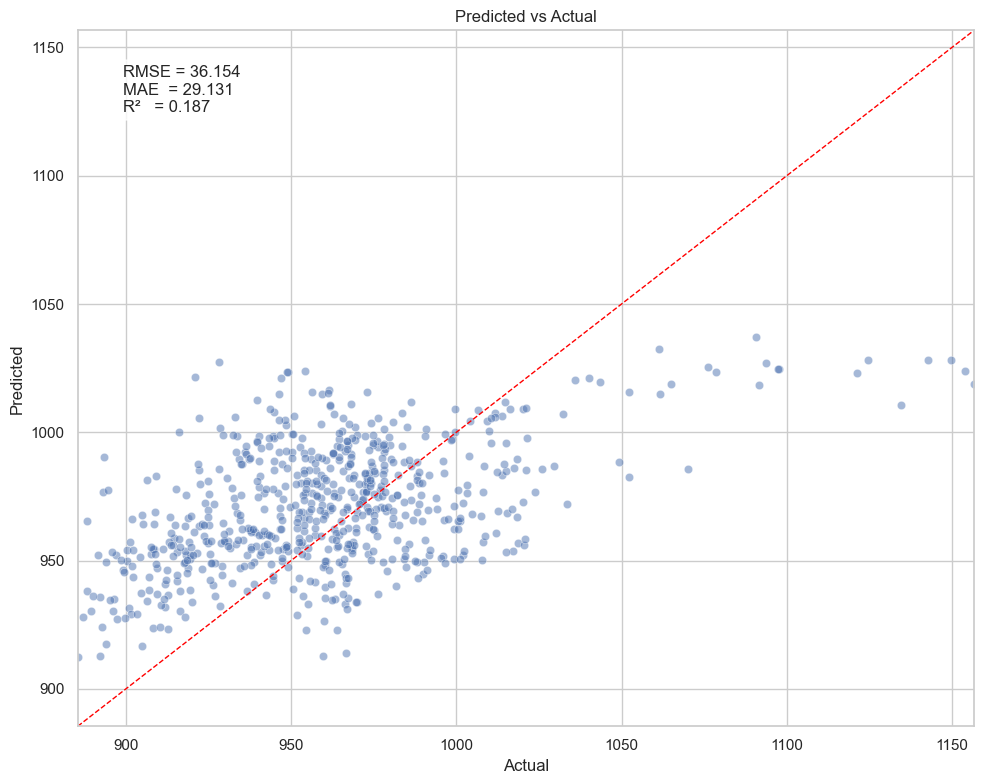

In [95]:
ypred = model.predict(X_test)
# metrics
rmse = root_mean_squared_error(y_test, ypred)
mae = mean_absolute_error(y_test, ypred)
r2 = r2_score(y_test, ypred)
 
# pretty print in console
print("="*40)
print(" Test Set Performance")
print("="*40)
print(f"RMSE : {rmse:,.4f}")
print(f"MAE  : {mae:,.4f}")
print(f"R²   : {r2:,.4f}")
print("="*40)
 
# scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
 
sns.scatterplot(x=yte, y=ypred, alpha=0.5, ax=ax)
 
lims = [
    np.nanmin([y_test.min(), ypred.min()]),
    np.nanmax([y_test.max(), ypred.max()])
]
 
ax.plot(lims, lims, linestyle="--", color="red", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
 
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
 
# add metrics box inside plot
textstr = "\n".join((
    f"RMSE = {rmse:.3f}",
    f"MAE  = {mae:.3f}",
    f"R²   = {r2:.3f}",
))
 
ax.text(
    0.05, 0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
 
plt.tight_layout()
plt.show()

In [ ]:
from utility import calculate_manual_shap, plotly_shap_beeswarm

base, shap_vals, X_explain, feats = calculate_manual_shap(model.best_estimator_, X_reference=Xtr[sel_vars+["AB_Grade_ID"]], X_sample=Xte[sel_vars+["AB_Grade_ID"]], grade_id="6010120", grade_col="AB_Grade_ID")

: 

In [255]:
fig = plotly_shap_beeswarm(shap_vals, X_explain, feats, max_features=100)
fig.show()

In [96]:
if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.best_estimator_.fit(X[sel_vars],y)
else:    
    sel_vars=s_vars
    model.best_estimator_.fit(X[sel_vars],y)

In [97]:
with open(f"model_steam.pkl", 'wb') as f:
        pickle.dump(model, f)